## Set up

Importing packages

In [1]:
#packages for directory and file handling
import os
import glob
import json
import pprint
import re

#packages for time handling
import time as pytime
import datetime

#packages for flow cytometry data handling
import FlowCal

#packages for data handling
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype

#packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize

#packages for statistical analysis, scaling, dimensionality reduction and clustering
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import spearmanr, boxcox, gaussian_kde
from numpy.polynomial.polynomial import Polynomial
from sklearn.preprocessing import StandardScaler
import prince

Set custom themes

In [2]:
def custom_theme(fontsize: int = 7):
    """Apply a custom matplotlib/seaborn theme with inward ticks and Arial font.
    
    Args:
        fontsize: Base font size in points applied to all text elements. Defaults to 7.
    """
    sns.set_style("whitegrid")

    plt.rcParams.update({
        #axes
        'axes.edgecolor':        'black',
        'axes.linewidth':        0.3,
        'axes.grid':             False,
        'axes.labelsize':        fontsize,
        'axes.titlesize':        fontsize,

        #major ticks
        'xtick.major.size':      3,
        'xtick.major.width':     0.3,
        'ytick.major.size':      3,
        'ytick.major.width':     0.3,

        #minor ticks
        'xtick.minor.size':      2,
        'xtick.minor.width':     0.2,
        'ytick.minor.size':      2,
        'ytick.minor.width':     0.2,

        #tick direction
        'xtick.direction':       'in',
        'ytick.direction':       'in',

        #font
        'font.size':             fontsize,
        'font.family':           'Arial',

        #legend
        'legend.fontsize':       fontsize,
        'legend.title_fontsize': fontsize,

        #embed fonts in vector output
        'pdf.fonttype':          42,
        'ps.fonttype':           42,
    })

## Pre-processing

### Read files

Inspect the files

In [3]:
#get all subdirs in fcs_files (corresponding to experiments)
os.getcwd()
output = os.listdir('fcs_files')
print(sorted(output))

#check filenames in a dir
fcs_output = glob.glob('fcs_files/AS_200625/*.fcs')
sorted(fcs_output)[:5]

['AS_200427', 'AS_200506', 'AS_200520', 'AS_200601', 'AS_200617', 'AS_200624', 'AS_200625', 'AS_200626', 'AS_200627', 'AS_200628', 'AS_200702', 'AS_200705', 'AS_200706', 'AS_200720', 'AS_200729', 'AS_200730', 'AS_200911', 'AS_210303_LRTM1_other_2ndary', 'AS_210303_regional_specicifity_cont', 'AS_210305_suboptimal_batch_2+3_analysis', 'AS_210310_regional_specicifity', 'AS_210311_regional_specicifity', 'AS_210317_regional_specicifity_dFB_vFB_dMB_2_vHB_acc', 'AS_210317_regional_specicifity_dHB_acc_vFB_pap', 'AS_210318_regional_specicifity_dFB_vFB_dMB_2_vHB_pap', 'AS_210318_regional_specicifity_dFB_vFB_dMB_2_vHB_tryp', 'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp', 'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_', 'AS_210424_regional_specicifity_batch_start_14_2f_9_dMB_2_acc_tryp_and_pap', 'AS_210424_regional_specicifity_batch_start_17_2f_8_dMB_2_acc_and_pap', 'AS_210424_regional_specicifity_batch_start_28_2f_9_dMB_2_acc_and_pap', 'AS_210426_regional_speci

['fcs_files/AS_200625/RC17_CT0-7_d16_diff_ALCAM_1_3a_100_dMB_009.fcs',
 'fcs_files/AS_200625/RC17_CT0-7_d16_diff_ALCAM_1_3a_100_vHB_012.fcs',
 'fcs_files/AS_200625/RC17_CT0-7_d16_diff_APCDD1_1_3a_100_dMB_015.fcs',
 'fcs_files/AS_200625/RC17_CT0-7_d16_diff_APCDD1_1_3a_100_vHB_018.fcs',
 'fcs_files/AS_200625/RC17_CT0-7_d16_diff_CNTN2_1_3a_20_dMB_021.fcs']

Import files and inspect

In [4]:
#make a list of all the folders
folder_names = ['AS_200427', 'AS_200506', 'AS_200520', 'AS_200601', 'AS_200617', 'AS_200624', 
                'AS_200625', 'AS_200626', 'AS_200627', 'AS_200628', 'AS_200702', 'AS_200705',
                'AS_200706', 'AS_200720', 'AS_200729', 'AS_200730', 'AS_200911',
                'AS_210303_LRTM1_other_2ndary',
                'AS_210303_regional_specicifity_cont', 
                'AS_210305_suboptimal_batch_2+3_analysis',
                'AS_210310_regional_specicifity', 
                'AS_210311_regional_specicifity',
                'AS_210317_regional_specicifity_dFB_vFB_dMB_2_vHB_acc', 
                'AS_210317_regional_specicifity_dHB_acc_vFB_pap',
                'AS_210318_regional_specicifity_dFB_vFB_dMB_2_vHB_pap',
                'AS_210318_regional_specicifity_dFB_vFB_dMB_2_vHB_tryp',
                'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp',
                'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_', 
                'AS_210424_regional_specicifity_batch_start_14_2f_9_dMB_2_acc_tryp_and_pap',
                'AS_210424_regional_specicifity_batch_start_17_2f_8_dMB_2_acc_and_pap',
                'AS_210424_regional_specicifity_batch_start_28_2f_9_dMB_2_acc_and_pap',
                'AS_210426_regional_specicifity_batch_start_14_2f_9_dHB_vHB_acc_tryp_and_pap',
                'AS_210426_regional_specicifity_batch_start_28_2f_9_dHB_tryp_and_pap',
                'AS_210428_regional_specicifity_batch_start_17_2f_8_rVM_cVM_tryp_cVM_pap',
                'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap',
                'AS_210429_regional_specicifity_batch_start_17_2f_8_dHB_acc_and_pap',
                'AS_210429_regional_specicifity_batch_start_7_2f_9_dHB_acc_and_pap',
                'AS_210721_regional_specicifity_Alison_batch_start_19_2f_5_dMB+FGF8_acc_tryp_and_pap', 
                'AS_220509_co-expression_no_5', 'AS_230307_APCDD1_TPBG_CORIN_failed_RC17_H9' #new folders
]

#make a dictionary (with the folders as keys and the fcs files as value)
sorted_files = {}

#iterate over the folder names to sort the .fcs files in each folder
for folder in folder_names: 
    files = glob.glob(f'fcs_files/{folder}/*.fcs')
    sorted_files[folder] = sorted(files)

    
#check the import
imported_files = {}
counter = 0 #to limit the number of rows printed
for folder in sorted_files:
    for filename in sorted_files[folder]:
        if counter == 10:
            break
        fcs_data = FlowCal.io.FCSData(filename)
        imported_files[filename] = fcs_data
        #print(f"Channels in {filename}: {fcs_data.channels}")  #print available channels, uncomment to inspect
        counter += 1

#import all files in the dictionary and save as new dictionary
imported_files = {}
for folder in sorted_files:
    for filename in sorted_files[folder]:
        fcs_data = FlowCal.io.FCSData(filename)
        imported_files[filename] = fcs_data

#inspect the shape of the imported fcs files
keys_shapes = []
for key, value in imported_files.items():
    keys_shapes.append(f"{key}: {value.shape}")

#make the output more readable (uncomment to inspect)

Import files

In [5]:
#make a list of all the folders
folder_names = ['AS_200427', 'AS_200506', 'AS_200520', 'AS_200601', 'AS_200617', 'AS_200624', 
                'AS_200625', 'AS_200626', 'AS_200627', 'AS_200628', 'AS_200702', 'AS_200705',
                'AS_200706', 'AS_200720', 'AS_200729', 'AS_200730', 'AS_200911',
                'AS_210303_regional_specicifity_cont', 
                'AS_210310_regional_specicifity',
                'AS_210311_regional_specicifity',
                'AS_210317_regional_specicifity_dFB_vFB_dMB_2_vHB_acc', 
                'AS_210317_regional_specicifity_dHB_acc_vFB_pap',
                'AS_210318_regional_specicifity_dFB_vFB_dMB_2_vHB_pap',
                'AS_210318_regional_specicifity_dFB_vFB_dMB_2_vHB_tryp',
                'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp',
                'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_', 
                'AS_210424_regional_specicifity_batch_start_14_2f_9_dMB_2_acc_tryp_and_pap',
                'AS_210424_regional_specicifity_batch_start_17_2f_8_dMB_2_acc_and_pap',
                'AS_210424_regional_specicifity_batch_start_28_2f_9_dMB_2_acc_and_pap',
                'AS_210426_regional_specicifity_batch_start_14_2f_9_dHB_vHB_acc_tryp_and_pap',
                'AS_210426_regional_specicifity_batch_start_28_2f_9_dHB_tryp_and_pap',
                'AS_210428_regional_specicifity_batch_start_17_2f_8_rVM_cVM_tryp_cVM_pap',
                'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap',
                'AS_210429_regional_specicifity_batch_start_17_2f_8_dHB_acc_and_pap',
                'AS_210429_regional_specicifity_batch_start_7_2f_9_dHB_acc_and_pap',
                'AS_210721_regional_specicifity_Alison_batch_start_19_2f_5_dMB+FGF8_acc_tryp_and_pap'
]

#make a dictionary (with the folders as keys and the fcs files as value)
sorted_files = {}

#iterate over the folder names to sort the .fcs files in each folder
for folder in folder_names: 
    files = glob.glob(f'fcs_files/{folder}/*.fcs')
    sorted_files[folder] = sorted(files)

#import all files in the dictionary and save as new dictionary (could be either as a flat or nested dictionary)
imported_files = {}

#flat dictionary
for folder in sorted_files:
    for filename in sorted_files[folder]:
        fcs_data = FlowCal.io.FCSData(filename)
        imported_files[filename] = fcs_data

#nested dictionary

#inspect the channels of the imported fcs files
print(fcs_data.channels)
print(fcs_data.shape)

('Time', 'FSC-A', 'FSC-H', 'FSC-W', 'SSC-A', 'SSC-H', 'SSC-W', 'Alexa Fluor 488-A', 'PE-A', 'PE-Cy7-A', 'Alexa Fluor 700-A')
(14671, 11)


### Plotting

Plot a histograms of FSC-A

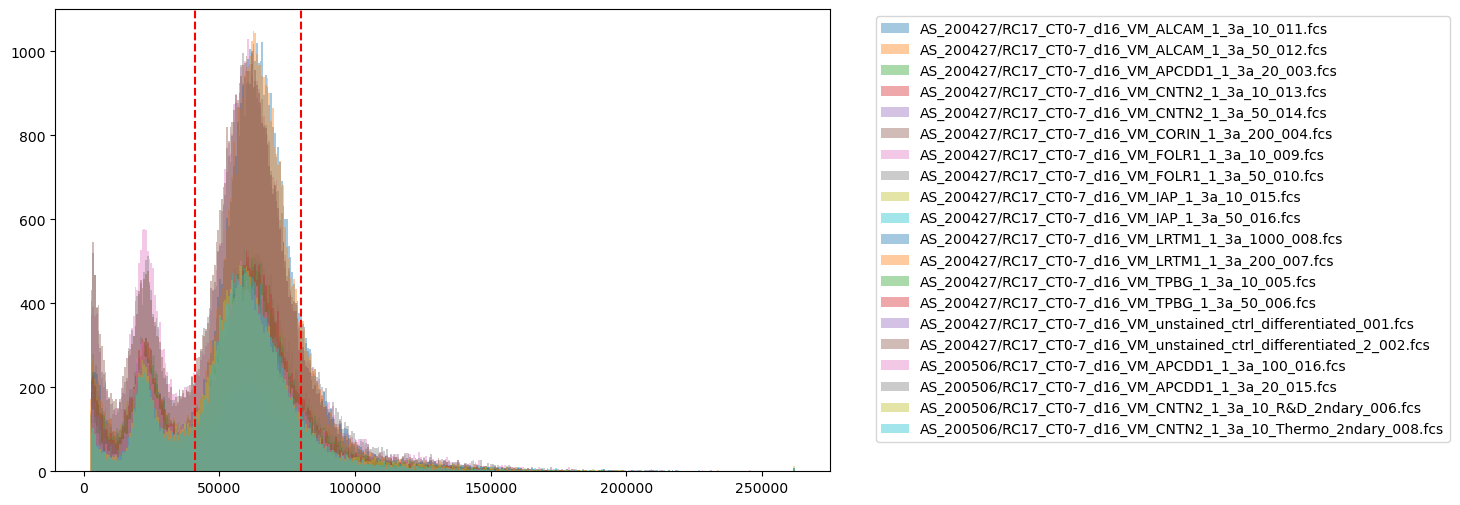

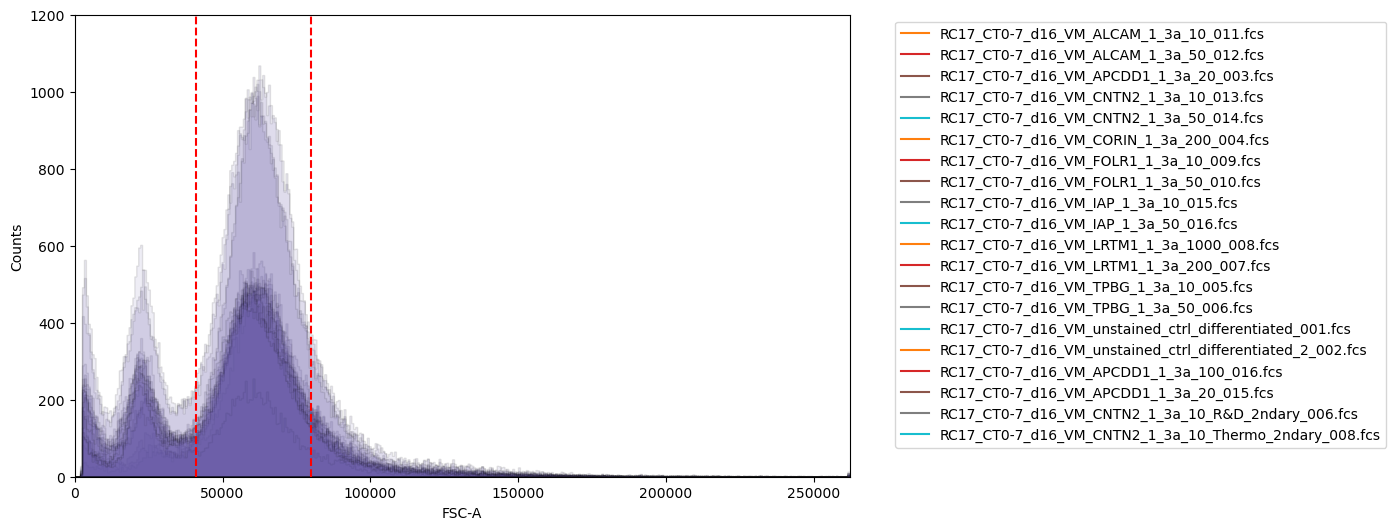

In [6]:
#plot with plt.hist
plt.figure(figsize=(10, 6)) # make the figure wider

for i, (filename, file) in enumerate(imported_files.items()):
    if i >= 20: #process a limited number of files
        break
    folder_name = os.path.basename(os.path.dirname(filename))  #extract the folder name
    plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, label=f'{folder_name}/{os.path.basename(filename)}')

#create two vertical lines, corresponding to potentially suitable thresholds
plt.axvline(x= 4.1e4, color='r', linestyle='--')
plt.axvline(x= 8e4, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


#plot with FlowCal.plot.hist1d
plt.figure(figsize=(10, 6)) # make the figure wider

#inspect the fsc-a of the first files
for i, (filename, file) in enumerate(imported_files.items()):
    if i >= 20:
        break
    FlowCal.plot.hist1d(file, channel = 'FSC-A', xscale='linear', alpha=0.1, bins=400, ylim=(0, 1200))
    plt.plot([], [], label=filename.split('/')[-1])

plt.axvline(x= 4.1e4, color='r', linestyle='--')
plt.axvline(x= 8e4, color='r', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') #move legends to the right

plt.show()

### Quality control

In [7]:
#calculate the mean fsc-a variance per sample and plot
mean_fsc_a_var = {}
for i, (filename, file) in enumerate(imported_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    x = file[:, file.channels.index('Time')]
    y = file[:, file.channels.index('FSC-A')]
    
    #it seems the time is in centiseconds. I want to bin the data in 1 sec intervals (i.e. 100 binning).
    time_bins = np.arange(0, x.max(), 100)  # Create bins every 10 seconds
    mean_fsc_a = [np.mean(y[(x >= start) & (x < end)]) for start, end in zip(time_bins[:-1], time_bins[1:])]

    #exclude intervals with nan values
    mean_fsc_a = np.array(mean_fsc_a)
    valid_indices = ~np.isnan(mean_fsc_a)
    mean_fsc_a = mean_fsc_a[valid_indices]
    time_bins = time_bins[:-1][valid_indices]

    #calculate the overall mean and standard deviation
    mean = np.mean(mean_fsc_a)
    std = np.std(mean_fsc_a)
    
    #calculate the variance
    variance = std/mean
    mean_fsc_a_var[filename] = variance

#calculate the global mean and standard deviation of all variances
variances = list(mean_fsc_a_var.values())
global_mean = np.mean(variances)
global_std = np.std(variances)

/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3462: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


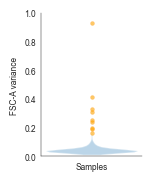

time_outlier samples: ['AS_200626/RC17_CT0-7_d16_diff_Tube_001_070.fcs', 'AS_200702/RC17_CT0-7_d16_diff_unstained_ctrl_PE-vio770_rVM_046.fcs', 'AS_210310_regional_specicifity/RC17_CT0-7_d16_diff_LRTM1_1_3a_20_rVM_046.fcs', 'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp/RC17_CT0-7_d16_diff_unstained_ctrl_vFB_002.fcs', 'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_APCDD1_1_3a_100_dFB_015.fcs', 'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_rVM_046.fcs', 'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_vHB_049.fcs', 'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap/RC17_CT0-7_d16_diff_trypLE-dissoc_unstained_ctrl_AF488_rVM_046.fcs', 'AS_210721_regional_specicifity_Alison_batch_start_19_2f_5_dMB+FGF8_acc_tryp_and_pap/RC17_CT0-7_d16_diff_accutase-dissoc_unstained_ctrl_CF568_dMB_2_072.fcs']
The n

In [8]:
#apply the custom theme
custom_theme(6)

#plot the variance in a barplot
plt.figure(figsize=(1.5, 1.8))
plt.violinplot(mean_fsc_a_var.values(), showextrema = False)

#label datapoints in orange if variance is ±3sd from the mean variance
time_outliers = []
for i, (filename, variance) in enumerate(mean_fsc_a_var.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    if variance >= global_mean + 3 * global_std:
        plt.scatter(1, variance, color='orange', s=8, alpha= 0.6, edgecolors="darkorange", linewidths=0.2)  # Plot the outlier in orange
        time_outliers.append(f'{folder_name}/{os.path.basename(filename)}')

plt.ylabel('FSC-A variance')

#remove gridlines for a clean plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)

#remove x-axis labels
plt.xticks([])
plt.xlabel('Samples')
plt.ylim(0, 1)
plt.tight_layout()

#plt.savefig('figs/fsc variance violin.pdf') #save plot
plt.show() #show plot

print('time_outlier samples: ' + str(time_outliers))
print('The number of time outliers is: ' + str(len(time_outliers)))

In [9]:
#only include the files which should be trimmed in the dictionary, and include the timepoints that should be trimmed
times_to_trim = {
    'AS_200702/RC17_CT0-7_d16_diff_unstained_ctrl_PE-vio770_rVM_046.fcs' : lambda x: x < 7000,
    'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp/RC17_CT0-7_d16_diff_unstained_ctrl_vFB_002.fcs' : lambda x: x > 7000,
    'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 5800,
    'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap/RC17_CT0-7_d16_diff_trypLE-dissoc_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 4000
}

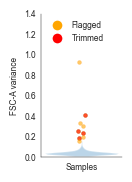

In [10]:
custom_theme(6)

#plot variance (in barplot)
plt.figure(figsize=(1.3, 1.8))
plt.violinplot(mean_fsc_a_var.values(), showextrema=False)

#label datapoints in orange and with the corresponding filename if the variance is ±3sd from the mean variance
time_outliers = []
for i, (filename, variance) in enumerate(mean_fsc_a_var.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    jitter = np.random.uniform(-0.025, 0.025)  # Generate a small random jitter
    if variance >= global_mean + 3 * global_std:
        plt.scatter(1 + jitter, variance, color='orange', s=8, alpha=0.6, edgecolors="darkorange", linewidths=0.2)  # Plot the outlier in orange
        time_outliers.append(f'{folder_name}/{os.path.basename(filename)}')
    
    #mark the files that were trimmed
    if f'{folder_name}/{os.path.basename(filename)}' in times_to_trim:
        plt.scatter(1 + jitter, variance, color='red', s=8, alpha=0.6, edgecolors="darkred", linewidths=0.2)  # Plot the outlier in green

plt.ylabel('FSC-A variance')

#remove gridlines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)

#remove x-axis labels
plt.xticks([])
plt.xlabel('Samples')
plt.ylim(0, 1.4)

#create custom legend with dots
orange_dot = Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='Flagged')
red_dot = Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Trimmed')
plt.legend(handles=[orange_dot, red_dot], frameon=False, loc='upper left')
plt.tight_layout()

#save and show plot
#plt.savefig('figs/fsc variance violin times trimmed.pdf', dpi=300) #save
plt.show() #show plot


Plotting file 1: fcs_files/AS_200626/RC17_CT0-7_d16_diff_Tube_001_070.fcs
Plotting file 2: fcs_files/AS_200702/RC17_CT0-7_d16_diff_unstained_ctrl_PE-vio770_rVM_046.fcs
Plotting file 3: fcs_files/AS_210310_regional_specicifity/RC17_CT0-7_d16_diff_LRTM1_1_3a_20_rVM_046.fcs


Plotting file 4: fcs_files/AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp/RC17_CT0-7_d16_diff_unstained_ctrl_vFB_002.fcs
Plotting file 5: fcs_files/AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_APCDD1_1_3a_100_dFB_015.fcs
Plotting file 6: fcs_files/AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_rVM_046.fcs


Plotting file 7: fcs_files/AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_vHB_049.fcs
Plotting file 8: fcs_files/AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap/RC17_CT0-7_d16_diff_trypLE-dissoc_unstained_ctrl_AF488_rVM_046.fcs
Plotting file 9: fcs_files/AS_210721_regional_specicifity_Alison_batch_start_19_2f_5_dMB+FGF8_acc_tryp_and_pap/RC17_CT0-7_d16_diff_accutase-dissoc_unstained_ctrl_CF568_dMB_2_072.fcs


/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/860647626.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


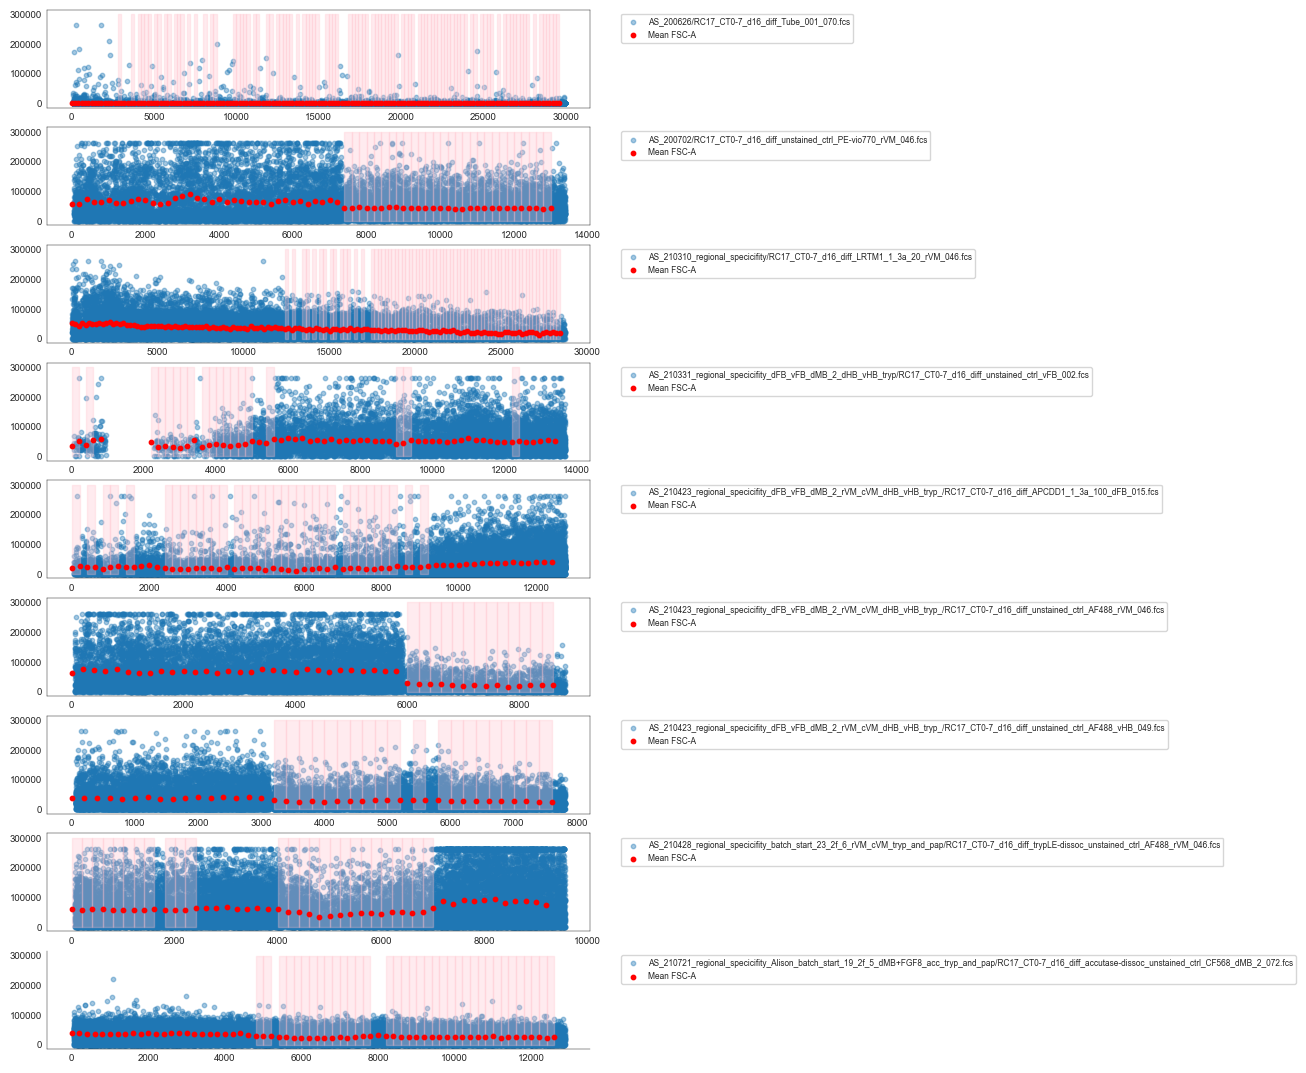

In [11]:
custom_theme(6)

#plot the outliers
#filter for files matching the outliers
filtered_files = {k: v for k, v in imported_files.items() if f'{os.path.basename(os.path.dirname(k))}/{os.path.basename(k)}' in time_outliers}
num_files = len(filtered_files)

plt.rcParams['font.size'] = 7
fig, axs = plt.subplots(num_files, 1, figsize=(7, num_files*1.5)) #create a grid of subplots

#if axs is not iterable, convert it into a list
if not isinstance(axs, np.ndarray):
    axs = [axs]

for i, (filename, file) in enumerate(filtered_files.items()):
    print(f'Plotting file {i+1}: {filename}')  #print filename
    ax = axs[i]
    folder_name = os.path.basename(os.path.dirname(filename))  #extract folder name

    # plot
    x = file[:, file.channels.index('Time')]
    y = file[:, file.channels.index('FSC-A')]
    ax.scatter(x, y, alpha=0.4, label=f'{folder_name}/{os.path.basename(filename)}', s = 10)
        
    #it seems the time is in centiseconds. I want to bin the data in 2 sec intervals (i.e. 100 binning).
    #calculate the mean fsc-a per every 2 sec
    time_bins = np.arange(0, x.max(), 200)  # Create bins every seconds
    mean_fsc_a = [np.mean(y[(x >= start) & (x < end)]) for start, end in zip(time_bins[:-1], time_bins[1:])]

    #exclude intervals with nan values
    mean_fsc_a = np.array(mean_fsc_a)
    valid_indices = ~np.isnan(mean_fsc_a)
    mean_fsc_a = mean_fsc_a[valid_indices]
    time_bins = time_bins[:-1][valid_indices]

    #calculate the overall mean and standard deviation
    global_mean = np.mean(mean_fsc_a)
    global_std = np.std(mean_fsc_a)

    #find the timepoints where the mean is +0.1 sd from the mean (the mean should be very stable)
    low = global_mean - 0.1 * global_std
    outliers = (mean_fsc_a < low) #| (mean_fsc_a < low)

    #color the background orange for these timepoints
    for start, end in zip(time_bins[:-1][outliers[:-1]], time_bins[1:][outliers[:-1]]):
        ax.fill_between([start, end], 300000, color='pink', alpha=0.3) #add low if of interest

    #plot the mean fsc-a per every 10 sec
    ax.scatter(time_bins, mean_fsc_a, color='r', label='Mean FSC-A', s = 10)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

#remove gridlines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.tight_layout()
plt.show()

Isolate a single file for demonstration of QC

In [12]:
fcs_file_plot = 'fcs_files/AS_200702/RC17_CT0-7_d16_diff_unstained_ctrl_PE-vio770_rVM_046.fcs'
file  = filtered_files[fcs_file_plot]

folder_name = os.path.basename(os.path.dirname(fcs_file_plot))

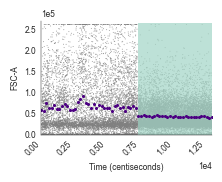

In [13]:
custom_theme(6)

plt.figure(figsize=(2.2, 1.8))

x = file[:, file.channels.index('Time')]
y = file[:, file.channels.index('FSC-A')]
plt.scatter(x, y, alpha=0.8, s = 0.5, edgecolors='none', color='gray')
        
#it seems the time is in centiseconds. I want to bin the data in 2 sec intervals (i.e. 100 binning).
#calculate the mean fsc-a per every 2 sec
time_bins = np.arange(0, x.max(), 200)  # Create bins every seconds
mean_fsc_a = [np.mean(y[(x >= start) & (x < end)]) for start, end in zip(time_bins[:-1], time_bins[1:])]

# Exclude intervals with nan values
mean_fsc_a = np.array(mean_fsc_a)
valid_indices = ~np.isnan(mean_fsc_a)
mean_fsc_a = mean_fsc_a[valid_indices]
time_bins = time_bins[:-1][valid_indices]

#calculate the overall mean and standard deviation
global_mean = np.mean(mean_fsc_a)
global_std = np.std(mean_fsc_a)

#find the timepoints where the mean is +0.1 sd from the mean (the mean should be very stable)
low = global_mean - 0.1 * global_std
outliers = (mean_fsc_a < low)

#color the background orange for these timepoints
for start, end in zip(time_bins[:-1][outliers[:-1]], time_bins[1:][outliers[:-1]]):
    plt.fill_between([start, end], y1=0, y2=265000, color='#a2d5c6', alpha=0.7, edgecolors='none') 

#plot the mean fsc-a per every 10 sec
plt.scatter(time_bins, mean_fsc_a, color='#4c0082', label='Mean FSC-A', s = 1.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.ylabel('FSC-A')
plt.xlabel('Time (centiseconds)')
plt.xlim(0,13000)
plt.ylim(0, 270000)
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figs/fsc variance samples continuous.pdf', dpi=300)
plt.show()

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/1990850672.py:60: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


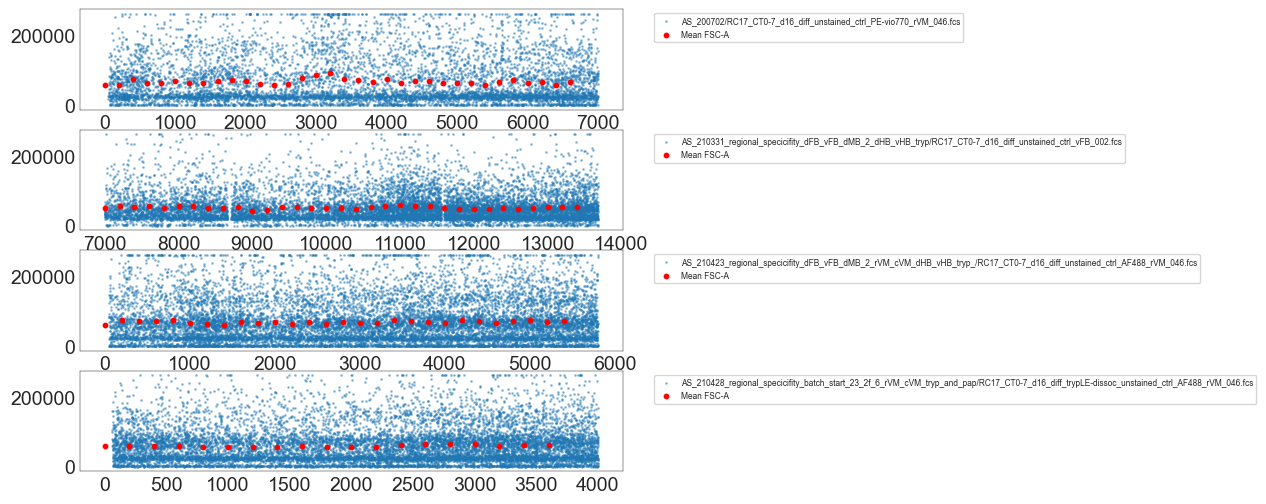

In [14]:
#only include the files which should be trimmed in the dictionary, and include the timepoints that should be trimmed
times_to_trim = {
    'AS_200702/RC17_CT0-7_d16_diff_unstained_ctrl_PE-vio770_rVM_046.fcs' : lambda x: x < 7000,
    'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp/RC17_CT0-7_d16_diff_unstained_ctrl_vFB_002.fcs' : lambda x: x > 7000,
    'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 5800,
    'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap/RC17_CT0-7_d16_diff_trypLE-dissoc_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 4000
}

#trim the files in the dictionary
for filename, timepoints in times_to_trim.items():
    base_filename = os.path.basename(filename)
    matching_files = {k: v for k, v in imported_files.items() if os.path.basename(k) == base_filename}
    if matching_files:
        for file_key, file in matching_files.items():
            time = file[:, file.channels.index('Time')]
            mask = timepoints(time)
            imported_files[file_key] = file[mask]
    else:
        print(f'File {base_filename} not found in imported_files')

#plot the outliers
#filter for files matching the outliers
filtered_files = {k: v for k, v in imported_files.items() if f'{os.path.basename(os.path.dirname(k))}/{os.path.basename(k)}' in times_to_trim.keys()}
num_files = len(filtered_files)

plt.rcParams['font.size'] = 14
fig, axs = plt.subplots(num_files, 1, figsize=(7, num_files*1.5)) # create a grid of subplots

#if axs is not iterable, convert it into a list
if not isinstance(axs, np.ndarray):
    axs = [axs]

for i, (filename, file) in enumerate(filtered_files.items()):
    ax = axs[i]
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name

    #plot
    x = file[:, file.channels.index('Time')]
    y = file[:, file.channels.index('FSC-A')]
    ax.scatter(x, y, alpha=0.4, label=f'{folder_name}/{os.path.basename(filename)}', s = 1)

    #calculate the mean fsc-a per every 2 sec
    time_bins = np.arange(0, x.max(), 200)  # Create bins every seconds
    mean_fsc_a = [np.mean(y[(x >= start) & (x < end)]) if np.any((x >= start) & (x < end)) else np.nan for start, end in zip(time_bins[:-1], time_bins[1:])]

    #exclude intervals with nans
    mean_fsc_a = np.array(mean_fsc_a)
    valid_indices = ~np.isnan(mean_fsc_a)
    mean_fsc_a = mean_fsc_a[valid_indices]
    time_bins = time_bins[:-1][valid_indices]

    #calculate the overall mean and standard deviation
    global_mean = np.mean(mean_fsc_a)
    global_std = np.std(mean_fsc_a)

    #plot the mean fsc-a per every 10 sec
    ax.scatter(time_bins, mean_fsc_a, color='r', label='Mean FSC-A', s = 10)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Determine the percentage problematic files

In [15]:
#determine the total number of files
total_files = len(imported_files)
print(f'The total number of files is: {total_files}')

#determine the percentage of problematic files
percentage_problematic_files = 100*(4/total_files)
percentage_problematic_files = round(percentage_problematic_files, 3)

#print the percentage of problematic files with 4 significant digits
print(f'The percentage of problematic files is: {percentage_problematic_files}%')

The total number of files is: 1157
The percentage of problematic files is: 0.346%


Quality control - flow rate

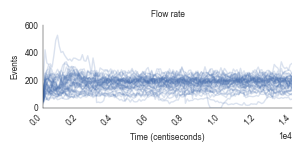

In [16]:
custom_theme(6)
flow_rate = {}

for i, (filename, file) in enumerate(imported_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    x = file[:, file.channels.index('Time')]
    y = file[:, file.channels.index('FSC-A')]

    if x.size == 0:
        continue
    
    time_bins = np.arange(0, x.max(), 100)  #create bins every 1 second
    num_events = [np.sum((x >= start) & (x < end)) for start, end in zip(time_bins[:-1], time_bins[1:])]

    # Exclude intervals with nan values
    num_events = np.array(num_events)
    valid_indices = ~np.isnan(num_events)
    num_events = num_events[valid_indices]
    time_bins = time_bins[:-1][valid_indices]

    #calculate flow rate
    flow_rate[filename] = num_events

#filter for files with mean >100 events and time>15000 centiseconds
filtered_files = {k: v for k, v in imported_files.items() if k in flow_rate and np.mean(flow_rate[k]) > 100 and np.max(v[:, v.channels.index('Time')]) > 15000}
num_files = len(filtered_files)

#plot flow rate for filtered files
plt.figure(figsize=(3, 1.5))
for i, (filename, file) in enumerate(filtered_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    x = file[:, file.channels.index('Time')]
    y = file[:, file.channels.index('FSC-A')]
    time_bins = np.arange(0, x.max(), 100)  # Create bins every 1 second
    num_events = [np.sum((x >= start) & (x < end)) for start, end in zip(time_bins[:-1], time_bins[1:])]

    #exclude intervals with nans
    num_events = np.array(num_events)
    valid_indices = ~np.isnan(num_events)
    num_events = num_events[valid_indices]
    time_bins = time_bins[:-1][valid_indices]

    #filter time_bins and num_events to only include times<=15000 centiseconds
    valid_time_indices = time_bins <= 15000
    time_bins = time_bins[valid_time_indices]
    num_events = num_events[valid_time_indices]

    #plot
    plt.plot(time_bins, num_events, label=f'{folder_name}/{os.path.basename(filename)}', alpha=0.2, color='#4C72B0', linewidth=1)

plt.xlabel('Time (centiseconds)')
plt.ylabel('Events')
plt.title('Flow rate')
plt.xlim(0, 14000)
plt.ylim(0, 600)
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.tight_layout()

#plt.savefig('figs/flow rate.pdf', dpi=300)
plt.show()

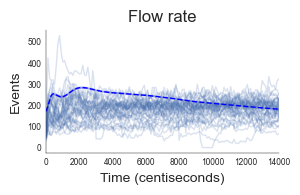

In [17]:
flow_rate = {}
all_time_bins = []
all_num_events = []

for i, (filename, file) in enumerate(imported_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    x = file[:, file.channels.index('Time')]
    y = file[:, file.channels.index('FSC-A')]
    
    if x.size == 0:
        continue
    
    time_bins = np.arange(0, x.max(), 100)  # Create bins every 1 second
    num_events = [np.sum((x >= start) & (x < end)) for start, end in zip(time_bins[:-1], time_bins[1:])]

    #exclude intervals with nans
    num_events = np.array(num_events)
    valid_indices = ~np.isnan(num_events)
    num_events = num_events[valid_indices]
    time_bins = time_bins[:-1][valid_indices]

    #calculate flow rate
    flow_rate[filename] = num_events

    #collect data
    all_time_bins.extend(time_bins)
    all_num_events.extend(num_events)

#filter for files with mean >100 events and time>15000 centiseconds
filtered_files = {k: v for k, v in imported_files.items() if k in flow_rate and np.mean(flow_rate[k]) > 100 and np.max(v[:, v.channels.index('Time')]) > 15000}
num_files = len(filtered_files)

#plot
plt.figure(figsize=(3, 1.6))
for i, (filename, file) in enumerate(filtered_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    x = file[:, file.channels.index('Time')]
    y = file[:, file.channels.index('FSC-A')]
    
    if x.size == 0:
        continue
    
    time_bins = np.arange(0, x.max(), 100)  #create bins every 1 second
    num_events = [np.sum((x >= start) & (x < end)) for start, end in zip(time_bins[:-1], time_bins[1:])]

    #exclude intervals with nans
    num_events = np.array(num_events)
    valid_indices = ~np.isnan(num_events)
    num_events = num_events[valid_indices]
    time_bins = time_bins[:-1][valid_indices]

    #filter time_bins and num_events to only include times<=15000 centiseconds
    valid_time_indices = time_bins <= 15000
    time_bins = time_bins[valid_time_indices]
    num_events = num_events[valid_time_indices]

    #plot
    plt.plot(time_bins, num_events, label=f'{folder_name}/{os.path.basename(filename)}', alpha=0.2, color='#4C72B0', linewidth=1)

#add a local regression trendline with error margin for the entire dataset
if len(all_time_bins) > 1:
    frac = 0.1 
    smoothed = lowess(all_num_events, all_time_bins, frac=frac)
    x_fit = smoothed[:, 0]
    y_fit = smoothed[:, 1]
    
    #bootstrapping to estimate confidence intervals
    n_bootstraps = 1000
    bootstrapped_y_fits = np.zeros((n_bootstraps, len(x_fit)))
    
    for i in range(n_bootstraps):
        indices = np.random.choice(len(all_time_bins), len(all_time_bins), replace=True)
        bootstrapped_x = np.array(all_time_bins)[indices]
        bootstrapped_y = np.array(all_num_events)[indices]
        bootstrapped_smoothed = lowess(bootstrapped_y, bootstrapped_x, frac=frac)
        bootstrapped_y_fits[i, :] = np.interp(x_fit, bootstrapped_smoothed[:, 0], bootstrapped_smoothed[:, 1])
    
    lower_bound = np.percentile(bootstrapped_y_fits, 2.5, axis=0)
    upper_bound = np.percentile(bootstrapped_y_fits, 97.5, axis=0)
    
    plt.fill_between(x_fit, lower_bound, upper_bound, color='blue', alpha=0.2, label='95% CI')
    plt.plot(x_fit, y_fit, linestyle='--', color='blue', linewidth=1, label='Trendline')

plt.xlabel('Time (centiseconds)', fontsize=10)
plt.ylabel('Events', fontsize=10)
plt.title('Flow rate', fontsize=12)
plt.xlim(0, 14000)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.show()

## Cut-offs

Validating threshold

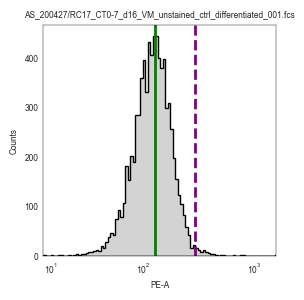

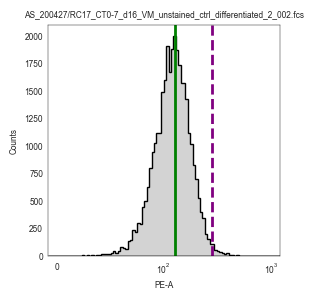

In [18]:
#show histogram of the fluorescence intensity valuess
count = 0
for filename, s in imported_files.items():

    #extract folder name from filename
    folder = os.path.basename(os.path.dirname(filename))
    
    if 'unstained' in filename:

        count += 1
        if count > 2:
            break
        
        #gate the cells
        #1. cell gate
        g1 = FlowCal.gate.ellipse(s, channels=['FSC-A','SSC-A'], center=(7.2e4, 8e4), a=25000, b=60000, theta=-25/180.*np.pi)

        #2. singlets fsc gate
        g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.92)
        
        #3. singlets ssc gate
        g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.98)

        #4. live gate
        g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)

        #set a default channel
        channel = 'PE-A'

        if channel in g4.channels:
            if 'CF568' in filename:
                channel = 'PE-A'
            if 'PE-vio770' in filename:
                channel = 'PE-Cy7-A'
            if 'AF488' in filename:
                channel = 'Alexa Fluor 488-A'
            #else: 
                #channel - 'PE-A'
            
            plt.figure(figsize=(3,3))

            FlowCal.plot.hist1d(g4, channel=channel, bins=200, facecolor='lightgray')
            plt.title(f'{folder}/{os.path.basename(filename)}')
    
            #create two vertical lines, corresponding to the mean and 3sd over the mean
            mean_value = np.mean(g4[:, channel])
            std_value = np.std(g4[:, channel])
            mean_3sd = mean_value + 3 * std_value
            
            plt.axvline(x=mean_value, color='green', linestyle='-', linewidth = 2)
            plt.axvline(x=mean_3sd, color='purple', linestyle='--', linewidth = 2)
            plt.xlim([np.min(g4[:, channel]), np.max(g4[:, channel])])
            
            plt.show()
        else:
            print(f'{channel} not in channels')

Cut-off calculations

In [19]:
#this code takes a few min to run 

#only include the files which should be trimmed in the dictionary, and include the timepoints that should be trimmed
times_to_trim = {
    'AS_200702/RC17_CT0-7_d16_diff_unstained_ctrl_PE-vio770_rVM_046.fcs' : lambda x: x < 7000,
    'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp/RC17_CT0-7_d16_diff_unstained_ctrl_vFB_002.fcs' : lambda x: x > 7000,
    'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 5800,
    'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap/RC17_CT0-7_d16_diff_trypLE-dissoc_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 4000
}


#make a nested dictionary (folders as keys, files as values)
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        fcs_data = FlowCal.io.FCSData(filename)
        imported_files[folder][filename] = fcs_data

#trim the selected files in the dictionary
for folder, files in imported_files.items():
    for filename, file in files.items():
        file_key = f'{os.path.basename(os.path.dirname(filename))}/{os.path.basename(filename)}'
        if file_key in times_to_trim:
            time = file[:, file.channels.index('Time')]
            mask = times_to_trim[file_key](time)
            imported_files[folder][filename] = file[mask]
            print(f'Trimmed {file_key}: {file.shape[0]} -> {mask.sum()} events')

# calculate relevant metric for the fmo's of the for each fluorophore and folder
#the 99.8th percentile 
fmo_percentiles = {folder: {'PE-Cy7': [], 'AF488': [], 'PE': []} for folder in imported_files.keys()}

#mean and standard deviation
fmo_means = {folder: {'PE-Cy7': [], 'AF488': [], 'PE': []} for folder in imported_files.keys()}
fmo_stds = {folder: {'PE-Cy7': [], 'AF488': [], 'PE': []} for folder in imported_files.keys()}


for folder, files in imported_files.items():
    for filename, s in files.items():
        if 'unstained_ctrl' in filename:
            #gate the cells
            g1 = FlowCal.gate.ellipse(s, channels=['FSC-A','SSC-A'], center=(7.2e4, 8e4), a=25000, b=60000, theta=-25/180.*np.pi)
            g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.92)
            g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.98)
            g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)

            #calculate the 99.8th percentile, the mean and sd of the fmo's
            if 'PE-vio770' in filename and 'PE-Cy7-A' in g4.channels:
                fmo_percentiles[folder]['PE-Cy7'].append(np.percentile(g4[:, 'PE-Cy7-A'], 99.8))
                fmo_means[folder]['PE-Cy7'].append(np.mean(g4[:, 'PE-Cy7-A']))
                fmo_stds[folder]['PE-Cy7'].append(np.std(g4[:, 'PE-Cy7-A']))
            elif 'AF488' in filename and 'Alexa Fluor 488-A' in g4.channels:
                fmo_percentiles[folder]['AF488'].append(np.percentile(g4[:, 'Alexa Fluor 488-A'], 99.8))
                fmo_means[folder]['AF488'].append(np.mean(g4[:, 'Alexa Fluor 488-A']))
                fmo_stds[folder]['AF488'].append(np.std(g4[:, 'Alexa Fluor 488-A']))
            elif 'PE-A' in g4.channels:
                fmo_percentiles[folder]['PE'].append(np.percentile(g4[:, 'PE-A'], 99.8))
                fmo_means[folder]['PE'].append(np.mean(g4[:, 'PE-A']))
                fmo_stds[folder]['PE'].append(np.std(g4[:, 'PE-A']))

# retrieve the relevant metrics for each fluorophore, separately for each folder and fluorophore
perc_cutoffs = {folder: {k: np.mean(v) for k, v in fmo_percentiles[folder].items()} for folder in imported_files.keys()}
mean_of_means = {folder: {k: np.mean(v) for k, v in fmo_means[folder].items()} for folder in imported_files.keys()}
mean_of_stds = {folder: {k: np.mean(v) for k, v in fmo_stds[folder].items()} for folder in imported_files.keys()}

#calculate standard deviation cutoffs 
std_cutoffs_3 = {folder: {k: mean + 3*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #3 sd
std_cutoffs_10 = {folder: {k: mean + 10*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #10 sd
std_cutoffs_15 = {folder: {k: mean + 15*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #15 sd
std_cutoffs_20 = {folder: {k: mean + 20*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #20 sd
std_cutoffs_25 = {folder: {k: mean + 25*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #25 sd
std_cutoffs_30 = {folder: {k: mean + 30*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #30 sd
std_cutoffs_8 = {folder: {k: mean + 8*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #8 sd

/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [20]:
#import files
imported_files = {}

for folder in sorted_files:
    for filename in sorted_files[folder]:
        imported_files[filename] = FlowCal.io.FCSData(filename)

#trim

#only include the files which should be trimmed in the dictionary, and include the timepoints that should be trimmed
times_to_trim = {
    'AS_200702/RC17_CT0-7_d16_diff_unstained_ctrl_PE-vio770_rVM_046.fcs' : lambda x: x < 7000,
    'AS_210331_regional_specicifity_dFB_vFB_dMB_2_dHB_vHB_tryp/RC17_CT0-7_d16_diff_unstained_ctrl_vFB_002.fcs' : lambda x: x > 7000,
    'AS_210423_regional_specicifity_dFB_vFB_dMB_2_rVM_cVM_dHB_vHB_tryp_/RC17_CT0-7_d16_diff_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 5800,
    'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap/RC17_CT0-7_d16_diff_trypLE-dissoc_unstained_ctrl_AF488_rVM_046.fcs' : lambda x: x < 4000
}

for filename, file in imported_files.items():
    file_key = f'{os.path.basename(os.path.dirname(filename))}/{os.path.basename(filename)}'
    if file_key in times_to_trim:
        time = file[:, file.channels.index('Time')]
        mask = times_to_trim[file_key](time)
        imported_files[filename] = file[mask]
        print(f'Trimmed {file_key}: {file.shape[0]} -> {mask.sum()} events')

#get folders of imported files
all_folders = sorted({
    os.path.basename(os.path.dirname(filename))
    for filename in imported_files.keys()
})

#initialize dictionaries
fmo_percentiles = {folder: {'PE-Cy7': [], 'AF488': [], 'PE': []}
    for folder in all_folders}

fmo_means = {folder: {'PE-Cy7': [], 'AF488': [], 'PE': []}
    for folder in all_folders}

fmo_stds = {folder: {'PE-Cy7': [], 'AF488': [], 'PE': []}
    for folder in all_folders}

#process fmos
for filename, s in imported_files.items():
    folder = os.path.basename(os.path.dirname(filename))

    if 'unstained_ctrl' not in filename:
        continue


    #gate
    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(7.2e4, 8e4), a=25000, b=60000, theta=-25/180.*np.pi)
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A', 'FSC-W'], gate_fraction=0.92)
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.98)
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)

    #pe-cy7
    if 'PE-vio770' in filename and 'PE-Cy7-A' in g4.channels:

        values = g4[:, 'PE-Cy7-A']

        fmo_percentiles[folder]['PE-Cy7'].append(np.percentile(values, 99.8))
        fmo_means[folder]['PE-Cy7'].append(np.mean(values))
        fmo_stds[folder]['PE-Cy7'].append(np.std(values))

    #af488
    elif 'AF488' in filename and 'Alexa Fluor 488-A' in g4.channels:

        values = g4[:, 'Alexa Fluor 488-A']

        fmo_percentiles[folder]['AF488'].append(np.percentile(values, 99.8))
        fmo_means[folder]['AF488'].append(np.mean(values))
        fmo_stds[folder]['AF488'].append(np.std(values))

    #pe
    elif 'PE-A' in g4.channels:

        values = g4[:, 'PE-A']

        fmo_percentiles[folder]['PE'].append(np.percentile(values, 99.8))
        fmo_means[folder]['PE'].append(np.mean(values))
        fmo_stds[folder]['PE'].append(np.std(values))

# summarize stats
perc_cutoffs = {
    folder: {
        fluor: np.mean(values) if len(values) > 0 else np.nan
        for fluor, values in fmo_percentiles[folder].items()
    }
    for folder in all_folders
}

mean_of_means = {
    folder: {
        fluor: np.mean(values) if len(values) > 0 else np.nan
        for fluor, values in fmo_means[folder].items()
    }
    for folder in all_folders
}

mean_of_stds = {
    folder: {
        fluor: np.mean(values) if len(values) > 0 else np.nan
        for fluor, values in fmo_stds[folder].items()
    }
    for folder in all_folders
}


# calculate sd-based cutoffs for each folder and fluorophore
def make_sd_cutoff(n_sd):

    return {
        folder: {
            fluor: mean_of_means[folder][fluor]
                   + n_sd * mean_of_stds[folder][fluor]
            for fluor in mean_of_means[folder]
        }
        for folder in all_folders
    }

std_cutoffs_3  = make_sd_cutoff(3)
std_cutoffs_8  = make_sd_cutoff(8)
std_cutoffs_10 = make_sd_cutoff(10)
std_cutoffs_15 = make_sd_cutoff(15)
std_cutoffs_20 = make_sd_cutoff(20)
std_cutoffs_25 = make_sd_cutoff(25)
std_cutoffs_30 = make_sd_cutoff(30)

Export the cut-off dictionaries 

In [21]:
#export the dictionary thresholds to a json files
objects_to_save = [perc_cutoffs, std_cutoffs_3, std_cutoffs_8, std_cutoffs_10, std_cutoffs_15, std_cutoffs_20, 
                   std_cutoffs_25, std_cutoffs_30]
filenames = ['py_flow_fmo_perc_cutoff.json', 
             'py_flow_fmo_3std_cutoffs.json', 'py_flow_fmo_8std_cutoffs.json',
             'py_flow_fmo_10std_cutoffs.json', 'py_flow_fmo_15std_cutoffs.json',
             'py_flow_fmo_20std_cutoffs.json', 'py_flow_fmo_25std_cutoffs.json', 'py_flow_fmo_30std_cutoffs.json']

#export the dictionaries
for obj, filename in zip(objects_to_save, filenames):
    with open(f'output/cutoffs/{filename}', 'w') as f:
        json.dump(obj, f)

#inspect the json files (uncomment to inspect)
pprint.pprint(objects_to_save)

[{'AS_200427': {'AF488': nan, 'PE': 395.82749493408085, 'PE-Cy7': nan},
  'AS_200506': {'AF488': nan, 'PE': 376.18855853271504, 'PE-Cy7': nan},
  'AS_200520': {'AF488': nan, 'PE': 316.5907965087901, 'PE-Cy7': nan},
  'AS_200601': {'AF488': nan, 'PE': 308.8133834228515, 'PE-Cy7': nan},
  'AS_200617': {'AF488': nan, 'PE': 245.35591118164052, 'PE-Cy7': nan},
  'AS_200624': {'AF488': nan,
                'PE': 275.06294879150414,
                'PE-Cy7': 565.9492211914044},
  'AS_200625': {'AF488': nan,
                'PE': 305.7296826171872,
                'PE-Cy7': 609.0038513793945},
  'AS_200626': {'AF488': nan,
                'PE': 206.08439481353832,
                'PE-Cy7': 513.5362058105474},
  'AS_200627': {'AF488': nan,
                'PE': 327.67574015807963,
                'PE-Cy7': 554.0970833740228},
  'AS_200628': {'AF488': nan,
                'PE': 249.18931516520263,
                'PE-Cy7': 509.5089806315093},
  'AS_200702': {'AF488': nan,
                'PE': 3

Import the dictionaries

In [22]:
with open('output/cutoffs/py_flow_fmo_perc_cutoff.json', 'r') as f:
     fmo_perc_cutoffs = json.load(f)

with open('output/cutoffs/py_flow_fmo_3std_cutoffs.json', 'r') as f:
     fmo_3std_cutoffs = json.load(f)

with open('output/cutoffs/py_flow_fmo_8std_cutoffs.json', 'r') as f:
     fmo_8std_cutoffs = json.load(f)

with open('output/cutoffs/py_flow_fmo_10std_cutoffs.json', 'r') as f:
       fmo_10std_cutoffs = json.load(f)

with open('output/cutoffs/py_flow_fmo_15std_cutoffs.json', 'r') as f:
       fmo_15std_cutoffs = json.load(f)

with open('output/cutoffs/py_flow_fmo_20std_cutoffs.json', 'r') as f:
      fmo_20std_cutoffs = json.load(f)

with open('output/cutoffs/py_flow_fmo_25std_cutoffs.json', 'r') as f:
      fmo_25std_cutoffs = json.load(f)

with open('output/cutoffs/py_flow_fmo_30std_cutoffs.json', 'r') as f:
      fmo_30std_cutoffs = json.load(f)

#inspect the json files (uncomment to inspect)
pprint.pprint(fmo_perc_cutoffs)

{'AS_200427': {'AF488': nan, 'PE': 395.82749493408085, 'PE-Cy7': nan},
 'AS_200506': {'AF488': nan, 'PE': 376.18855853271504, 'PE-Cy7': nan},
 'AS_200520': {'AF488': nan, 'PE': 316.5907965087901, 'PE-Cy7': nan},
 'AS_200601': {'AF488': nan, 'PE': 308.8133834228515, 'PE-Cy7': nan},
 'AS_200617': {'AF488': nan, 'PE': 245.35591118164052, 'PE-Cy7': nan},
 'AS_200624': {'AF488': nan,
               'PE': 275.06294879150414,
               'PE-Cy7': 565.9492211914044},
 'AS_200625': {'AF488': nan,
               'PE': 305.7296826171872,
               'PE-Cy7': 609.0038513793945},
 'AS_200626': {'AF488': nan,
               'PE': 206.08439481353832,
               'PE-Cy7': 513.5362058105474},
 'AS_200627': {'AF488': nan,
               'PE': 327.67574015807963,
               'PE-Cy7': 554.0970833740228},
 'AS_200628': {'AF488': nan,
               'PE': 249.18931516520263,
               'PE-Cy7': 509.5089806315093},
 'AS_200702': {'AF488': nan,
               'PE': 305.68580628662096,
   

## File processing

In [23]:
# takes a few min to finish

# start time
start_time = pytime.time()

# trim the selected files in the flat dictionary
for filename, file in imported_files.items():
    file_key = f'{os.path.basename(os.path.dirname(filename))}/{os.path.basename(filename)}'
    if file_key in times_to_trim:
        time = file[:, file.channels.index('Time')]
        mask = times_to_trim[file_key](time)
        imported_files[filename] = file[mask]
        print(f'Trimmed {file_key}: {file.shape[0]} -> {mask.sum()} events')

# create an empty list
data = []

# iterate over the imported files and gate them
for filename, s in imported_files.items():

    #extract folder name from filename
    folder = os.path.basename(os.path.dirname(filename))

    if 'AS_210303_LRTM1_other_2ndary' in folder:
        continue

    # define the gating strategy
    # 1. cell gate
    g1 = FlowCal.gate.ellipse(s, channels=['FSC-A','SSC-A'], center=(7.2e4, 8e4), a=25000, b=60000, theta=-25/180.*np.pi)

    # check if g1 has more than one event
    if g1.shape[0] <= 1:
        continue

    # 2. fsc singlets gate
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.92)

    # 3. ssc singlets gate
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.98)
    ssc_gate_events = g3.shape[0]

    # 4. live gate
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)
    live_gate_events = g4.shape[0]

    # 5. marker gates
    # 5.1. pe-cy7 gate
    if 'PE-Cy7-A' in g4.channels:
        g5     = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=perc_cutoffs[folder]['PE-Cy7'])
        g5_3sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_3[folder]['PE-Cy7'])
        g5_8sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_8[folder]['PE-Cy7'])
        g5_10sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_10[folder]['PE-Cy7'])
        g5_15sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_15[folder]['PE-Cy7'])
        g5_20sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_20[folder]['PE-Cy7'])
        g5_25sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_25[folder]['PE-Cy7'])
        g5_30sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_30[folder]['PE-Cy7'])
        pe_cy7_gate_events    = g5.shape[0]
        pe_cy7_3sd_gate_events = g5_3sd.shape[0]
        pe_cy7_8sd_gate_events = g5_8sd.shape[0]
    else:
        pe_cy7_gate_events = pe_cy7_3sd_gate_events = pe_cy7_8sd_gate_events = None
        g5 = g5_3sd = g5_8sd = g5_10sd = g5_15sd = g5_20sd = g5_25sd = g5_30sd = None

    # 5.2. pe gate
    if 'PE-A' in g4.channels:
        g6     = FlowCal.gate.high_low(g4, channels=['PE-A'], low=perc_cutoffs[folder]['PE'])
        g6_3sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_3[folder]['PE'])
        g6_8sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_8[folder]['PE'])
        g6_10sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_10[folder]['PE'])
        g6_15sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_15[folder]['PE'])
        g6_20sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_20[folder]['PE'])
        g6_25sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_25[folder]['PE'])
        g6_30sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_30[folder]['PE'])
        pe_gate_events    = g6.shape[0]
        pe_3sd_gate_events = g6_3sd.shape[0]
        pe_8sd_gate_events = g6_8sd.shape[0]
    else:
        pe_gate_events = pe_3sd_gate_events = pe_8sd_gate_events = None
        g6 = g6_3sd = g6_8sd = g6_10sd = g6_15sd = g6_20sd = g6_25sd = g6_30sd = None

    # 5.3. af488 gate
    if 'Alexa Fluor 488-A' in g4.channels:
        g7     = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=perc_cutoffs[folder]['AF488'])
        g7_3sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_3[folder]['AF488'])
        g7_8sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_8[folder]['AF488'])
        g7_10sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_10[folder]['AF488'])
        g7_15sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_15[folder]['AF488'])
        g7_20sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_20[folder]['AF488'])
        g7_25sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_25[folder]['AF488'])
        g7_30sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_30[folder]['AF488'])
        af488_gate_events    = g7.shape[0]
        af488_3sd_gate_events = g7_3sd.shape[0]
        af488_8sd_gate_events = g7_8sd.shape[0]
    else:
        af488_gate_events = af488_3sd_gate_events = af488_8sd_gate_events = None
        g7 = g7_3sd = g7_8sd = g7_10sd = g7_15sd = g7_20sd = g7_25sd = g7_30sd = None

    # define channels of interest
    channels = ['PE-A', 'PE-Cy7-A', 'Alexa Fluor 488-A']

    # calculate mean fluorescence intensity (mfi)
    means = {
        ch: np.mean(g4[:, ch]) if ch in g4.channels else np.nan
        for ch in channels
    }

    # calculate 90th percentile and mean MFI in the mean+3sd and mean+10sd gates
    gate_map = {
        'PE-Cy7-A':        (g5_3sd,  g5_10sd),
        'PE-A':            (g6_3sd,  g6_10sd),
        'Alexa Fluor 488-A': (g7_3sd, g7_10sd),
    }
    per_90, means_3sd, means_10sd = {}, {}, {}
    for ch in channels:
        g_3sd, g_10sd = gate_map[ch]
        if ch in g4.channels and g_3sd is not None and g_3sd.shape[0] > 0:
            per_90[ch]    = np.percentile(g_3sd[:, ch], 90)
            means_3sd[ch] = np.mean(g_3sd[:, ch])
            means_10sd[ch] = np.mean(g_10sd[:, ch])
        else:
            per_90[ch] = means_3sd[ch] = means_10sd[ch] = np.nan

    # helper to safely get event count from a gate (None if channel was absent)
    def n(gate):
        return gate.shape[0] if gate is not None else None

    # append to data list
    data.append({
        # filename
        'filename': filename,

        # number of events
        'num_events':       g1.shape[0],
        'ssc_gate_events':  ssc_gate_events,
        'live_gate_events': live_gate_events,

        'pe_cy7_gate_events': pe_cy7_gate_events,
        'pe_gate_events':     pe_gate_events,
        'af488_gate_events':  af488_gate_events,

        'pe_3sd_gate_events':    pe_3sd_gate_events,
        'pe_cy7_3sd_gate_events': pe_cy7_3sd_gate_events,
        'af488_3sd_gate_events': af488_3sd_gate_events,

        'pe_8sd_gate_events':    pe_8sd_gate_events,
        'pe_cy7_8sd_gate_events': pe_cy7_8sd_gate_events,
        'af488_8sd_gate_events': af488_8sd_gate_events,

        'pe_10sd_gate_events':    n(g6_10sd),
        'pe_cy7_10sd_gate_events': n(g5_10sd),
        'af488_10sd_gate_events': n(g7_10sd),

        'pe_15sd_gate_events':    n(g6_15sd),
        'pe_cy7_15sd_gate_events': n(g5_15sd),
        'af488_15sd_gate_events': n(g7_15sd),

        'pe_20sd_gate_events':    n(g6_20sd),
        'pe_cy7_20sd_gate_events': n(g5_20sd),
        'af488_20sd_gate_events': n(g7_20sd),

        'pe_25sd_gate_events':    n(g6_25sd),
        'pe_cy7_25sd_gate_events': n(g5_25sd),
        'af488_25sd_gate_events': n(g7_25sd),

        'pe_30sd_gate_events':    n(g6_30sd),
        'pe_cy7_30sd_gate_events': n(g5_30sd),
        'af488_30sd_gate_events': n(g7_30sd),

        # mean fluorescence intensity
        'pe_cy7_mean': means['PE-Cy7-A'],
        'pe_mean':     means['PE-A'],
        'af488_mean':  means['Alexa Fluor 488-A'],

        # 90th percentile in mean+3sd gates
        'pe_cy7_90_perc': per_90['PE-Cy7-A'],
        'pe_90_perc':     per_90['PE-A'],
        'af488_90_perc':  per_90['Alexa Fluor 488-A'],

        # mean MFI in mean+3sd gates
        'pe_cy7_3sd_mean': means_3sd['PE-Cy7-A'],
        'pe_3sd_mean':     means_3sd['PE-A'],
        'af488_3sd_mean':  means_3sd['Alexa Fluor 488-A'],

        # mean MFI in mean+10sd gates
        'pe_cy7_10sd_mean': means_10sd['PE-Cy7-A'],
        'pe_10sd_mean':     means_10sd['PE-A'],
        'af488_10sd_mean':  means_10sd['Alexa Fluor 488-A'],
    })

# end time
end_time = pytime.time()

# save the dataframe
todays_date = datetime.datetime.now().strftime('%y%m%d')
df = pd.DataFrame(data)
df.to_csv(f'output/flow py all data non clean {todays_date}.csv', index=False)
df.head()

# print timing info
running_time = round(end_time - start_time, 3)
running_time_per_min = round(running_time / 60, 2)
running_time_per_file = round(running_time / len(df), 2)

print(f"Elapsed time: {running_time_per_min} min")
print(f"Time per file: {running_time_per_file} sec")

Elapsed time: 14.18 min
Time per file: 0.74 sec


## Clean processed data

### Read, clean, melt

In [24]:
#read df
todays_date = datetime.datetime.now().strftime('%y%m%d')
regional_spec = pd.read_csv(f'output/flow py all data non clean {todays_date}.csv')
#regional_spec = pd.read_csv('output/flow py all data non clean {specific date}.csv') #alternatively

#extract the date analyzed from the filename
def extract_folder(x):
    match = re.search('fcs_files/(.*)/RC17_CT0-7_d16_', x)
    return match.group(1) if match else ''

regional_spec['date_analyzed'] = regional_spec['filename'].apply(extract_folder)

#clean the filename
regional_spec['filename'] = regional_spec['filename'].apply(lambda x: re.sub('fcs_files/.*/RC17_CT0-7_d16_diff_', '', x)) #remove path and redundant prefix

#the following dates of analysis were just used for titration: AS_200506, AS_200601, AS_200520, AS_200427. compensation controls were also included. 
#lastly, two co-expression experiments were also included. remove all of these
regional_spec = regional_spec[~regional_spec['filename'].str.contains('AS_200506|AS_200601|AS_200520|AS_200427|Compensation_Controls|AS_220509|AS_230307')]

#remove suffix and file extension
regional_spec['filename'] = regional_spec['filename'].apply(lambda x: re.sub('_\d+\.fcs$', '', x))

#inspect the dataframe

#calculate the percentage of positive cells
event_types = ['pe_gate_events', 'pe_cy7_gate_events', 'af488_gate_events', #99.8 percentile gating
               'pe_3sd_gate_events','pe_cy7_3sd_gate_events', 'af488_3sd_gate_events', #mean + 3 std gating
                'pe_8sd_gate_events', 'pe_cy7_8sd_gate_events', 'af488_8sd_gate_events', #mean + 8 std gating
               'pe_10sd_gate_events', 'pe_cy7_10sd_gate_events', 'af488_10sd_gate_events', #mean + 10 std gating
               'pe_15sd_gate_events', 'pe_cy7_15sd_gate_events', 'af488_15sd_gate_events', #mean + 15 std gating
               'pe_20sd_gate_events', 'pe_cy7_20sd_gate_events', 'af488_20sd_gate_events', #mean + 20 std gating
               'pe_25sd_gate_events', 'pe_cy7_25sd_gate_events', 'af488_25sd_gate_events', #mean + 25 std gating
               'pe_30sd_gate_events', 'pe_cy7_30sd_gate_events', 'af488_30sd_gate_events'] #mean + 30 std gating

for event in event_types:
    regional_spec[f'{event}_per_pos'] = 100 * (regional_spec[event] / regional_spec['live_gate_events'])

#remove 'gate_events_' from the column names
regional_spec.columns = regional_spec.columns.str.replace('gate_events_', '')


#extract the region from the filename (string after the last underscore)
regional_spec['region'] = regional_spec['filename'].apply(lambda x: str(x).rsplit('_', 1)[-1])

#replace the 2 in dMB_2 region with the correct name
regional_spec['region'] = regional_spec['region'].replace({'2': 'dMB_2'})

#drop unnecessary columns
regional_spec = regional_spec.drop(['num_events', 'pe_gate_events', 'pe_cy7_gate_events', 
                                    'af488_gate_events', 'pe_3sd_gate_events', 'pe_cy7_3sd_gate_events', 'af488_3sd_gate_events',
                                    'pe_8sd_gate_events', 'pe_cy7_8sd_gate_events', 'af488_8sd_gate_events',
                                    'pe_10sd_gate_events', 'pe_cy7_10sd_gate_events', 'af488_10sd_gate_events',
                                    'pe_15sd_gate_events', 'pe_cy7_15sd_gate_events', 'af488_15sd_gate_events',
                                    'pe_20sd_gate_events', 'pe_cy7_20sd_gate_events', 'af488_20sd_gate_events',
                                    'pe_25sd_gate_events', 'pe_cy7_25sd_gate_events', 'af488_25sd_gate_events',
                                    'pe_30sd_gate_events', 'pe_cy7_30sd_gate_events', 'af488_30sd_gate_events'
                                    ], axis=1)


#remove compensation controls
regional_spec.drop(regional_spec[regional_spec['filename'].str.contains('Compensation_Controls')].index, inplace = True)


#extract dissociation method from the filename
def extract_dissociation(x):
    if 'accutase' in x:
        return 'acc'
    elif 'papain' in x: 
        return 'pap'
    elif 'trypLE' in x:
        return 'tryp'

#apply the function to the filename column
regional_spec['dissoc'] = regional_spec['filename'].apply(extract_dissociation)

#extract the sample type from the filename
def sample_type(x):
    if 'unstained' in x:
        return 'unstained'
    else:
        return 'stained'

#apply the function to the filename column
regional_spec['sample_type'] = regional_spec['filename'].apply(sample_type)


#for some dates of analysis, several batches were analyzed on the same day. 
#define the batch from the filename. 
# it's expected that most samples will not have a designated batch. this will be added when merging with the meta data
def extract_batch(x):
    if 'AS_210424_regional_specicifity_batch_start_14_2f_9_dMB_2_acc_tryp_and_pap' in x:
        return 8
    elif 'AS_210424_regional_specicifity_batch_start_17_2f_8_dMB_2_acc_and_pap' in x:
        return 5
    elif 'AS_210424_regional_specicifity_batch_start_28_2f_9_dMB_2_acc_and_pap' in x:
        return 7
    elif 'AS_210428_regional_specicifity_batch_start_17_2f_8_rVM_cVM_tryp_cVM_pap' in x:
        return 5
    elif 'AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap' in x:
        return 4
    elif 'AS_210426_regional_specicifity_batch_start_14_2f_9_dHB_vHB_acc_tryp_and_pap' in x:
        return 8
    elif 'AS_210426_regional_specicifity_batch_start_28_2f_9_dHB_tryp_and_pap' in x:
        return 7
    elif 'AS_210429_regional_specicifity_batch_start_17_2f_8_dHB_acc_and_pap' in x:
        return 6
    elif 'AS_210429_regional_specicifity_batch_start_7_2f_9_dHB_acc_and_pap' in x:
        return 5

#apply the function to the filename column
regional_spec['batch'] = regional_spec['date_analyzed'].apply(extract_batch)


#remove dissoction information from the filename
string_to_remove = ['accutase-dissoc_', 'papain-dissoc_', 'trypLE-dissoc_']
for string in string_to_remove:
    regional_spec['filename'] = regional_spec['filename'].str.replace(string, '')


#extract the fluorochrome from the filename
def extract_ctrls(x):
    #unstain controls
    if 'unstained_ctrl_CF568' in x:
        return 'pe'
    elif 'unstained_ctrl_AF488' in x:
        return 'af488'
    elif 'unstained_ctrl_PE-vio770' in x:
        return 'pe_cy7'
    elif 'unstained_ctrl_' in x:
        return None
    
    #stained samples
    elif 'APCDD1' in x or 'ALCAM' in x or 'CNTN2' in x or 'TPBG' in x or 'CORIN' in x or 'FOLR1' in x:
        return 'pe'
    elif 'IAP' in x: 
        return 'pe_cy7'
    else:
        return None

#apply the function to the filename column
regional_spec['ctrl_fluo'] = regional_spec['filename'].apply(extract_ctrls)


#a new conjugation was titrated for FOLR1 on AS_210428_regional_specicifity_batch_start_23_2f_6_rVM_cVM_tryp_and_pap. 
#1:200 was used for future experiments. remove 1:100 and 1:300
regional_spec = regional_spec[~regional_spec['filename'].str.contains('FOLR1_CF568_new_conjugation_1_3a_100_rVM|FOLR1_CF568_new_conjugation_1_3a_300_rVM')]

#filter out the strange regions
strange_regions = ['FITC', 'APC', 'PE', 'D7']
regional_spec = regional_spec[~regional_spec['region'].isin(strange_regions)]


#remove everything after the first underscore in the filename
regional_spec['filename'] = regional_spec['filename'].str.split('_').str[0]

#remove redundant information from the date_analyzed
regional_spec['date_analyzed'] = regional_spec['date_analyzed'].apply(lambda x: x.split('_', 2)[0] + '_' + x.split('_', 2)[1] if '_' in x else x)

#rename the filename column to 'antibody' to match the meta
regional_spec = regional_spec.rename(columns={'filename': 'antibody'})


#make 'date_analyzed' to datetime
#remove the 'AS_' prefix from the date_analyzed column
regional_spec['date_analyzed'] = regional_spec['date_analyzed'].str.replace('AS_', '')
regional_spec['date_analyzed'] = pd.to_datetime(regional_spec['date_analyzed'], format='%y%m%d')


#remove the 'CD83' and 'ZIP8' samples from the dataframe
regional_spec = regional_spec[~regional_spec['antibody'].str.contains('CD83|ZIP8')]


#if LRMT1 in the filename there is a value in the mean_af488 column, label the 'ctrl_fluo' column as 'af488'. 
#else label as 'pe'
def label_ctrl_fluo(row):
    if 'LRTM1' in row['antibody'] and pd.notnull(row['af488_mean']):
        return 'af488'
    elif 'APCDD1' in row['antibody'] or 'ALCAM' in row['antibody'] or 'CNTN2' in row['antibody'] or 'TPBG' in row['antibody'] or 'CORIN' in row['antibody'] or 'FOLR1' in row['antibody']:
        return 'pe'
    elif 'IAP' in row['antibody']: 
        return 'pe_cy7'
    else:
        return 'pe'
    
regional_spec['ctrl_fluo_2'] = regional_spec.apply(label_ctrl_fluo, axis=1)


#create concensus fluorophore column concensus_fluo
#if antibody==LRTM1 and ctrl_fluo==nan, then use ctrl_fluo_2 string as concensus_fluo
#if antibody==unstained and there is a value for both ctrl_fluo and ctrl_fluo_2, then use ctrl_fluo as concensus_fluo
#in other cases, use ctrl_fluo as concensus_fluo

def concensus_fluo(row):
    if 'LRTM1' in row['antibody'] and pd.isnull(row['ctrl_fluo']):
        return row['ctrl_fluo_2']
    elif 'unstained' in row['antibody'] and pd.notnull(row['ctrl_fluo']) and pd.notnull(row['ctrl_fluo_2']):
        return row['ctrl_fluo']
    elif 'unstained' in row['antibody'] and pd.isnull(row['ctrl_fluo']) and pd.notnull(row['ctrl_fluo_2']):
        return row['ctrl_fluo_2']
    else:
        return row['ctrl_fluo']

regional_spec['concensus_fluo'] = regional_spec.apply(concensus_fluo, axis=1)

#drop the non-consensus fluo columns
regional_spec = regional_spec.drop(['ctrl_fluo', 'ctrl_fluo_2'], axis=1)

#rename the concensus_fluo column to ctrl_fluo
regional_spec = regional_spec.rename(columns={'concensus_fluo': 'ctrl_fluo'})
regional_spec = regional_spec.sort_values(['date_analyzed', 'antibody', 'dissoc', 'region', 'ctrl_fluo'])

#define a function to apply nan to variables that don't match the ctrl_fluo
pe_cols = ['pe_8sd_per_pos', 
    'pe_10sd_per_pos', 'pe_15sd_per_pos', 'pe_20sd_per_pos', 'pe_25sd_per_pos', 
           'pe_30sd_per_pos', 'pe_3sd_per_pos', 'pe_mean', 'pe_per_pos', 'pe_10sd_mean', 'pe_3sd_mean', 'pe_90_perc',]

af488_cols = ['af488_8sd_per_pos',
    'af488_10sd_per_pos', 'af488_15sd_per_pos', 'af488_20sd_per_pos', 'af488_25sd_per_pos', 
              'af488_30sd_per_pos', 'af488_3sd_per_pos', 
              'af488_mean', 'af488_per_pos', 'af488_10sd_mean', 'af488_3sd_mean', 'af488_90_perc']

pe_cy7_cols = ['pe_cy7_8sd_per_pos',
    'pe_cy7_10sd_per_pos', 'pe_cy7_15sd_per_pos', 'pe_cy7_20sd_per_pos', 'pe_cy7_25sd_per_pos', 
               'pe_cy7_30sd_per_pos', 'pe_cy7_3sd_per_pos', 'pe_cy7_3sd_mean',
               'pe_cy7_mean', 'pe_cy7_per_pos', 'pe_cy7_10sd_mean' , 'pe_cy7_90_perc']

def apply_nan(row):
    if row['ctrl_fluo'] == 'pe':
        row[af488_cols+pe_cy7_cols] = np.nan
    elif row['ctrl_fluo'] == 'af488':
        row[pe_cols+pe_cy7_cols] = np.nan
    elif row['ctrl_fluo'] == 'pe_cy7':
        row[pe_cols+af488_cols] = np.nan
    return row

regional_spec = regional_spec.apply(apply_nan, axis=1)


#the unstained control contains recordings for pe, pe_cy7, and sometimes af488. 
#make the dataframe longer by melting the related column
# melt the 'mean_pe', 'mean_pe_cy7', 'mean_af488' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'batch', 
                                            'ssc_gate_events', 'live_gate_events', 
                                        'pe_per_pos', 'pe_cy7_per_pos', 'af488_per_pos', 
                                        'region', 'dissoc', 'sample_type', 'ctrl_fluo', 
                                        'pe_3sd_per_pos', 'pe_cy7_3sd_per_pos', 'af488_3sd_per_pos',
                                        'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos',
                                        'pe_cy7_3sd_mean', 'pe_3sd_mean', 'af488_3sd_mean', 
                                        'pe_10sd_per_pos', 'pe_cy7_10sd_per_pos', 'af488_10sd_per_pos',
                                        'pe_15sd_per_pos', 'pe_cy7_15sd_per_pos', 'af488_15sd_per_pos',
                                        'pe_20sd_per_pos', 'pe_cy7_20sd_per_pos', 'af488_20sd_per_pos',
                                        'pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos',
                                        'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                        value_vars=['pe_mean', 'pe_cy7_mean', 'af488_mean'], 
                                        var_name='fluo_mfi', 
                                        value_name='mfi')

#melt the 'pe_per_pos', 'pe_cy7_per_pos', 'af488_per_pos' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region', 'batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                    'dissoc', 'sample_type', 'ctrl_fluo', 
                                    'fluo_mfi', 'mfi', 
                                    'pe_3sd_per_pos', 'pe_cy7_3sd_per_pos', 'af488_3sd_per_pos', 
                                    'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos', 
                                    'pe_cy7_3sd_mean', 'pe_3sd_mean', 'af488_3sd_mean', 
                                    'pe_10sd_per_pos', 'pe_cy7_10sd_per_pos', 'af488_10sd_per_pos',
                                    'pe_15sd_per_pos', 'pe_cy7_15sd_per_pos', 'af488_15sd_per_pos',
                                    'pe_20sd_per_pos', 'pe_cy7_20sd_per_pos', 'af488_20sd_per_pos',
                                    'pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos',
                                    'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                     value_vars=['pe_per_pos', 'pe_cy7_per_pos', 'af488_per_pos'], 
                                     var_name='fluo_per_pos', 
                                     value_name='per_pos')


#melt the 'pe_3sd_per_pos', 'pe_cy7_3sd_per_pos', 'af488_3sd_per_pos' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region','batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                    'dissoc', 'sample_type', 'ctrl_fluo',
                                    'fluo_mfi', 'mfi', 
                                    'fluo_per_pos', 'per_pos',
                                    'pe_cy7_3sd_mean', 'pe_3sd_mean', 'af488_3sd_mean', 
                                    'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos',
                                    'pe_10sd_per_pos', 'pe_cy7_10sd_per_pos', 'af488_10sd_per_pos',
                                    'pe_15sd_per_pos', 'pe_cy7_15sd_per_pos', 'af488_15sd_per_pos',
                                    'pe_20sd_per_pos', 'pe_cy7_20sd_per_pos', 'af488_20sd_per_pos',
                                    'pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos',
                                    'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                    value_vars=['pe_3sd_per_pos', 'pe_cy7_3sd_per_pos', 'af488_3sd_per_pos'],
                                    var_name='fluo_3sd_per_pos',
                                    value_name='3sd_per_pos')


#melt the 'pe_cy7_3sd_mean', 'pe_3sd_mean', 'af488_3sd_mean' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region','batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                        'dissoc', 'sample_type', 'ctrl_fluo',
                                        'fluo_mfi', 'mfi', 
                                        'fluo_per_pos', 'per_pos',
                                        'fluo_3sd_per_pos', '3sd_per_pos',
                                        'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos',
                                        'pe_10sd_per_pos', 'pe_cy7_10sd_per_pos', 'af488_10sd_per_pos',
                                        'pe_15sd_per_pos', 'pe_cy7_15sd_per_pos', 'af488_15sd_per_pos',
                                        'pe_20sd_per_pos', 'pe_cy7_20sd_per_pos', 'af488_20sd_per_pos',
                                        'pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos',
                                        'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                        value_vars=['pe_cy7_3sd_mean', 'pe_3sd_mean', 'af488_3sd_mean'],
                                        var_name='fluo_3sd_mfi',
                                        value_name='3sd_mfi')


#melt the 'mean_pe_10std', 'mean_pe_cy7_10std', 'mean_af488_10std' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region','batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                    'dissoc', 'sample_type', 'ctrl_fluo',
                                    'fluo_mfi', 'mfi', 
                                    'fluo_per_pos', 'per_pos',
                                    'fluo_3sd_per_pos', '3sd_per_pos',
                                    'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos',
                                    'fluo_3sd_mfi', '3sd_mfi',
                                    'pe_15sd_per_pos', 'pe_cy7_15sd_per_pos', 'af488_15sd_per_pos',
                                    'pe_20sd_per_pos', 'pe_cy7_20sd_per_pos', 'af488_20sd_per_pos',
                                    'pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos',
                                    'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                    value_vars=['pe_10sd_per_pos', 'pe_cy7_10sd_per_pos', 'af488_10sd_per_pos'],
                                    var_name='fluo_10sd_per_pos',
                                    value_name='10sd_per_pos')


#melt the 'mean_pe_15std', 'mean_pe_cy7_15std', 'mean_af488_15std' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region','batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                    'dissoc', 'sample_type', 'ctrl_fluo',
                                    'fluo_mfi', 'mfi', 
                                    'fluo_per_pos', 'per_pos',
                                    'fluo_3sd_per_pos', '3sd_per_pos',
                                    'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos',
                                    'fluo_3sd_mfi', '3sd_mfi',
                                    'fluo_10sd_per_pos', '10sd_per_pos',
                                    'pe_20sd_per_pos', 'pe_cy7_20sd_per_pos', 'af488_20sd_per_pos',
                                    'pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos',
                                    'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                    value_vars=['pe_15sd_per_pos', 'pe_cy7_15sd_per_pos', 'af488_15sd_per_pos'],
                                    var_name='fluo_15sd_per_pos',
                                    value_name='15sd_per_pos')


#melt the 'mean_pe_20std', 'mean_pe_cy7_20std', 'mean_af488_20std' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region','batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                    'dissoc', 'sample_type', 'ctrl_fluo',
                                    'fluo_mfi', 'mfi', 
                                    'fluo_per_pos', 'per_pos',
                                    'fluo_3sd_per_pos', '3sd_per_pos',
                                    'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos',
                                    'fluo_3sd_mfi', '3sd_mfi',
                                    'fluo_10sd_per_pos', '10sd_per_pos',
                                    'fluo_15sd_per_pos', '15sd_per_pos',
                                    'pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos',
                                    'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                    value_vars=['pe_20sd_per_pos', 'pe_cy7_20sd_per_pos', 'af488_20sd_per_pos'],
                                    var_name='fluo_20sd_per_pos',
                                    value_name='20sd_per_pos')


#melt the 'mean_pe_30std', 'mean_pe_cy7_30std', 'mean_af488_30std' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region','batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                    'dissoc', 'sample_type', 'ctrl_fluo',
                                    'fluo_mfi', 'mfi', 
                                    'fluo_per_pos', 'per_pos',
                                    'fluo_3sd_per_pos', '3sd_per_pos', 
                                    'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos',
                                    'fluo_3sd_mfi', '3sd_mfi',
                                    'fluo_10sd_per_pos', '10sd_per_pos',
                                    'fluo_15sd_per_pos', '15sd_per_pos',
                                    'fluo_20sd_per_pos', '20sd_per_pos',
                                    'pe_cy7_10sd_mean', 'pe_10sd_mean', 'af488_10sd_mean'],
                                    value_vars=['pe_30sd_per_pos', 'pe_cy7_30sd_per_pos', 'af488_30sd_per_pos'],
                                    var_name='fluo_30sd_per_pos',
                                    value_name='30sd_per_pos')


#melt the 'pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos' columns
regional_spec = regional_spec.melt(id_vars=['antibody', 'date_analyzed', 'region','batch',
                                            'ssc_gate_events', 'live_gate_events', 
                                    'dissoc', 'sample_type', 'ctrl_fluo',
                                    'fluo_mfi', 'mfi', 
                                    'fluo_per_pos', 'per_pos',
                                    'fluo_3sd_per_pos', '3sd_per_pos',
                                    'fluo_10sd_per_pos', '10sd_per_pos',
                                    'fluo_15sd_per_pos', '15sd_per_pos',
                                    'fluo_20sd_per_pos', '20sd_per_pos',
                                    'fluo_30sd_per_pos', '30sd_per_pos',
                                    'fluo_3sd_mfi', '3sd_mfi'],
                                    value_vars=['pe_8sd_per_pos', 'pe_cy7_8sd_per_pos', 'af488_8sd_per_pos'],
                                    var_name='fluo_8sd_per_pos',
                                    value_name='8sd_per_pos')

#inspect the resulting dataframe
print(str(f"Number of rows: {round(len(regional_spec)/1e6, 1)} million"))
regional_spec.head(10)

Number of rows: 21.3 million


,antibody,date_analyzed,region,batch,ssc_gate_events,live_gate_events,dissoc,sample_type,ctrl_fluo,fluo_mfi,...,fluo_15sd_per_pos,15sd_per_pos,fluo_20sd_per_pos,20sd_per_pos,fluo_30sd_per_pos,30sd_per_pos,fluo_3sd_mfi,3sd_mfi,fluo_8sd_per_pos,8sd_per_pos
0,ALCAM,2020-06-17,cVM,NaN,12075,8703,None,stained,pe,pe_mean,...,pe_15sd_per_pos,82.190049,pe_20sd_per_pos,76.479375,pe_30sd_per_pos,65.207400,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,91.095025
1,ALCAM,2020-06-17,dFB,NaN,15717,11970,None,stained,pe,pe_mean,...,pe_15sd_per_pos,34.653300,pe_20sd_per_pos,19.440267,pe_30sd_per_pos,5.380117,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,66.925647
2,ALCAM,2020-06-17,rVM,NaN,16180,12371,None,stained,pe,pe_mean,...,pe_15sd_per_pos,89.637054,pe_20sd_per_pos,86.670439,pe_30sd_per_pos,80.486622,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,93.888934
3,ALCAM,2020-06-17,vFB,NaN,15747,11788,None,stained,pe,pe_mean,...,pe_15sd_per_pos,9.229725,pe_20sd_per_pos,3.503563,pe_30sd_per_pos,0.576858,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,34.170343
4,ALCAM,2020-06-17,vHB,NaN,10517,6971,None,stained,pe,pe_mean,...,pe_15sd_per_pos,0.286903,pe_20sd_per_pos,0.215177,pe_30sd_per_pos,0.071726,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,0.817673
5,APCDD1,2020-06-17,cVM,NaN,6717,4978,None,stained,pe,pe_mean,...,pe_15sd_per_pos,97.087184,pe_20sd_per_pos,94.616312,pe_30sd_per_pos,89.272800,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,99.477702
6,APCDD1,2020-06-17,dFB,NaN,7938,5126,None,stained,pe,pe_mean,...,pe_15sd_per_pos,4.994147,pe_20sd_per_pos,3.101834,pe_30sd_per_pos,1.541163,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,14.748342
7,APCDD1,2020-06-17,rVM,NaN,16458,13194,None,stained,pe,pe_mean,...,pe_15sd_per_pos,50.341064,pe_20sd_per_pos,33.174170,pe_30sd_per_pos,14.779445,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,81.044414
8,APCDD1,2020-06-17,vFB,NaN,15836,11708,None,stained,pe,pe_mean,...,pe_15sd_per_pos,0.085412,pe_20sd_per_pos,0.025624,pe_30sd_per_pos,0.017082,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,1.315340
9,APCDD1,2020-06-17,vHB,NaN,373,160,None,stained,pe,pe_mean,...,pe_15sd_per_pos,3.125000,pe_20sd_per_pos,1.875000,pe_30sd_per_pos,1.250000,pe_cy7_3sd_mean,NaN,pe_8sd_per_pos,8.750000


In [25]:
#print the initial length
print(str(f"Initial number of rows: {round(len(regional_spec)/1e6, 1)} million"))

#make a copy
regional_spec_copy = regional_spec.copy()

print(regional_spec_copy.columns)

#keep only rows where the same fluorophore is used
regional_spec_copy = regional_spec_copy[(regional_spec_copy['fluo_mfi'] == 'pe_mean' ) & (regional_spec_copy['fluo_per_pos'] == 'pe_per_pos') & (regional_spec_copy['fluo_3sd_per_pos'] == 'pe_3sd_per_pos')  & (regional_spec_copy['fluo_8sd_per_pos'] == 'pe_8sd_per_pos') &  (regional_spec_copy['fluo_15sd_per_pos'] == 'pe_15sd_per_pos') & (regional_spec_copy['fluo_20sd_per_pos'] == 'pe_20sd_per_pos') & (regional_spec_copy['fluo_30sd_per_pos'] == 'pe_30sd_per_pos') & (regional_spec_copy['fluo_3sd_mfi'] == 'pe_3sd_mean') & (regional_spec_copy['fluo_10sd_per_pos'] == 'pe_10sd_per_pos') & (regional_spec_copy['ctrl_fluo'] == 'pe') |
                              (regional_spec_copy['fluo_mfi'] == 'pe_cy7_mean' ) & (regional_spec_copy['fluo_per_pos'] == 'pe_cy7_per_pos') & (regional_spec_copy['fluo_3sd_per_pos'] == 'pe_cy7_3sd_per_pos') & (regional_spec_copy['fluo_8sd_per_pos'] == 'pe_cy7_8sd_per_pos') &  (regional_spec_copy['fluo_15sd_per_pos'] == 'pe_cy7_15sd_per_pos') & (regional_spec_copy['fluo_20sd_per_pos'] == 'pe_cy7_20sd_per_pos') & (regional_spec_copy['fluo_30sd_per_pos'] == 'pe_cy7_30sd_per_pos') & (regional_spec_copy['fluo_3sd_mfi'] == 'pe_cy7_3sd_mean') & (regional_spec_copy['fluo_10sd_per_pos'] == 'pe_cy7_10sd_per_pos') & (regional_spec_copy['ctrl_fluo'] == 'pe_cy7') |
                              (regional_spec_copy['fluo_mfi'] == 'af488_mean' ) & (regional_spec_copy['fluo_per_pos'] == 'af488_per_pos') & (regional_spec_copy['fluo_3sd_per_pos'] == 'af488_3sd_per_pos') & (regional_spec_copy['fluo_8sd_per_pos'] == 'af488_8sd_per_pos') &  (regional_spec_copy['fluo_15sd_per_pos'] == 'af488_15sd_per_pos') & (regional_spec_copy['fluo_20sd_per_pos'] == 'af488_20sd_per_pos') & (regional_spec_copy['fluo_30sd_per_pos'] == 'af488_30sd_per_pos') & (regional_spec_copy['fluo_3sd_mfi'] == 'af488_3sd_mean') & (regional_spec_copy['fluo_10sd_per_pos'] == 'af488_10sd_per_pos') & (regional_spec_copy['ctrl_fluo'] == 'af488')]

print(str(f"Final number of rows: {len(regional_spec_copy)}"))

#inspect the dataframe
regional_spec_copy.head(10)

#it looks good! the df has the number of rows expected. the 10sd_mfi is empty for unstained, which makes sense since there might be any events

Initial number of rows: 21.3 million


Index(['antibody', 'date_analyzed', 'region', 'batch', 'ssc_gate_events',
       'live_gate_events', 'dissoc', 'sample_type', 'ctrl_fluo', 'fluo_mfi',
       'mfi', 'fluo_per_pos', 'per_pos', 'fluo_3sd_per_pos', '3sd_per_pos',
       'fluo_10sd_per_pos', '10sd_per_pos', 'fluo_15sd_per_pos',
       '15sd_per_pos', 'fluo_20sd_per_pos', '20sd_per_pos',
       'fluo_30sd_per_pos', '30sd_per_pos', 'fluo_3sd_mfi', '3sd_mfi',
       'fluo_8sd_per_pos', '8sd_per_pos'],
      dtype='object')


Final number of rows: 3240


,antibody,date_analyzed,region,batch,ssc_gate_events,live_gate_events,dissoc,sample_type,ctrl_fluo,fluo_mfi,...,fluo_15sd_per_pos,15sd_per_pos,fluo_20sd_per_pos,20sd_per_pos,fluo_30sd_per_pos,30sd_per_pos,fluo_3sd_mfi,3sd_mfi,fluo_8sd_per_pos,8sd_per_pos
29160,ALCAM,2020-06-17,cVM,NaN,12075,8703,None,stained,pe,pe_mean,...,pe_15sd_per_pos,82.190049,pe_20sd_per_pos,76.479375,pe_30sd_per_pos,65.207400,pe_3sd_mean,2142.519531,pe_8sd_per_pos,91.095025
29161,ALCAM,2020-06-17,dFB,NaN,15717,11970,None,stained,pe,pe_mean,...,pe_15sd_per_pos,34.653300,pe_20sd_per_pos,19.440267,pe_30sd_per_pos,5.380117,pe_3sd_mean,578.069458,pe_8sd_per_pos,66.925647
29162,ALCAM,2020-06-17,rVM,NaN,16180,12371,None,stained,pe,pe_mean,...,pe_15sd_per_pos,89.637054,pe_20sd_per_pos,86.670439,pe_30sd_per_pos,80.486622,pe_3sd_mean,2266.753662,pe_8sd_per_pos,93.888934
29163,ALCAM,2020-06-17,vFB,NaN,15747,11788,None,stained,pe,pe_mean,...,pe_15sd_per_pos,9.229725,pe_20sd_per_pos,3.503563,pe_30sd_per_pos,0.576858,pe_3sd_mean,406.479889,pe_8sd_per_pos,34.170343
29164,ALCAM,2020-06-17,vHB,NaN,10517,6971,None,stained,pe,pe_mean,...,pe_15sd_per_pos,0.286903,pe_20sd_per_pos,0.215177,pe_30sd_per_pos,0.071726,pe_3sd_mean,286.945190,pe_8sd_per_pos,0.817673
29165,APCDD1,2020-06-17,cVM,NaN,6717,4978,None,stained,pe,pe_mean,...,pe_15sd_per_pos,97.087184,pe_20sd_per_pos,94.616312,pe_30sd_per_pos,89.272800,pe_3sd_mean,4263.044434,pe_8sd_per_pos,99.477702
29166,APCDD1,2020-06-17,dFB,NaN,7938,5126,None,stained,pe,pe_mean,...,pe_15sd_per_pos,4.994147,pe_20sd_per_pos,3.101834,pe_30sd_per_pos,1.541163,pe_3sd_mean,377.052002,pe_8sd_per_pos,14.748342
29167,APCDD1,2020-06-17,rVM,NaN,16458,13194,None,stained,pe,pe_mean,...,pe_15sd_per_pos,50.341064,pe_20sd_per_pos,33.174170,pe_30sd_per_pos,14.779445,pe_3sd_mean,769.334106,pe_8sd_per_pos,81.044414
29168,APCDD1,2020-06-17,vFB,NaN,15836,11708,None,stained,pe,pe_mean,...,pe_15sd_per_pos,0.085412,pe_20sd_per_pos,0.025624,pe_30sd_per_pos,0.017082,pe_3sd_mean,249.626480,pe_8sd_per_pos,1.315340
29169,APCDD1,2020-06-17,vHB,NaN,373,160,None,stained,pe,pe_mean,...,pe_15sd_per_pos,3.125000,pe_20sd_per_pos,1.875000,pe_30sd_per_pos,1.250000,pe_3sd_mean,335.490143,pe_8sd_per_pos,8.750000


In [26]:
regional_spec_copy_of_copy = regional_spec_copy.copy()

#remove the unnecessary '{}_fluo' columns
regional_spec_copy_of_copy = regional_spec_copy_of_copy.drop(['fluo_mfi', 
                                              'fluo_per_pos',  'fluo_3sd_mfi',
                                              'fluo_3sd_per_pos', 
                                              'fluo_10sd_per_pos', 'fluo_15sd_per_pos', 'fluo_20sd_per_pos', 
                                              'fluo_30sd_per_pos', 'fluo_10sd_per_pos', 'fluo_8sd_per_pos',
                                              ], axis=1)

#round the parameters to two decimals
cols_to_round = [
    #fluorescence intensity
    'mfi', 
    '3sd_mfi', 
    
    #percentage of positive cells
    'per_pos', '3sd_per_pos', 
    '8sd_per_pos',
    '10sd_per_pos', '15sd_per_pos', '20sd_per_pos', '30sd_per_pos']

for col in cols_to_round:
    regional_spec_copy_of_copy[col] = regional_spec_copy_of_copy[col].round(2)

#rename ctrl_fluo to fluo
regional_spec_copy_of_copy = regional_spec_copy_of_copy.rename(columns={'ctrl_fluo': 'fluo'})

#save the dataframe as a csv file
todays_date = datetime.datetime.now().strftime('%y%m%d')
regional_spec_copy_of_copy.to_csv(f'output/flow py regional spec clean {todays_date}.csv', index=False)

regional_spec_copy_of_copy.head()

,antibody,date_analyzed,region,batch,ssc_gate_events,live_gate_events,dissoc,sample_type,fluo,mfi,per_pos,3sd_per_pos,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,3sd_mfi,8sd_per_pos
29160,ALCAM,2020-06-17,cVM,NaN,12075,8703,None,stained,pe,2080.70,94.57,96.93,88.59,82.19,76.48,65.21,2142.52,91.10
29161,ALCAM,2020-06-17,dFB,NaN,15717,11970,None,stained,pe,540.88,82.96,91.66,56.84,34.65,19.44,5.38,578.07,66.93
29162,ALCAM,2020-06-17,rVM,NaN,16180,12371,None,stained,pe,2238.20,96.32,97.68,92.47,89.64,86.67,80.49,2266.75,93.89
29163,ALCAM,2020-06-17,vFB,NaN,15747,11788,None,stained,pe,334.61,56.74,74.35,23.78,9.23,3.50,0.58,406.48,34.17
29164,ALCAM,2020-06-17,vHB,NaN,10517,6971,None,stained,pe,94.18,1.88,5.28,0.55,0.29,0.22,0.07,286.95,0.82


In [27]:
#import the cleaned regional spec py flow data
py = pd.read_csv(f'output/flow py regional spec clean {todays_date}.csv')

#make the date_analyzed column to period[day] type to match the r dataframe
py['date_analyzed'] = pd.to_datetime(py['date_analyzed']).dt.to_period('D')

#inspect the py dataframe
py.head(10)

,antibody,date_analyzed,region,batch,ssc_gate_events,live_gate_events,dissoc,sample_type,fluo,mfi,per_pos,3sd_per_pos,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,3sd_mfi,8sd_per_pos
0,ALCAM,2020-06-17,cVM,NaN,12075,8703,NaN,stained,pe,2080.70,94.57,96.93,88.59,82.19,76.48,65.21,2142.52,91.10
1,ALCAM,2020-06-17,dFB,NaN,15717,11970,NaN,stained,pe,540.88,82.96,91.66,56.84,34.65,19.44,5.38,578.07,66.93
2,ALCAM,2020-06-17,rVM,NaN,16180,12371,NaN,stained,pe,2238.20,96.32,97.68,92.47,89.64,86.67,80.49,2266.75,93.89
3,ALCAM,2020-06-17,vFB,NaN,15747,11788,NaN,stained,pe,334.61,56.74,74.35,23.78,9.23,3.50,0.58,406.48,34.17
4,ALCAM,2020-06-17,vHB,NaN,10517,6971,NaN,stained,pe,94.18,1.88,5.28,0.55,0.29,0.22,0.07,286.95,0.82
5,APCDD1,2020-06-17,cVM,NaN,6717,4978,NaN,stained,pe,4261.39,99.84,99.96,98.92,97.09,94.62,89.27,4263.04,99.48
6,APCDD1,2020-06-17,dFB,NaN,7938,5126,NaN,stained,pe,254.42,31.55,52.71,10.24,4.99,3.10,1.54,377.05,14.75
7,APCDD1,2020-06-17,rVM,NaN,16458,13194,NaN,stained,pe,747.26,91.91,96.52,72.20,50.34,33.17,14.78,769.33,81.04
8,APCDD1,2020-06-17,vFB,NaN,15836,11708,NaN,stained,pe,112.80,5.27,14.37,0.60,0.09,0.03,0.02,249.63,1.32
9,APCDD1,2020-06-17,vHB,NaN,373,160,NaN,stained,pe,208.64,21.25,41.88,7.50,3.12,1.88,1.25,335.49,8.75


### Clean manual data

In [28]:
#read the manually gated, R-derived regional spec data
manual = pd.read_csv('data/regional spec full.csv')

#transform the date_analyzed and culture_start columns to datetime
manual['date_analyzed'] = pd.to_datetime(manual['date_analyzed']).dt.to_period('D')
manual['culture_start'] = pd.to_datetime(manual['culture_start']).dt.to_period('D')

print(manual['antibody'].unique())

manual.head()

['unstained_pe' 'ALCAM' 'APCDD1' 'CNTN2' 'CORIN' 'TPBG' 'LRTM1'
 'unstained_pe_vio' 'IAP' 'unstained_cf568' 'FOLR1' 'unstained_af488']


,antibody,region,dissoc,batch,culture_start,per_pos,date_analyzed
0,unstained_pe,dFB,tryp,2,2020-05-13,0.000,2020-06-17
1,unstained_pe,vFB,tryp,2,2020-05-13,0.000,2020-06-17
2,unstained_pe,vHB,tryp,2,2020-05-13,0.000,2020-06-17
3,ALCAM,dFB,tryp,2,2020-05-13,19.806,2020-06-17
4,ALCAM,vFB,tryp,2,2020-05-13,4.048,2020-06-17


In [29]:
#in the antibody column, the unstained contains information about the fluorophore
#extract everything after the first underscore in the antibody column. remove this from the antibody column
#this is the fluo for the unstained controls
manual['fluo'] = manual['antibody'].apply(lambda x: str(x).rsplit('_', 1)[-1])

#rename pe_vio in the fluo column to pe_cy7
manual['fluo'] = manual['fluo'].str.replace('vio', 'cy7')

#remove everything after the first underscore in the antibody column
manual['antibody'] = manual['antibody'].str.split('_').str[0]

#set the fluorochores for the stained samples
pe_antibodies = ['APCDD1', 'ALCAM', 'CORIN', 'CNTN2', 'FOLR1', 'TPBG']

def update_fluo(row):
    if row['antibody'] == 'IAP':
        return 'pe_cy7'
    elif row['antibody'] == 'LRTM1' and row['date_analyzed'] < pd.to_datetime('2021-02-23').to_period('D'):
        return 'pe'
    elif row['antibody'] == 'LRTM1' and row['date_analyzed'] >= pd.to_datetime('2021-02-23').to_period('D'):
        return 'af488'
    elif any(substring in row['antibody'] for substring in pe_antibodies):
        return 'pe'
    else:
        return row['fluo']

manual['fluo'] = manual.apply(update_fluo, axis=1)

#the unstained contains per_pos in cf568, which is the same as the pe - remove all rows where this is the case
manual = manual[~((manual['antibody'] == 'unstained') & (manual['fluo'] == 'cf568'))]

#save as a csv and inspect 
manual.to_csv('output/r regional spec clean.csv', index=False)

manual.head()

,antibody,region,dissoc,batch,culture_start,per_pos,date_analyzed,fluo
0,unstained,dFB,tryp,2,2020-05-13,0.000,2020-06-17,pe
1,unstained,vFB,tryp,2,2020-05-13,0.000,2020-06-17,pe
2,unstained,vHB,tryp,2,2020-05-13,0.000,2020-06-17,pe
3,ALCAM,dFB,tryp,2,2020-05-13,19.806,2020-06-17,pe
4,ALCAM,vFB,tryp,2,2020-05-13,4.048,2020-06-17,pe


### Merge

In [30]:
#merge dataframes 
merge = py.merge(manual, on = ['date_analyzed', 'region', 'antibody'], 
                 how = 'right', suffixes=('_py', '_manual'))


print(merge.columns)

Index(['antibody', 'date_analyzed', 'region', 'batch_py', 'ssc_gate_events',
       'live_gate_events', 'dissoc_py', 'sample_type', 'fluo_py', 'mfi',
       'per_pos_py', '3sd_per_pos', '10sd_per_pos', '15sd_per_pos',
       '20sd_per_pos', '30sd_per_pos', '3sd_mfi', '8sd_per_pos',
       'dissoc_manual', 'batch_manual', 'culture_start', 'per_pos_manual',
       'fluo_manual'],
      dtype='object')


In [31]:
#reorder the columns so that dissoc_x and dissoc_y as well as ctrl_fluo_x and ctrl_fluo_y are next to each other
merge = merge[['antibody', 'date_analyzed', 'region', 'batch_manual', 'batch_py', 'culture_start', 'sample_type', 
               'mfi', 
               '3sd_mfi',
               'ssc_gate_events', 'live_gate_events', 
               '3sd_per_pos', 
               '10sd_per_pos', '15sd_per_pos', '20sd_per_pos', '30sd_per_pos',
               '8sd_per_pos',
               'per_pos_py', 'per_pos_manual',
               'dissoc_py', 'dissoc_manual',
               'fluo_py', 'fluo_manual'
               ]]

#in all rows that there is no info in the dissoc_py column, fill with the value from the dissoc_r column
merge['dissoc_py'] = merge['dissoc_py'].fillna(merge['dissoc_manual'])

#remove the dissoc_r column and rename the dissoc_py column dissoc
merge = merge.drop('dissoc_manual', axis=1)
merge = merge.rename(columns={'dissoc_py': 'dissoc'})

#remove the fluo_manual column and rename the fluo_py column fluo
merge = merge.drop('fluo_manual', axis=1)
merge = merge.rename(columns={'fluo_py': 'fluo'})

#in all rows that there is no info in the batch_py column, fill with the values from the batch_manual column
merge['batch_py'] = merge['batch_py'].fillna(merge['batch_manual'])

#keep only rows where batch_py == batch_manual
merge = merge[merge['batch_py'] == merge['batch_manual']]

#remove the batch_py column and rename the batch_manual column
merge = merge.drop('batch_py', axis=1)
merge = merge.rename(columns={'batch_manual': 'batch'})

#sort the df
merge = merge.sort_values(['region', 'dissoc', 'batch'])

#group by antibody, region, and dissoc and determine the number of unique batches
grouped = merge.groupby(['antibody', 'region', 'dissoc']).agg({'batch': 'nunique'}).reset_index()

#inspect the grouped dataframe


#if you group by antibody, date_analyzed, region and dissoc, there are several replicates in the value columns. calculate the mean of value columns
merge = merge.groupby(['antibody', 'date_analyzed', 'region', 'dissoc', 'fluo', 'culture_start', 'batch'])[['mfi', 'per_pos_py', '3sd_per_pos', 
                                                                                                            'per_pos_manual', '8sd_per_pos', '10sd_per_pos', '15sd_per_pos', '20sd_per_pos', '30sd_per_pos', 
                                                                                                            'ssc_gate_events', 'live_gate_events', '3sd_mfi']].mean().reset_index()


#export the df
merge.to_csv(f'output/merged regional spec py manual {todays_date}.csv', index=False)

#inspect the merged dataframe

In [32]:
#sort the data by date_analyzed and antibody
merge = merge.sort_values(by=['date_analyzed', 'antibody'])

#round columns to two decimals
cols_to_round = ['per_pos_manual', '26sd_per_pos']

def round_cols(df):
    for col in cols_to_round:
        if col in merge.columns:
            df[col] = df[col].round(2)
    return df

merge = round_cols(merge)

#sort the data by date_analyzed, antibody and region
merge = merge.sort_values(by=['date_analyzed', 'antibody', 'region'])

merge.head()

,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,per_pos_manual,8sd_per_pos,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,ssc_gate_events,live_gate_events,3sd_mfi
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,76.23,91.10,88.59,82.19,76.48,65.21,12075.0,8703.0,2142.52
1,ALCAM,2020-06-17,dFB,tryp,pe,2020-05-13,2,540.88,82.96,91.66,19.81,66.93,56.84,34.65,19.44,5.38,15717.0,11970.0,578.07
2,ALCAM,2020-06-17,vFB,tryp,pe,2020-05-13,2,334.61,56.74,74.35,4.05,34.17,23.78,9.23,3.50,0.58,15747.0,11788.0,406.48
3,ALCAM,2020-06-17,vHB,tryp,pe,2020-05-13,2,94.18,1.88,5.28,0.22,0.82,0.55,0.29,0.22,0.07,10517.0,6971.0,286.95
80,APCDD1,2020-06-17,dFB,tryp,pe,2020-05-13,2,254.42,31.55,52.71,3.33,14.75,10.24,4.99,3.10,1.54,7938.0,5126.0,377.05


## Normalize, correlate, explore outliers

### Calculate viability

In [33]:
#read the merged dataframe
todays_date = datetime.datetime.now().strftime('%y%m%d')
processed_merge = pd.read_csv(f'output/merged regional spec py manual {todays_date}.csv')
#processed_merge = pd.read_csv('output/merged regional spec py manual {specific date}.csv') #alternatively
processed_merge.head()

,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,per_pos_manual,8sd_per_pos,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,ssc_gate_events,live_gate_events,3sd_mfi
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,76.234,91.10,88.59,82.19,76.48,65.21,12075.0,8703.0,2142.52
1,ALCAM,2020-06-17,dFB,tryp,pe,2020-05-13,2,540.88,82.96,91.66,19.806,66.93,56.84,34.65,19.44,5.38,15717.0,11970.0,578.07
2,ALCAM,2020-06-17,vFB,tryp,pe,2020-05-13,2,334.61,56.74,74.35,4.048,34.17,23.78,9.23,3.50,0.58,15747.0,11788.0,406.48
3,ALCAM,2020-06-17,vHB,tryp,pe,2020-05-13,2,94.18,1.88,5.28,0.222,0.82,0.55,0.29,0.22,0.07,10517.0,6971.0,286.95
4,ALCAM,2020-06-25,vHB,acc,pe,2020-05-13,2,96.75,1.00,4.39,0.142,0.42,0.33,0.12,0.07,0.03,9452.0,7678.0,290.59


Calculate the viable cells over time 

In [34]:
#calculate the ratio of live cells
processed_merge_via = processed_merge.copy()
processed_merge_via['ratio_viable'] =  processed_merge_via['live_gate_events'] / processed_merge_via['ssc_gate_events']

#calculate the mean of the ratio_viable column per date_analyzed, region and dissoc
processed_merge_via['mean_ratio_viable'] = processed_merge_via.groupby(['date_analyzed'])['ratio_viable'].transform('mean')

#calculate the relative date_analyzed
processed_merge_via = processed_merge_via.sort_values(by=['date_analyzed']) 
processed_merge_via['date_analyzed'] = pd.to_datetime(processed_merge_via['date_analyzed']) #convert the date_analyzed column to datetime
processed_merge_via['date_analyzed_relative'] = processed_merge_via['date_analyzed'] - processed_merge_via['date_analyzed'].min() #calculate the relative date_analyzed
processed_merge_via['date_analyzed_relative_days'] = processed_merge_via['date_analyzed_relative'].dt.days

#inspect
processed_merge_via.tail()

#describe the data
processed_merge_via['date_analyzed_relative'].describe()

count                            821
mean     211 days 15:31:21.120584652
std      125 days 20:36:50.693953130
min                  0 days 00:00:00
25%                 42 days 00:00:00
50%                274 days 00:00:00
75%                311 days 00:00:00
max                316 days 00:00:00
Name: date_analyzed_relative, dtype: object

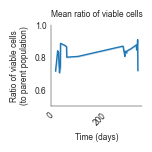

In [35]:
custom_theme(6)

#plot the mean ratio of viable cells per date_analyzed, region, and antibody
plt.figure(figsize=(1.5, 1.5))
sns.lineplot(data=processed_merge_via, x='date_analyzed_relative_days', y='mean_ratio_viable', linewidth=1)
plt.title('Mean ratio of viable cells')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5,1)
plt.xlabel('Time (days)')
plt.ylabel('Ratio of viable cells\n(to parent population)')

#remove gridlines for a clean plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.tight_layout()
#plt.savefig('figs/viable cells over time.pdf', dpi=300)
plt.show()

In [36]:
#drop duplicates i mean_ratio_viable in processed_merge_via. grouped by date_analyzed and region
processed_merge_via_unique = processed_merge_via.drop_duplicates(subset=['date_analyzed', 'mean_ratio_viable'])
processed_merge_via_unique.head()

,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,...,15sd_per_pos,20sd_per_pos,30sd_per_pos,ssc_gate_events,live_gate_events,3sd_mfi,ratio_viable,mean_ratio_viable,date_analyzed_relative,date_analyzed_relative_days
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,...,82.19,76.48,65.21,12075.0,8703.0,2142.52,0.720745,0.717102,0 days,0
468,LRTM1,2020-06-25,vHB,acc,pe,2020-05-13,2,94.34,0.78,4.34,...,0.08,0.06,0.02,10590.0,8971.0,271.99,0.847120,0.842987,8 days,8
5,ALCAM,2020-06-26,dFB,acc,pe,2020-05-13,2,341.42,73.14,85.67,...,16.18,6.51,1.05,10298.0,8760.0,379.64,0.850651,0.821696,9 days,9
7,ALCAM,2020-06-27,cVM,pap,pe,2020-05-13,2,1664.84,88.88,91.83,...,65.81,56.35,40.52,8656.0,6990.0,1797.54,0.807532,0.823936,10 days,10
8,ALCAM,2020-06-28,dFB,pap,pe,2020-05-13,2,447.41,73.86,86.03,...,21.35,10.31,2.12,16036.0,13941.0,498.16,0.869356,0.835099,11 days,11


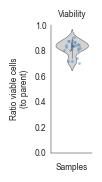

In [37]:
custom_theme(6)

#make a violin plot of processed_merge_via with only one cathegory on the x-axis that includes all the data, y-axis is the mean_ratio_viable
plt.figure(figsize=(1, 1.8))
sns.violinplot(data=processed_merge_via_unique, y='mean_ratio_viable', color='lightgray', linewidth=0.5)
sns.stripplot(data=processed_merge_via_unique, y='mean_ratio_viable', #hue='date_analyzed_relative_days', 
              size=2, jitter=0.2, alpha=0.4)
plt.title('Viability')
plt.ylabel('Ratio viable cells\n(to parent)')
plt.xlabel('Samples')
plt.ylim(0,1)

#remove gridlines for a clean plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.tight_layout()
#plt.savefig('figs/viable cells violin.pdf', dpi=300)
plt.show()

Viable cells over time

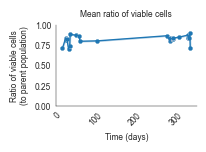

In [38]:
custom_theme(6)

#plot the mean ratio of viable cells per date_analyzed, region, and antibody
plt.figure(figsize=(2, 1.5))
sns.lineplot(data=processed_merge_via, x='date_analyzed_relative_days', y='mean_ratio_viable', linewidth=1)
sns.scatterplot(data=processed_merge_via, x='date_analyzed_relative_days', y='mean_ratio_viable', s=10, alpha=0.2)
plt.title('Mean ratio of viable cells')
plt.xticks(rotation=45, ha='right')
plt.ylim(0,1)
plt.xlabel('Time (days)')
plt.ylabel('Ratio of viable cells\n(to parent population)')

#remove gridlines for a clean plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.tight_layout()
#plt.savefig('figs/viable cells over time.pdf', dpi=300)
plt.show()

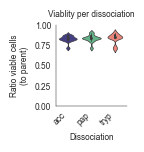

In [39]:
#set the levels of the region column
processed_merge_via['dissoc'] = pd.Categorical(processed_merge_via['dissoc'], 
                                               categories=['acc', 'pap', 'tryp'],
                                               ordered=True)

dissoc_pal = sns.color_palette(['#3C358F', '#58BF88', '#FF7769'])

custom_theme(6)

#plot the mean ratio of viable cells per date_analyzed, region, and antibody
plt.figure(figsize=(1.3, 1.5))
sns.violinplot(data=processed_merge_via, x='dissoc', y='mean_ratio_viable', linewidth=0.5, palette=dissoc_pal)
plt.title('Viablity per dissociation')
plt.ylim(0,1)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Dissociation')
plt.ylabel('Ratio viable cells\n(to parent)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.tight_layout()
#plt.savefig('figs/viable cells per dissoc.pdf', dpi=300)
plt.show()

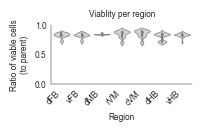

In [40]:
#remove the _2 from the dMB_2 region
processed_merge_via['region'] = processed_merge_via['region'].str.replace('_2', '')

#set the levels of the region column
processed_merge_via['region'] = pd.Categorical(processed_merge_via['region'], 
                                               categories=['dFB', 'vFB', 'dMB', 
                                                           'rVM', 'cVM', 'dHB', 'vHB'],
                                                ordered=True)

custom_theme(6)
plt.figure(figsize=(2, 1.3))
sns.violinplot(data=processed_merge_via, x='region', y='mean_ratio_viable', 
               inner='box', color='lightgray', linewidth=0.5, scale='width')
plt.title('Viablity per region')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.xlabel('Region')
plt.ylabel('Ratio of viable cells\n(to parent)')

#remove gridlines for a clean plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(0.3)
plt.gca().spines['left'].set_linewidth(0.3)
plt.tight_layout()
#plt.savefig('figs/viable cells per region.pdf', dpi=300)
plt.show()

### Normalize and correlate

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/2834662115.py:12: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  processed_merge = processed_merge.groupby(['date_analyzed', 'region', 'dissoc', 'fluo']).apply(normalize_3sd_mfi).reset_index(drop=True)
/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/2834662115.py:26: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)



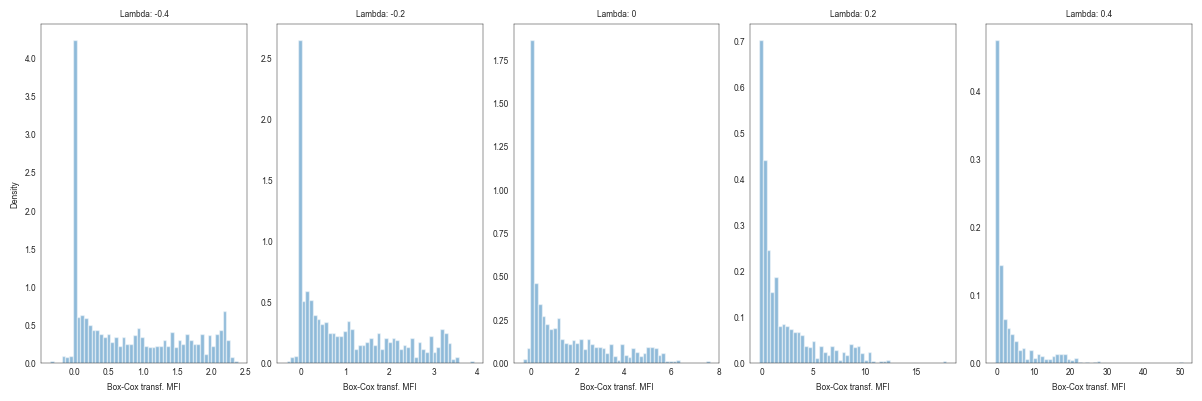

Index(['antibody', 'date_analyzed', 'region', 'dissoc', 'fluo',
       'culture_start', 'batch', 'mfi', 'per_pos_py', '3sd_per_pos',
       'per_pos_manual', '8sd_per_pos', '10sd_per_pos', '15sd_per_pos',
       '20sd_per_pos', '30sd_per_pos', 'ssc_gate_events', 'live_gate_events',
       '3sd_mfi', '3sd_mfi_norm', 'mfi_norm', 'mfi_norm_boxcox',
       'mfi_norm_log10'],
      dtype='object')


/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [41]:
#define a function to normalize the '10sd_mfi' to the 'mfi' for the corresponding fmo
def normalize_3sd_mfi(group):
    unstained_rows = group[group['antibody'] == 'unstained']['3sd_mfi']
    if unstained_rows.empty:
        group['3sd_mfi_norm'] = group['3sd_mfi']
    else:
        unstained_value = unstained_rows.values[0]
        group['3sd_mfi_norm'] = (group['3sd_mfi'] - unstained_value) / unstained_value
    return group

#apply the function to the merged dataframe
processed_merge = processed_merge.groupby(['date_analyzed', 'region', 'dissoc', 'fluo']).apply(normalize_3sd_mfi).reset_index(drop=True)


#define a function to normalize the mfi_value to the corresponding fmo
def normalize_mfi(group):
    unstained_rows = group[group['antibody'] == 'unstained']['mfi']
    if unstained_rows.empty:
        group['mfi_norm'] = group['mfi']
    else:
        unstained_value = unstained_rows.values[0]
        group['mfi_norm'] = (group['mfi'] - unstained_value) / unstained_value
    return group

#apply the function to the merged dataframe
processed_merge = processed_merge.groupby(['date_analyzed', 'region', 'dissoc', 'fluo']).apply(normalize_mfi).reset_index(drop=True)

#transform the data and plot to inspect the distribution
#after testing several cofactors for the biexponential (np.arcsinh(merge['mfi_value_norm'] / cofactor)), it was that this was a suboptimal transformation method. 
#box-cox was appeared to be a better choice as it creates a bimodal distribution at lambda < 0, which is expected for per_pos variable

# List of lambda values to test
lambdas = [-0.4, -0.2, 0, 0.2, 0.4]

# Create subplots for each lambda value
fig, axs = plt.subplots(1, len(lambdas), figsize=(12, 4))

# Loop through lambda values and plot the transformed data
for i, lmbda in enumerate(lambdas):
    transformed_data = boxcox(processed_merge['mfi_norm'] + 1, lmbda=lmbda)

    ax = axs[i]
    ax.hist(transformed_data, bins=50, density=True, alpha=0.5)
    ax.set_title(f'Lambda: {lmbda}')
    ax.set_xlabel('Box-Cox transf. MFI')

    # Only show y-axis label for the first subplot
    if i == 0:
        ax.set_ylabel('Density')

plt.tight_layout()
plt.show()


#transform with box-cox and log10 
processed_merge['mfi_norm_boxcox'] = boxcox(processed_merge['mfi_norm'] + 1, lmbda = 0.2)
#log10 is undefined for normalised MFI <= 0 (e.g. the unstained controls), so those become NaN
processed_merge['mfi_norm_log10'] = np.where(processed_merge['mfi_norm'] > 0, np.log10(processed_merge['mfi_norm'].where(processed_merge['mfi_norm'] > 0)), np.nan)

#select columns with numerical data
print(processed_merge.columns)

In [42]:
#save the processed, cleaned and normalized dataframe
#set today's date
todays_date = datetime.datetime.now().strftime('%y%m%d')

#save the processed dataframe
processed_merge.to_csv(f'output/regional spec cleaned processed merged py manual {todays_date}.csv', index=False)

#read the processed dataframe
processed_merge = pd.read_csv(f'output/regional spec cleaned processed merged py manual {todays_date}.csv')
processed_merge.head()

,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,...,15sd_per_pos,20sd_per_pos,30sd_per_pos,ssc_gate_events,live_gate_events,3sd_mfi,3sd_mfi_norm,mfi_norm,mfi_norm_boxcox,mfi_norm_log10
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,...,82.19,76.48,65.21,12075.0,8703.0,2142.52,2142.520000,2080.700000,18.049082,3.318209
1,ALCAM,2020-06-17,dFB,tryp,pe,2020-05-13,2,540.88,82.96,91.66,...,34.65,19.44,5.38,15717.0,11970.0,578.07,1.659383,7.809121,2.726032,0.892602
2,ALCAM,2020-06-17,vFB,tryp,pe,2020-05-13,2,334.61,56.74,74.35,...,9.23,3.50,0.58,15747.0,11788.0,406.48,0.793901,4.604858,2.058021,0.663216
3,ALCAM,2020-06-17,vHB,tryp,pe,2020-05-13,2,94.18,1.88,5.28,...,0.29,0.22,0.07,10517.0,6971.0,286.95,0.288852,0.281535,0.254315,-0.550468
4,ALCAM,2020-06-25,vHB,acc,pe,2020-05-13,2,96.75,1.00,4.39,...,0.12,0.07,0.03,9452.0,7678.0,290.59,0.197692,0.285202,0.257318,-0.544848


Parameter correlation

In [43]:
#drop the columns that are not needed for the correlation matrix
processed_merge = processed_merge.drop(['ssc_gate_events', 'live_gate_events'], axis=1)
processed_merge.head()

,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,...,8sd_per_pos,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,3sd_mfi,3sd_mfi_norm,mfi_norm,mfi_norm_boxcox,mfi_norm_log10
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,...,91.10,88.59,82.19,76.48,65.21,2142.52,2142.520000,2080.700000,18.049082,3.318209
1,ALCAM,2020-06-17,dFB,tryp,pe,2020-05-13,2,540.88,82.96,91.66,...,66.93,56.84,34.65,19.44,5.38,578.07,1.659383,7.809121,2.726032,0.892602
2,ALCAM,2020-06-17,vFB,tryp,pe,2020-05-13,2,334.61,56.74,74.35,...,34.17,23.78,9.23,3.50,0.58,406.48,0.793901,4.604858,2.058021,0.663216
3,ALCAM,2020-06-17,vHB,tryp,pe,2020-05-13,2,94.18,1.88,5.28,...,0.82,0.55,0.29,0.22,0.07,286.95,0.288852,0.281535,0.254315,-0.550468
4,ALCAM,2020-06-25,vHB,acc,pe,2020-05-13,2,96.75,1.00,4.39,...,0.42,0.33,0.12,0.07,0.03,290.59,0.197692,0.285202,0.257318,-0.544848


Correlation 1

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/2852139431.py:39: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


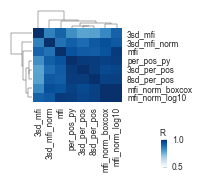

In [44]:
processed_merge_corr = processed_merge.drop(['date_analyzed', 'region', 'dissoc', 'fluo', 'culture_start', 'batch', 'antibody',
                                             'per_pos_manual', '10sd_per_pos', '15sd_per_pos',
                                             '20sd_per_pos', '30sd_per_pos', #'10sd_mfi',
                                             'mfi_norm'], axis=1)

processed_merge_corr.columns
processed_merge_corr.head()


correlation_matrix = processed_merge_corr.corr(method = 'spearman')

#plot as heatmap
custom_theme(6)
clustermap = sns.clustermap(correlation_matrix, annot=False, cmap='Blues', figsize=(2, 1.8), vmin=0.5, vmax=1)
plt.draw()


#adjust row dendrogram lines
for collection in clustermap.ax_row_dendrogram.collections:
    collection.set_linewidth(0.3)

#adjust column dendrogram lines
for collection in clustermap.ax_col_dendrogram.collections:
    collection.set_linewidth(0.3)

#add color bar legend
colorbar = clustermap.ax_heatmap.collections[0].colorbar

#adjust position and size of the color bar
colorbar.ax.set_position([0.8, 0.08, 0.03, 0.15])  # [left, bottom, width, height]

#set color bar label above the color bar and rotate
colorbar.set_label('R', labelpad=20, rotation=0)

#fine-tune position of the label
colorbar.ax.yaxis.set_label_position('left')
colorbar.ax.yaxis.set_label_coords(0.3, 1.05)  # (x, y) coordinates

plt.tight_layout()
#plt.savefig('figs/parameter corr small.pdf', dpi = 300)
plt.show()


Correlation 2

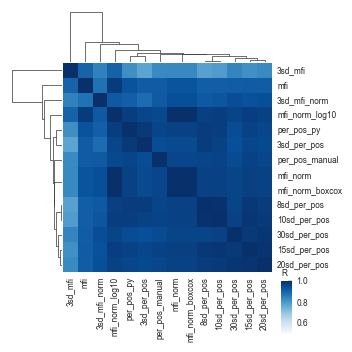

In [45]:
processed_merge_corr = processed_merge.iloc[:, 6:]
processed_merge_corr = processed_merge_corr.drop(['batch'], axis=1)
processed_merge_corr.head()

#perform correlation 
correlation_matrix = processed_merge_corr.corr(method = 'spearman')

#plot
custom_theme(6)
clustermap = sns.clustermap(correlation_matrix, annot=False, cmap='Blues', figsize=(3.5, 3.5), vmin=0.5, vmax=1)
colorbar = clustermap.ax_heatmap.collections[0].colorbar
colorbar.ax.set_position([0.8, 0.05, 0.03, 0.15])  # [left, bottom, width, height]
colorbar.set_label('R', labelpad=20, rotation=0)
colorbar.ax.yaxis.set_label_position('left')
colorbar.ax.yaxis.set_label_coords(0.3, 1.05)  # (x, y) coordinates
#plt.savefig('figs/parameter corr.pdf', bbox_inches='tight')
plt.show()

Correlate all parameters

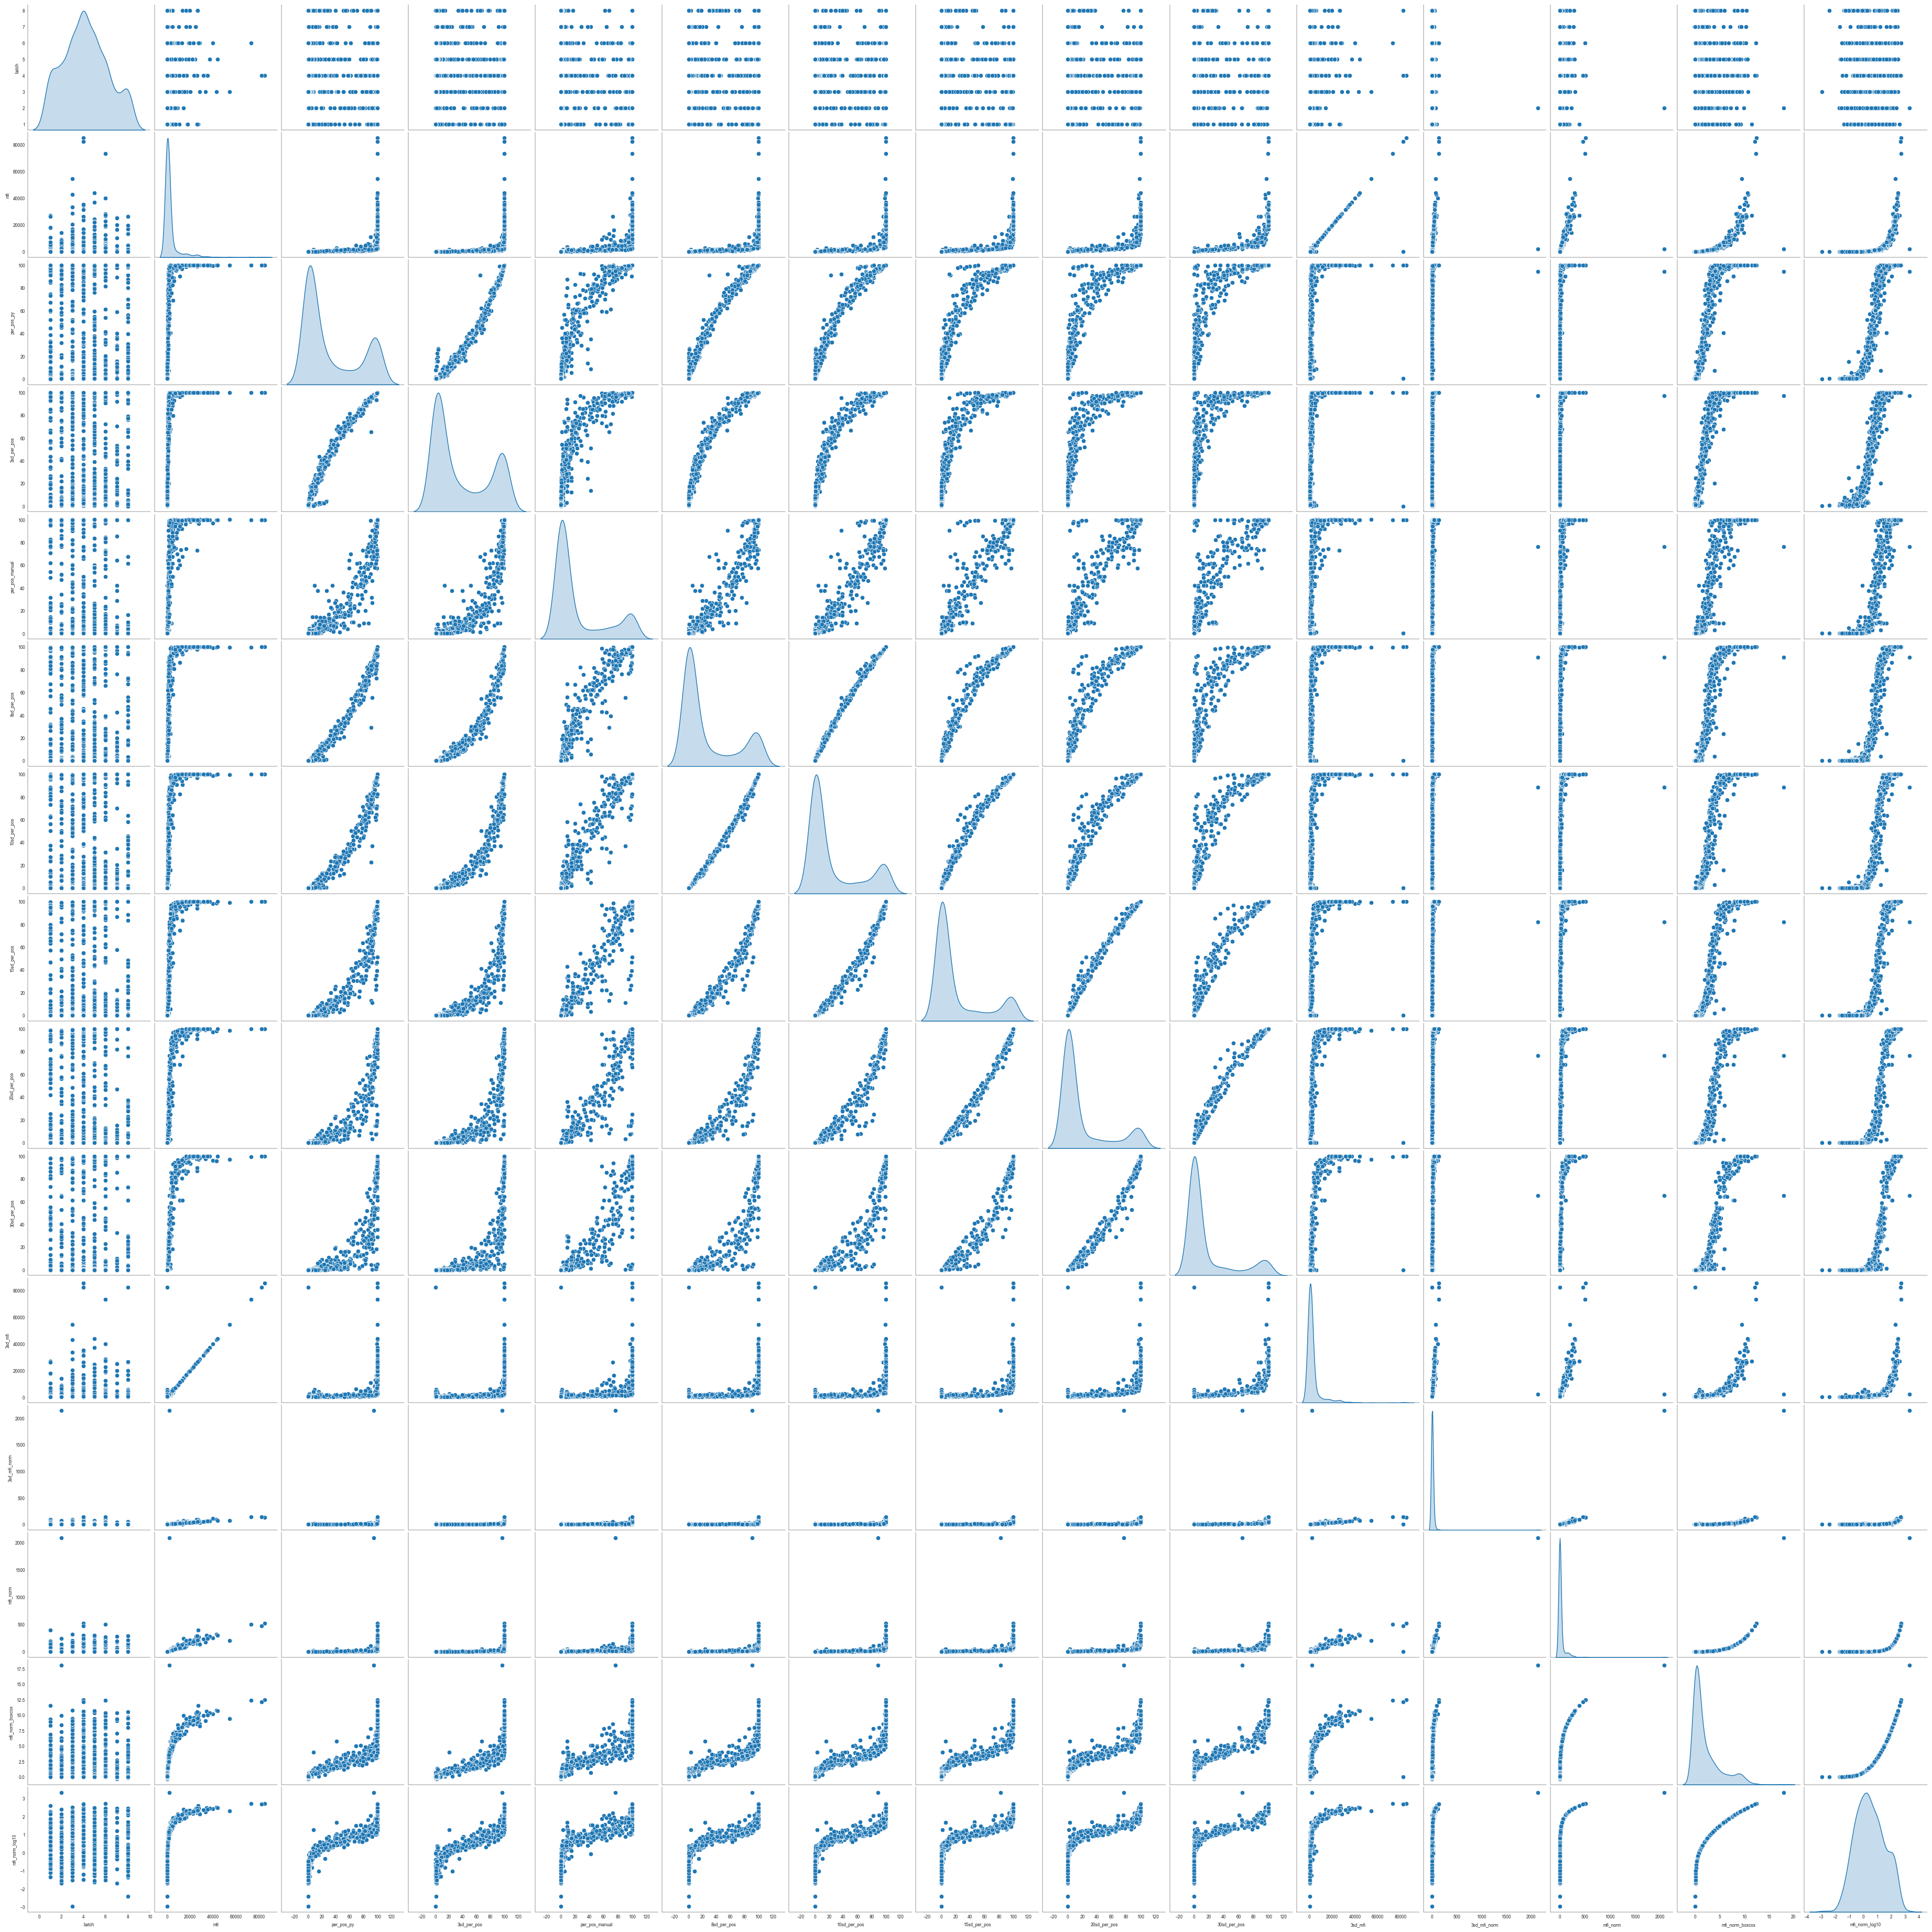

In [46]:
numeric_data = processed_merge.select_dtypes(include=['number'])

#plot as pairplot
custom_theme(6)
sns.pairplot(data=numeric_data, diag_kind='kde')
plt.show()

### Explore outliers

Linear vs polynomial regression

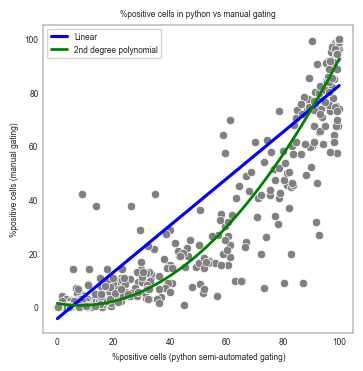

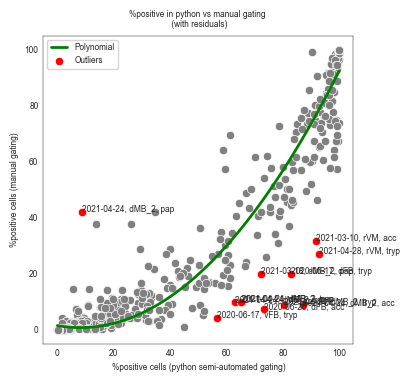

In [47]:
custom_theme(6)

#scatter and linear regression plot
plt.figure(figsize=(4, 4))
sns.scatterplot(x=processed_merge['per_pos_py'], y=processed_merge['per_pos_manual'], color="gray")
sns.regplot(x=processed_merge['per_pos_py'], y=processed_merge['per_pos_manual'], scatter=False, line_kws={"color": "blue"}, label='Linear', ci=None)

#polynomial regression
x = processed_merge['per_pos_py']
y = processed_merge['per_pos_manual']
p = Polynomial.fit(x, y, 2)  
xp = np.linspace(x.min(), x.max(), 100)
plt.plot(xp, p(xp), 'g-', label='2nd degree polynomial', linewidth=2)

plt.xlabel('%positive cells (python semi-automated gating)')
plt.ylabel('%positive cells (manual gating)')

plt.title('%positive cells in python vs manual gating') 
plt.legend()
plt.show()


#2nd degree polynomial regression appears as the better fit. identify outliers
#calculate the residuals

#fit 2nd degress polynomial regression model
x = processed_merge['per_pos_py']
y = processed_merge['per_pos_manual']
X = sm.add_constant(np.column_stack([x, x**2]))

polynomial_model = sm.OLS(y, X)
results = polynomial_model.fit()

#calculate residuals
processed_merge['residuals'] = results.resid

#calculate the mean and standard deviation of the residuals
mean_resid = np.mean(processed_merge['residuals'])
std_resid = np.std(processed_merge['residuals'])


#identify outliers
processed_merge['is_outlier'] = ((processed_merge['residuals'] - mean_resid).abs() > 3*std_resid)

#label outliers
processed_merge['label'] = processed_merge[['date_analyzed', 'region', 'dissoc']].astype(str).agg(', '.join, axis=1)


#scatter and linear regression plot
plt.figure(figsize=(4, 4))
sns.scatterplot(x=processed_merge['per_pos_py'], y=processed_merge['per_pos_manual'], color="gray")

#polynomial regression
x = processed_merge['per_pos_py']
y = processed_merge['per_pos_manual']
p = Polynomial.fit(x, y, 2)  # Change the 2 to any other number for a different degree polynomial
xp = np.linspace(x.min(), x.max(), 100)
plt.plot(xp, p(xp), 'g-', label='Polynomial', linewidth = 2)

#plot the residuals (outliers)
sns.scatterplot(x=processed_merge.loc[processed_merge['is_outlier'], 'per_pos_py'], y=processed_merge.loc[processed_merge['is_outlier'], 'per_pos_manual'], color='red', label='Outliers')
plt.xlabel('%positive cells (python semi-automated gating)')
plt.ylabel('%positive cells (manual gating)')
plt.title('%positive in python vs manual gating \n (with residuals)')  
plt.legend()

#label outliers
for i in processed_merge[processed_merge['is_outlier']].index:
    plt.text(processed_merge['per_pos_py'][i], processed_merge['per_pos_manual'][i], processed_merge['label'][i])

plt.show()

In [48]:
#create a dataframe without the outliers and make a copy
processed_merge_outliers = processed_merge[processed_merge['is_outlier'] == False]
processed_merge_outliers_copy = processed_merge_outliers.copy()

#make a list of the dataframes to compare
df_to_compare = {'with_outliers' : processed_merge, 'without_outliers' : processed_merge_outliers_copy}

#create a for loop to compare the correlation with and without the outliers
for name, df in df_to_compare.items(): 
    #drop the columns that are not of interest
    df = df.drop(['is_outlier', 'residuals', 'label', 'batch', 'fluo'], axis=1)
    
    #perform correlation between python and manual gating
    corr, p_value = spearmanr(df['per_pos_py'], df['per_pos_manual'])

    #print results
    print({name})
    print(f'r: {round(corr, 3)}')
    print(f'P-value: {p_value:.2e}' + '\n')

#the correlation is essentially the same with and without the outliers but inspect the dataframe to identify the outliers
outliers = processed_merge[processed_merge['is_outlier'] == True]
outliers.drop(['fluo', 'batch', 'mfi', 'mfi_norm', 'mfi_norm_log10', 'residuals', 'is_outlier', 'label'], axis=1, inplace=True)
outliers

#although the general trend is very clear, some of values are outside the expected range. this means that the outliers were correctly identified based upon their residuals
#specifically the date 2021-04-28 but also 2021-03-18, 2021-03-10 (APCDD1), 2021-03-03 (FOLR1), 2020-06-17 (ALCAM) needs to be investigated further
#outliers.to_csv('output/outliers regional spec gating.csv', index=False)

{'with_outliers'}
r: 0.962
P-value: 0.00e+00

{'without_outliers'}
r: 0.962
P-value: 0.00e+00



/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/317234852.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers.drop(['fluo', 'batch', 'mfi', 'mfi_norm', 'mfi_norm_log10', 'residuals', 'is_outlier', 'label'], axis=1, inplace=True)


,antibody,date_analyzed,region,dissoc,culture_start,per_pos_py,3sd_per_pos,per_pos_manual,8sd_per_pos,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,3sd_mfi,3sd_mfi_norm,mfi_norm_boxcox
1,ALCAM,2020-06-17,dFB,tryp,2020-05-13,82.96,91.660,19.806000,66.930,56.84,34.650,19.440,5.38,578.070,1.659383,2.726032
2,ALCAM,2020-06-17,vFB,tryp,2020-05-13,56.74,74.350,4.048000,34.170,23.78,9.230,3.500,0.58,406.480,0.793901,2.058021
5,ALCAM,2020-06-26,dFB,acc,2020-05-13,73.14,85.670,7.224000,49.470,37.03,16.180,6.510,1.05,379.640,0.995847,1.951339
110,APCDD1,2021-03-10,rVM,acc,2020-09-07,91.93,95.740,31.750000,75.950,66.40,46.610,33.110,18.66,1403.160,2.838490,2.790910
139,APCDD1,2021-04-24,dMB_2,acc,2020-09-28,87.26,93.710,8.897500,67.440,58.27,42.950,35.660,29.84,3765.310,9.122617,4.765711
141,APCDD1,2021-04-24,dMB_2,pap,2020-09-14,8.86,13.570,42.030333,5.790,4.77,3.100,2.240,1.26,705.790,1.133779,0.658483
143,APCDD1,2021-04-24,dMB_2,tryp,2020-09-28,80.27,90.250,8.897500,56.090,45.50,33.250,28.840,25.32,2315.610,6.550943,4.030084
154,APCDD1,2021-04-28,rVM,tryp,2020-06-23,92.68,97.180,26.905000,82.350,73.92,54.320,39.200,22.94,2187.100,3.623743,3.240696
199,CNTN2,2021-03-18,dMB_2,pap,2020-06-23,72.22,82.175,19.786000,58.095,50.49,36.295,27.145,16.44,1164.235,2.900938,2.713511
597,TPBG,2021-04-24,dMB_2,acc,2020-09-28,63.19,75.880,9.840500,44.490,39.39,33.700,31.360,28.52,1979.530,4.321746,3.272867


Identify outliers from the regression residuals

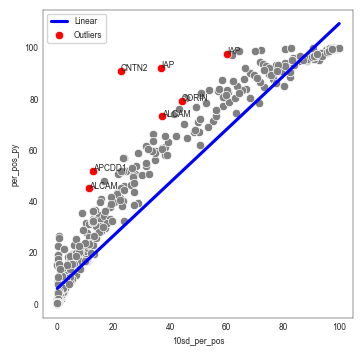

In [49]:
#scatter and linear regression plot
plt.figure(figsize=(4, 4))
sns.scatterplot(x=processed_merge['10sd_per_pos'], y=processed_merge['per_pos_py'], color="gray")
sns.regplot(x=processed_merge['10sd_per_pos'], y=processed_merge['per_pos_py'], scatter=False, line_kws={"color": "blue"}, label='Linear', ci=None)

#calculate the residuals
#fit linear regression model
X = sm.add_constant(processed_merge['10sd_per_pos'])
y = processed_merge['per_pos_py']
lm = sm.OLS(y, X)
results = lm.fit()
processed_merge['residuals'] = results.resid
mean_resid = np.mean(processed_merge['residuals'])
std_resid = np.std(processed_merge['residuals'])
processed_merge['is_outlier'] = ((processed_merge['residuals'] - mean_resid).abs() > 3*std_resid)

#label outliers
processed_merge['label'] = processed_merge[['antibody']]

#plot the residuals (outliers)
sns.scatterplot(x=processed_merge.loc[processed_merge['is_outlier'], '10sd_per_pos'], y=processed_merge.loc[processed_merge['is_outlier'], 'per_pos_py'], color='red', label='Outliers')

#label outliers
for i in processed_merge[processed_merge['is_outlier']].index:
    plt.text(processed_merge['10sd_per_pos'][i], processed_merge['per_pos_py'][i], processed_merge['label'][i])

plt.show()

Confirm that there are no outliers

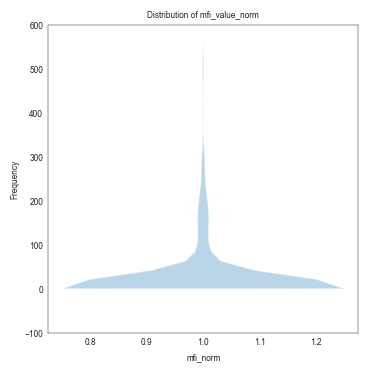

antibody
ALCAM    1
IAP      3
dtype: int64


,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,...,8sd_per_pos,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,3sd_mfi,3sd_mfi_norm,mfi_norm,mfi_norm_boxcox,mfi_norm_log10
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,...,91.10,88.59,82.19,76.48,65.21,2142.52,2142.52000,2080.70000,18.04908,3.31821
443,IAP,2021-04-23,rVM,tryp,pe_cy7,2020-09-07,6,73203.36,99.94,99.94,...,99.91,99.91,99.81,99.75,99.51,73084.65,140.53543,502.77373,12.35470,2.70137
462,IAP,2021-04-28,rVM,pap,pe_cy7,2020-06-23,4,85092.51,100.00,100.00,...,100.00,100.00,100.00,100.00,99.69,85092.51,134.42431,516.18538,12.44614,2.71281
463,IAP,2021-04-28,rVM,tryp,pe_cy7,2020-06-23,4,82253.66,99.98,99.98,...,99.96,99.96,99.96,99.93,99.82,82213.42,136.82404,468.10950,12.10901,2.67035


In [50]:
#copy the df to avoid overwriting
processed_merge_copy = processed_merge.copy()

#remove redundant columns
processed_merge_copy.drop(['is_outlier', 'residuals', 'label', 'batch', 'fluo'], axis=1)

#round the columns to 5 decimals
cols_to_round = ['mfi', 'mfi_norm', 'mfi_norm_boxcox', 'mfi_norm_log10', #'10sd_mfi', 
                 '3sd_mfi_norm',
                 '3sd_per_pos', 'per_pos_py', 'per_pos_manual']
for col in cols_to_round:
    processed_merge_copy[col] = processed_merge_copy[col].round(5)

processed_merge_copy.drop(['residuals', 'is_outlier', 'label'], axis=1, inplace=True)

#inspect the mfi_norm variable distribution
plt.figure(figsize=(4,4))
plt.violinplot(processed_merge_copy['mfi_norm'], showextrema=False)
plt.xlabel('mfi_norm')
plt.ylabel('Frequency')
plt.title('Distribution of mfi_value_norm')
plt.ylim(-100, 600)
plt.show()

#it looks quite uniform, inspect the large values
large_mfi = processed_merge_copy[processed_merge_copy['mfi_norm'] > 400]

print(large_mfi.groupby(['antibody']).size())
large_mfi.head()

#they are exclusively from iap, which is normal since it has a higher fluorescence than the other antibodies/fluorophores

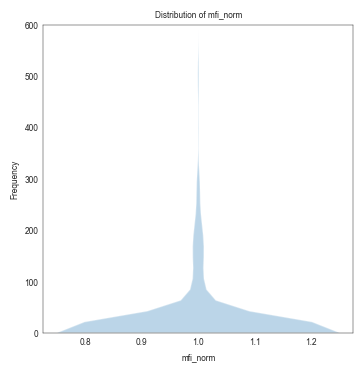

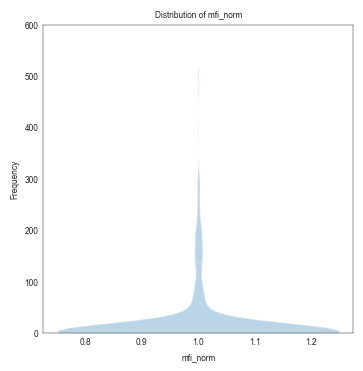

In [51]:
#inspect again to confirm that it doesn't make sense to filter out these values
def plot_violin(df, column, scatter_data=None, ymax=None):
    plt.figure(figsize=(4,4))
    plt.violinplot(df[column], showextrema=False)
    if scatter_data is not None:
        plt.scatter([1]*len(scatter_data), scatter_data, alpha = 0.4)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')
    plt.ylim(0, ymax)
    plt.show()

large_mfi = processed_merge_copy[processed_merge_copy['mfi_norm'] > 2000]
plot_violin(processed_merge_copy, 'mfi_norm', large_mfi['mfi_norm'], ymax=600)

processed_merge_filt = processed_merge_copy[processed_merge_copy['mfi_norm'] <= 2000]
plot_violin(processed_merge_filt, 'mfi_norm', ymax=600)

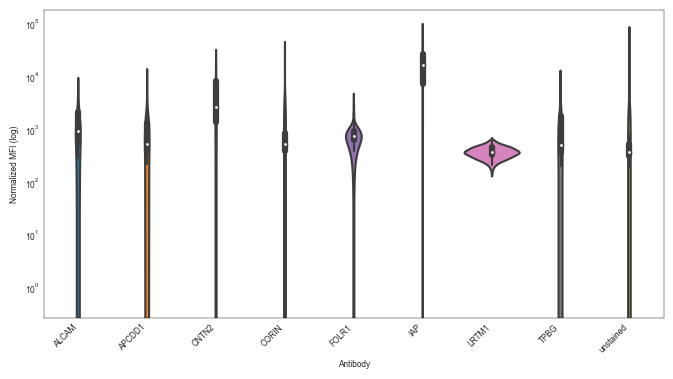

In [52]:
#i don't spot any outlier. however, inspect the mfi_norm for each antibody and batch by plotting a violin plot colored by the batch. create separe plots for each antibody
antibodies = processed_merge['antibody'].unique()

#inspect the distribution of the residuals
plt.figure(figsize=(8,4))
sns.violinplot(x=processed_merge['antibody'], y=processed_merge['3sd_mfi'])
plt.xlabel('Antibody')
plt.ylabel('Normalized MFI (log)') 
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.show()

## Plot

In [53]:
processed_merge = pd.read_csv(f'output/regional spec cleaned processed merged py manual {todays_date}.csv')

#set the levels of 'region'
levels = ['dFB', 'vFB', 'dMB_2', 'rVM', 'cVM', 'dHB', 'vHB']
cat_type = CategoricalDtype(categories=levels, ordered=True)
processed_merge['region'] = processed_merge['region'].astype(cat_type)

#remove the unstained
processed_merge = processed_merge[processed_merge['antibody'] != 'unstained']

#inspect
print(processed_merge['antibody'].unique())
print(processed_merge['region'].unique())
processed_merge.head()

['ALCAM' 'APCDD1' 'CNTN2' 'CORIN' 'FOLR1' 'IAP' 'LRTM1' 'TPBG']
['cVM', 'dFB', 'vFB', 'vHB', 'rVM', 'dHB', 'dMB_2']
Categories (7, object): ['dFB' < 'vFB' < 'dMB_2' < 'rVM' < 'cVM' < 'dHB' < 'vHB']


,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,...,15sd_per_pos,20sd_per_pos,30sd_per_pos,ssc_gate_events,live_gate_events,3sd_mfi,3sd_mfi_norm,mfi_norm,mfi_norm_boxcox,mfi_norm_log10
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,...,82.19,76.48,65.21,12075.0,8703.0,2142.52,2142.520000,2080.700000,18.049082,3.318209
1,ALCAM,2020-06-17,dFB,tryp,pe,2020-05-13,2,540.88,82.96,91.66,...,34.65,19.44,5.38,15717.0,11970.0,578.07,1.659383,7.809121,2.726032,0.892602
2,ALCAM,2020-06-17,vFB,tryp,pe,2020-05-13,2,334.61,56.74,74.35,...,9.23,3.50,0.58,15747.0,11788.0,406.48,0.793901,4.604858,2.058021,0.663216
3,ALCAM,2020-06-17,vHB,tryp,pe,2020-05-13,2,94.18,1.88,5.28,...,0.29,0.22,0.07,10517.0,6971.0,286.95,0.288852,0.281535,0.254315,-0.550468
4,ALCAM,2020-06-25,vHB,acc,pe,2020-05-13,2,96.75,1.00,4.39,...,0.12,0.07,0.03,9452.0,7678.0,290.59,0.197692,0.285202,0.257318,-0.544848


#### MFI (range scaled)

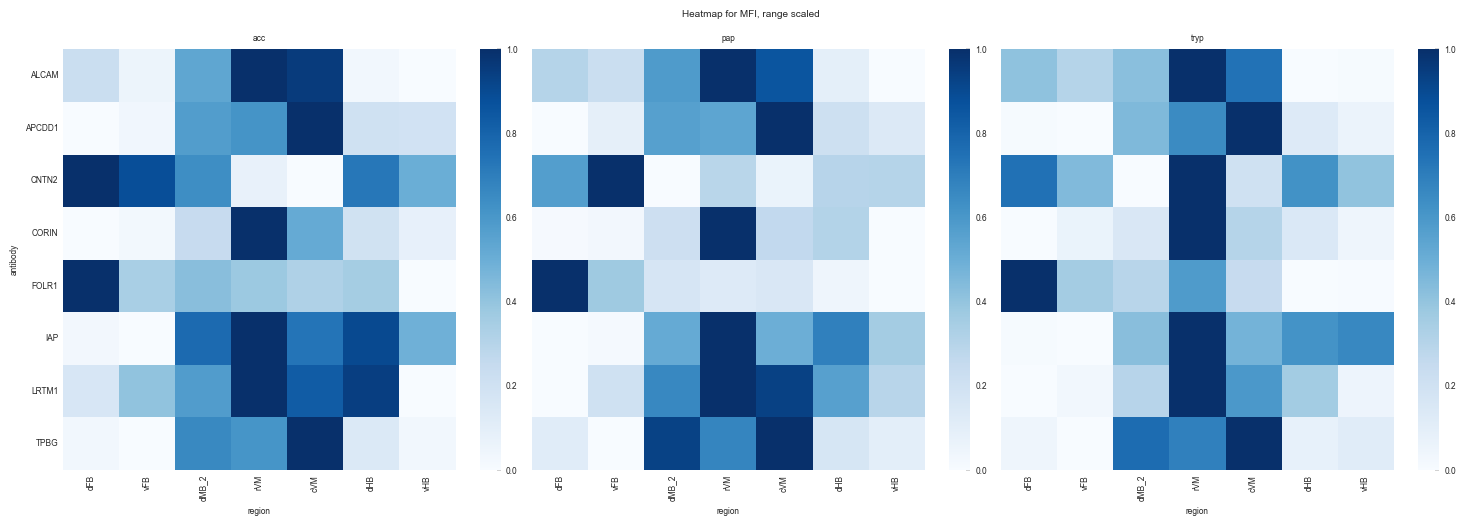

In [54]:
#calculate the log10 of the mfi column
processed_merge['mfi_log10'] = np.log10(processed_merge['mfi'])

#group the data by antibody, region and dissoc and calculate the mean of the mfi_value_norm_biex column
grouped_mean = processed_merge.groupby(['antibody', 'region', 'dissoc'])['mfi_log10'].mean().reset_index()

#do a range (min-max) scaling the mfi_value_norm_log10 column so that all values are between 0 and 1, grouped by antibody (for visualization)
epsilon = 1e-10  # small constant
grouped_mean['mfi_scaled'] = grouped_mean.groupby(['antibody', 'dissoc'])['mfi_log10'].transform(lambda x: (x - x.min()) / (x.max() - x.min() + epsilon))

#create a FacetGrid
g = sns.FacetGrid(grouped_mean, col="dissoc", col_wrap=3, height=5)

#define a function to draw the heatmap
def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index='antibody', columns='region', values='mfi_scaled')
    sns.heatmap(d, **kwargs)
    plt.yticks(rotation=0)
    plt.xticks(rotation=90)

#map the function to the FacetGrid
g = g.map_dataframe(draw_heatmap, cmap=sns.color_palette("Blues", as_cmap=True))

#set the titles
g = g.set_titles("{col_name}")
g.fig.suptitle('Heatmap for MFI, range scaled', y=1.03)

plt.show()

#### 3SD MFI

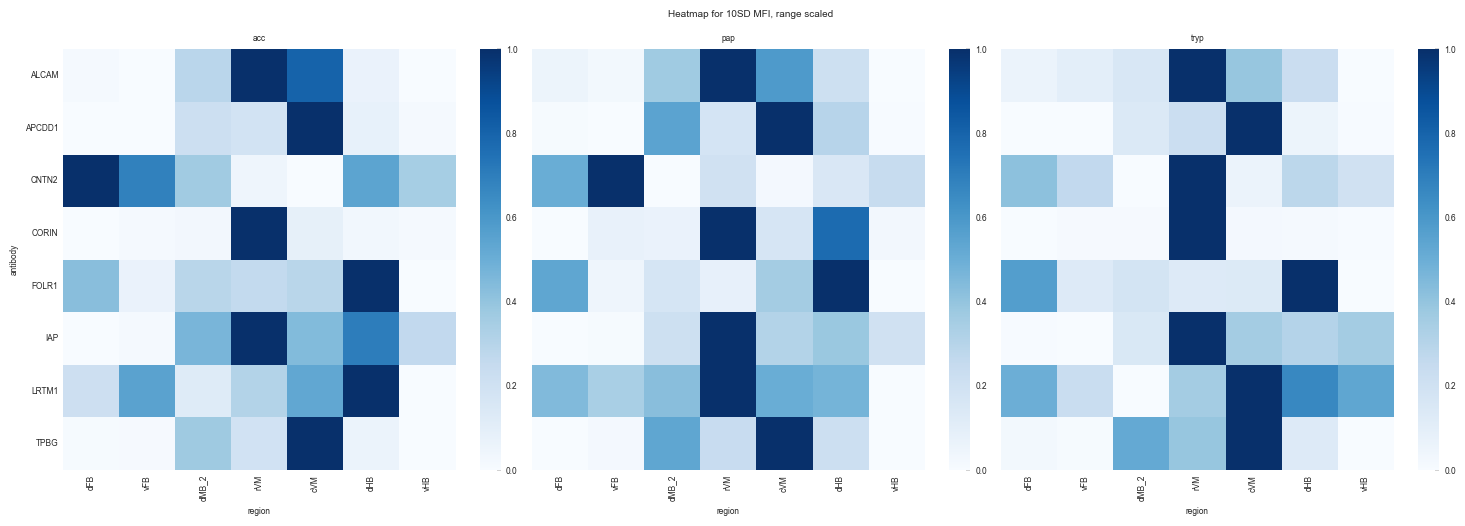

In [55]:
#group the data by antibody, region and dissoc and calculate the mean of the 10sd_mfi column
grouped_mean = processed_merge.groupby(['antibody', 'region', 'dissoc'])['3sd_mfi'].mean().reset_index()


# Do a range (min-max) scaling on the 10sd_mfi column so that all values are between 0 and 1, grouped by antibody and dissoc
epsilon = 1e-10  # small constant to avoid division by zero
grouped_mean['3sd_mfi_log10_scaled'] = grouped_mean.groupby(['antibody', 'dissoc'])['3sd_mfi'].transform(lambda x: (x - x.min()) / (x.max() - x.min() + epsilon))

# Create a FacetGrid
g = sns.FacetGrid(grouped_mean, col="dissoc", col_wrap=3, height=5)

# Define a function to draw the heatmap
def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index='antibody', columns='region', values='3sd_mfi_log10_scaled')
    sns.heatmap(d, **kwargs)
    plt.yticks(rotation=0)
    plt.xticks(rotation=90)

# Map the function to the FacetGrid
g = g.map_dataframe(draw_heatmap, cmap=sns.color_palette("Blues", as_cmap=True))

# Set the titles
g = g.set_titles("{col_name}")
g.fig.suptitle('Heatmap for 10SD MFI, range scaled', y=1.03)

plt.show()

### FACS plots

#### Helper functions

In [56]:
#1. colormap
#adjust the colormap for density coloring
def modify_colormap_alpha(cmap, alpha=1.0):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha  # Set the alpha channel
    return LinearSegmentedColormap.from_list(f"{cmap.name}_opaque", colors)

#load and modify the colormap
with open("../../color_palettes/batlow_colors.txt") as f:
    bilbao_colors = [line.strip() for line in f]

bilbao_cmap = LinearSegmentedColormap.from_list("bilbao", bilbao_colors)
opaque_bilbao_cmap = modify_colormap_alpha(bilbao_cmap, alpha=1.0)

#2. define gating helper
def apply_plotting_gates(s):
    """Apply the common gates used for plotting."""
    
    #1. cell gate
    g1 = FlowCal.gate.ellipse(
        s,
        channels=['FSC-A', 'SSC-A'],
        center=(7.2e4, 8e4),
        a=25000,
        b=60000,
        theta=-25 / 180 * np.pi
    )

    #2. fsc singlet gate
    g2 = FlowCal.gate.density2d(
        g1,
        channels=['FSC-A', 'FSC-W'],
        gate_fraction=0.92
    )

    #3. ssc singlet gate
    g3 = FlowCal.gate.density2d(
        g2,
        channels=['SSC-H', 'SSC-W'],
        gate_fraction=0.98
    )

    #4. live-cell gate
    g4 = FlowCal.gate.high_low(
        g3,
        channels=['Alexa Fluor 700-A'],
        high=1000
    )

    return g1, g2, g3, g4

#3. define density color helper
def get_density_colors(x, y, cmap=opaque_bilbao_cmap, gray_below_cutoff=False, cutoff=None):
    """Calculate density colors for scatter plot."""
    
    #calculate density for the scatter plot
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())

    #use density colors for all points
    if not gray_below_cutoff:
        colors = cmap(norm(z))
        return colors, norm

    #use density colors above cutoff and gray below cutoff
    colors = np.zeros((len(y), 4))
    above_cutoff_mask = y > cutoff

    #assign density colors to points above the cutoff
    colors[above_cutoff_mask] = cmap(norm(z)[above_cutoff_mask])

    #assign lighter gray with transparency to points below the cutoff
    colors[~above_cutoff_mask] = [0.85, 0.85, 0.85, 0.3]

    return colors, norm

#4. define fluorophore helper
def get_fluorophore_channel(filename, g4):
    """Return the relevant fluorophore channel and cutoff key."""
    
    #handle LRTM1 and AF488 unstained controls
    if 'LRTM1' in filename or 'unstained_ctrl_AF488' in filename:
        if 'Alexa Fluor 488-A' in g4.channels:
            return 'Alexa Fluor 488-A', 'AF488'
        elif 'PE-A' in g4.channels:
            return 'PE-A', 'PE'
        else:
            print(f"Neither 'PE-A' nor 'Alexa Fluor 488-A' available in {filename}")
            return None, None

    #handle IAP and PE-Cy7 unstained controls
    elif 'IAP' in filename or 'unstained_ctrl_PE' in filename:
        if 'PE-Cy7-A' in g4.channels:
            return 'PE-Cy7-A', 'PE-Cy7'
        else:
            print(f"Channel 'PE-Cy7-A' not available in {filename}")
            return None, None

    #handle PE antibodies and other unstained controls
    elif (
        'APCDD1' in filename or
        'TPBG' in filename or
        'CORIN' in filename or
        'ALCAM' in filename or
        'CNTN2' in filename or
        'FOLR1' in filename or
        'unstained_ctrl_' in filename
    ):
        if 'PE-A' in g4.channels:
            return 'PE-A', 'PE'
        else:
            print(f"Channel 'PE-A' not available in {filename}")
            return None, None

    else:
        print(f"No relevant condition met for {filename}")
        return None, None
    
#5. define title helper
def make_plot_title(filename, strings_keep, replacements=None):
    """Create a clean plot title from selected filename strings."""
    
    #clean the filename for the title
    title_parts = [string for string in strings_keep if string in filename]
    title = ' '.join(title_parts)

    #apply optional title replacements
    if replacements is not None:
        for old, new in replacements.items():
            title = title.replace(old, new)

    return title

#6. define general density scatter plotting helper
def plot_density_scatter(
    data,
    x_channel,
    y_channel,
    xlabel,
    ylabel,
    title='',
    figsize=(1.1, 1.1),
    xlim=None,
    ylim=None,
    yscale=None,
    rotate_xticks=True,
    xtick_ha='center',
    gray_below_cutoff=False,
    cutoff=None,
    cutoff_label=None,
    gated_mean=None,
    mfi=None,
    show_cutoff_text=False,
    show_gated_mean_text=False,
    show_mfi_text=False,
    output_path=None,
    dpi=300
):
    """Plot a density-colored scatter plot for selected flow channels."""
    
    #skip if the requested channels are missing
    if x_channel not in data.channels or y_channel not in data.channels:
        print(f"Skipping plot: {x_channel} or {y_channel} not found.")
        return

    #extract scatter data
    scatter_x = data[:, data.channels.index(x_channel)].astype('<f8')
    scatter_y = data[:, data.channels.index(y_channel)].astype('<f8')

    #calculate density colors
    colors, norm = get_density_colors(
        scatter_x,
        scatter_y,
        gray_below_cutoff=gray_below_cutoff,
        cutoff=cutoff
    )

    #plot the scatter plot
    plt.figure(figsize=figsize)
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')

    #add cutoff line
    if cutoff is not None:
        line_start_cutoff = 0
        line_end_cutoff = 3e5

        plt.hlines(
            y=cutoff,
            xmin=line_start_cutoff,
            xmax=line_end_cutoff,
            colors='#6dc8c0',
            linestyles='--',
            label=f"Cutoff: {cutoff:.2f}",
            linewidth=1
        )

    #add cutoff label
    if show_cutoff_text and cutoff is not None:
        plt.text(
            0.6e5,
            cutoff * 19,
            r'$MFI+3SD_{FMO}$' + '\n(=pos. gate)',
            fontsize=6,
            color='#6dc8c0',
            bbox=dict(facecolor='white', edgecolor='none', pad=0.2)
        )

    #add gated mean line
    if gated_mean is not None:
        line_start_mfi = 0.25e5
        line_end_mfi = 1.1e5

        plt.hlines(
            y=gated_mean,
            xmin=line_start_mfi,
            xmax=line_end_mfi,
            colors='#FF66B2',
            linestyles='-',
            label=f"Gated Mean: {gated_mean:.2f}",
            linewidth=1
        )

    #add gated mean label
    if show_gated_mean_text and gated_mean is not None:
        plt.text(
            0.85e5,
            gated_mean * 2,
            'MFI\n(in pos. gate)',
            fontsize=6,
            color='#FF66B2',
            bbox=dict(facecolor='white', edgecolor='none', pad=0.2)
        )

    #add mfi line
    if mfi is not None:
        line_start_mfi = 0.25e5
        line_end_mfi = 0.9e5

        plt.hlines(
            y=mfi,
            xmin=line_start_mfi,
            xmax=line_end_mfi,
            colors='#8A9A5B',
            linestyles='-',
            label=f"MFI: {mfi:.2f}",
            linewidth=1
        )

    #add mfi label
    if show_mfi_text and mfi is not None:
        plt.text(
            1e5,
            mfi * 0.6,
            r'$MFI_{FMO}$',
            fontsize=6,
            color='#8A9A5B'
        )

    #customize plot
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if xlim is not None:
        plt.xlim(*xlim)

    if ylim is not None:
        plt.ylim(*ylim)

    if yscale is not None:
        plt.yscale(yscale)
    if rotate_xticks:

        plt.xticks(rotation=45, ha=xtick_ha)

    plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

    if yscale != 'log':
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    plt.tight_layout()

    #save the plot (uncomment to save)
    if output_path is not None:
        output_dir = os.path.dirname(output_path)
        os.makedirs(output_dir, exist_ok=True)
        #plt.savefig(output_path, dpi=dpi) #uncomment to save plots from downstream code

    plt.show()
    plt.close()

#### Gating strategy

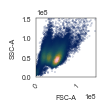

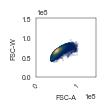

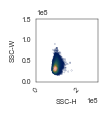

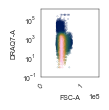

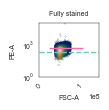

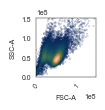

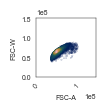

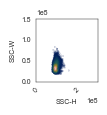

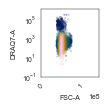

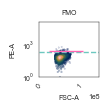

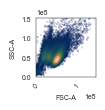

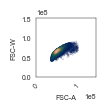

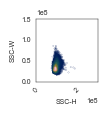

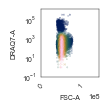

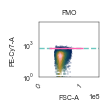

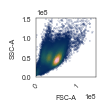

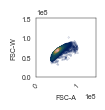

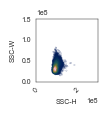

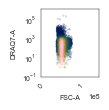

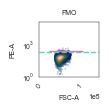

In [57]:
regions_of_interest = ['dFB', 'cVM']
dates_of_interest = ['200628', '200702', 'LRTM1_other_2ndary', '210310', '210317']
strings_keep = [
    'APCDD1', 'ALCAM', 'CORIN', 'LRTM1', 'TPBG',
    'FOLR1', 'CNTN2', 'IAP', 'unstained'
]

selective_files = ['unstained', 'ALCAM']


count = 0
custom_theme(5)

#process files for gating and visualization with density coloring
for filename, s in imported_files.items():

        #extract folder name from filename
        folder = os.path.basename(os.path.dirname(filename))

        #only keep selected regions
        if not any(region in filename for region in regions_of_interest):
            continue

        #only include the 200628 date
        if '200628' not in filename:
            continue

        #only include unstained and ALCAM files
        if not any(selective in filename for selective in selective_files):
            continue

        #clean the filename for the title
        title = make_plot_title(
            filename,
            strings_keep,
            replacements={
                'unstained': 'FMO',
                'ALCAM': 'Fully stained'
            }
        )

        count += 1
        if count > 6:

            break
        #apply gating steps
        g1, g2, g3, g4 = apply_plotting_gates(s)

        #plot non-gated data
        plot_density_scatter(
            data=s,
            x_channel='FSC-A',
            y_channel='SSC-A',
            xlabel='FSC-A',
            ylabel='SSC-A',
            title='',
            figsize=(1.1, 1.1),
            xlim=(0, 1.5e5),
            ylim=(0, 1.5e5),
            xtick_ha='center',
            output_path=f'facs_plots/{filename}_non_gated_for_figs3j.pdf',
            dpi=300
        )

        #plot FSC singlet gate
        plot_density_scatter(
            data=g1,
            x_channel='FSC-A',
            y_channel='FSC-W',
            xlabel='FSC-A',
            ylabel='FSC-W',
            title='',
            figsize=(1.1, 1.1),
            xlim=(0, 1.5e5),
            ylim=(0, 1.5e5),
            xtick_ha='center',
            output_path=f'facs_plots/{filename}_gated_fsc_singlets_for_figs3j.pdf',
            dpi=300
        )

        #plot SSC singlet gate
        plot_density_scatter(
            data=g2,
            x_channel='SSC-H',
            y_channel='SSC-W',
            xlabel='SSC-H',
            ylabel='SSC-W',
            title='',
            figsize=(1.1, 1.1),
            xlim=(0, 3e5),
            ylim=(0, 1.5e5),
            xtick_ha='center',
            output_path=f'facs_plots/{filename}_gated_ssc_singlets_for_figs3j.pdf',
            dpi=300
        )

        #plot DRAQ7 live/dead gate
        plot_density_scatter(
            data=g3,
            x_channel='FSC-A',
            y_channel='Alexa Fluor 700-A',
            xlabel='FSC-A',
            ylabel='DRAQ7-A',
            title='',
            figsize=(1.1, 1.1),
            xlim=(0, 1.5e5),
            ylim=(1e-1, 1e6),
            yscale='log',
            xtick_ha='center',
            output_path=f'facs_plots/{filename}_gated_af700_for_figs3j.pdf',
            dpi=300
        )

        #identify fluorophore channel
        fluorophore_channel, antibody = get_fluorophore_channel(filename, g4)

        if fluorophore_channel is None:
            continue

        #extract fluorophore data
        fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

        #retrieve gating cutoff
        cutoff = fmo_3std_cutoffs[folder].get(antibody, None)

        if cutoff is None:
            print(f"No cutoff available for {antibody} in folder: {folder}")
            print(f"Available keys in std_cutoffs_3[{folder}]: {std_cutoffs_3[folder].keys()}")
            continue

        #apply gating and calculate the mean of gated data
        gated_mask = fluorophore_data > cutoff
        gated_data = fluorophore_data[gated_mask]
        gated_mean = gated_data.mean() if len(gated_data) > 0 else np.nan

        #plot marker gate
        plot_density_scatter(
            data=g4,
            x_channel='FSC-A',
            y_channel=fluorophore_channel,
            xlabel='FSC-A',
            ylabel=fluorophore_channel,
            title=title,
            figsize=(1.1, 1.1),
            xlim=(0, 1.5e5),
            ylim=(1, 1e5),
            yscale='log',
            xtick_ha='center',
            cutoff=cutoff,
            gated_mean=gated_mean,
            output_path=f'facs_plots/{filename}_gated_{antibody}_with_density_for_figs3j.pdf',
            dpi=300
        )

#### LRTM1

/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


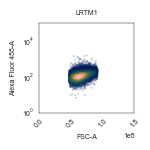

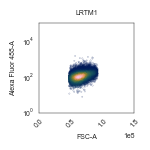

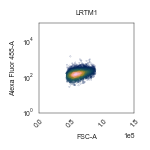

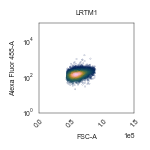

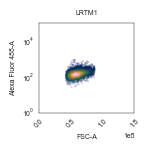

In [58]:
regions_of_interest = ['dFB', 'cVM']

strings_keep = [
    'APCDD1', 'ALCAM', 'CORIN', 'LRTM1', 'TPBG',
    'FOLR1', 'CNTN2', 'IAP', 'unstained',
    'rVM', 'cVM', 'dFB', 'dHB', 'vHB', 'dMB'
]

custom_theme(5)

count = 0

#process files for gating and visualization with density coloring
for filename, s in imported_files.items():

        #extract folder name from filename
        folder = os.path.basename(os.path.dirname(filename))

        #only include LRTM1 files
        if 'LRTM1' not in filename:
            continue

        #clean the filename for the title
        title = make_plot_title(filename, strings_keep)

        count += 1
        if count > 5:
            break

        #apply gating steps
        g1, g2, g3, g4 = apply_plotting_gates(s)

        #identify fluorophore channel
        fluorophore_channel, antibody = get_fluorophore_channel(filename, g4)

        if fluorophore_channel is None:
            continue

        #extract fluorophore data
        fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

        #retrieve gating cutoff
        cutoff = fmo_perc_cutoffs[folder].get(antibody, None)

        if cutoff is None:
            print(f"No cutoff available for {antibody} in folder: {folder}")
            print(f"Available keys in perc_cutoffs[{folder}]: {perc_cutoffs[folder].keys()}")
            continue

        #calculate the percentage of events above the cutoff
        perc_above_cutoff = (fluorophore_data > cutoff).sum() / len(fluorophore_data) * 100

        #apply gating and calculate the mean of gated data
        gated_mask = fluorophore_data > cutoff
        gated_data = fluorophore_data[gated_mask]
        gated_mean = gated_data.mean() if len(gated_data) > 0 else np.nan

        #plot marker gate
        plot_density_scatter(
            data=g4,
            x_channel='FSC-A',
            y_channel=fluorophore_channel,
            xlabel='FSC-A',
            ylabel=fluorophore_channel,
            title=title,
            figsize=(1.45, 1.45),
            xlim=(0, 1.5e5),
            ylim=(1, 1e5),
            yscale='log',
            xtick_ha='center',
            cutoff=cutoff,
            output_path=f'facs_plots/{filename}_gated_{antibody}_with_density_lrtm1_fig.pdf',
            dpi=100
        )

        #add percentage manually if needed

#### APCDD1

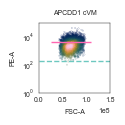

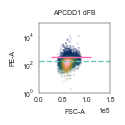

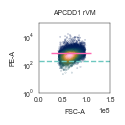

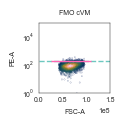

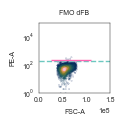

In [59]:
regions_of_interest = ['dFB', 'rVM', 'cVM']

strings_keep = [
    'APCDD1', 'unstained',
    'dFB', 'rVM', 'cVM'
]

abs_of_interest = ['APCDD1', 'unstained']

custom_theme(5)

count = 0

#process files for gating and visualization with density coloring
for filename, s in imported_files.items():

        #extract folder name from filename
        folder = os.path.basename(os.path.dirname(filename))

        #only keep selected regions
        if not any(region in filename for region in regions_of_interest):
            continue

        #only keep selected antibodies/controls
        if not any(ab in filename for ab in abs_of_interest):
            continue

        #clean the filename for the title
        title = make_plot_title(
            filename,
            strings_keep,
            replacements={'unstained': 'FMO'}
        )

        count += 1
        if count > 5:
            break

        #apply gating steps
        g1, g2, g3, g4 = apply_plotting_gates(s)

        #identify fluorophore channel
        fluorophore_channel, antibody = get_fluorophore_channel(filename, g4)

        if fluorophore_channel is None:
            continue

        #extract fluorophore data
        fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

        #retrieve gating cutoff
        cutoff = fmo_3std_cutoffs[folder].get(antibody, None)

        if cutoff is None:
            print(f"No cutoff available for {antibody} in folder: {folder}")
            print(f"Available keys in std_cutoffs_3[{folder}]: {std_cutoffs_3[folder].keys()}")
            continue

        #apply gating and calculate the mean of gated data
        gated_mask = fluorophore_data > cutoff
        gated_data = fluorophore_data[gated_mask]
        gated_mean = gated_data.mean() if len(gated_data) > 0 else np.nan

        #plot marker gate
        plot_density_scatter(
            data=g4,
            x_channel='FSC-A',
            y_channel=fluorophore_channel,
            xlabel='FSC-A',
            ylabel=fluorophore_channel,
            title=title,
            figsize=(1.2, 1.2),
            xlim=(0, 1.5e5),
            ylim=(1, 1e5),
            yscale='log',
            rotate_xticks=False,
            cutoff=cutoff,
            gated_mean=gated_mean,
            output_path=f'facs_plots/{filename}_gated_{antibody}_with_density_apcdd1_fig.pdf',
            dpi=300
        )

        #set more x-axis ticks, if desired

#### Pipeline illustration

Sample is not FMO - do not calculate FMO MFI


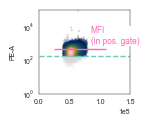

Sample is not FMO - do not calculate FMO MFI


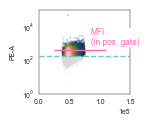

Sample is not FMO - do not calculate FMO MFI


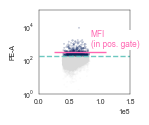

Sample is not FMO - do not calculate FMO MFI


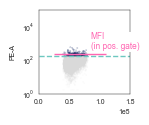

Sample is not FMO - do not calculate FMO MFI


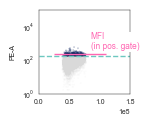

In [60]:
strings_keep = [
    'APCDD1', 'ALCAM', 'CORIN', 'LRTM1', 'TPBG',
    'FOLR1', 'CNTN2', 'IAP', 'unstained'
]

custom_theme(5)

count = 0

#process files for gating and visualization with density coloring
for filename, s in imported_files.items():

        #extract folder name from filename
        folder = os.path.basename(os.path.dirname(filename))

        #remove files with IAP in the filename
        if 'IAP' in filename:
            continue

        #only keep files with 200628 in filename
        if '200628' not in filename:
            continue

        #clean the filename for the title
        title = make_plot_title(filename, strings_keep)

        count += 1
        if count > 5:
            break

        #apply gating steps
        g1, g2, g3, g4 = apply_plotting_gates(s)

        #identify fluorophore channel
        fluorophore_channel, antibody = get_fluorophore_channel(filename, g4)

        if fluorophore_channel is None:
            continue

        #extract fluorophore data
        fluorophore_data = g4[:, g4.channels.index(fluorophore_channel)].astype('<f8')

        #retrieve gating cutoff
        cutoff = fmo_3std_cutoffs[folder].get(antibody, None)
        cutoff_perc = fmo_perc_cutoffs[folder].get(antibody, None)

        if cutoff is None:
            print(f"No cutoff available for {antibody} in folder: {folder}")
            print(f"Available keys in std_cutoffs_3[{folder}]: {std_cutoffs_3[folder].keys()}")
            continue

        #calculate MFI only for the FMO control
        if 'unstained' in filename:
            mfi = fluorophore_data.mean()
        else:
            print("Sample is not FMO - do not calculate FMO MFI")
            mfi = None

        #apply gating and calculate the mean of gated data
        gated_mask = fluorophore_data > cutoff
        gated_data = fluorophore_data[gated_mask]
        gated_mean = gated_data.mean() if len(gated_data) > 0 else np.nan

        #show gated mean only for fully stained samples
        if 'unstained' in filename:
            gated_mean_to_plot = None
        else:
            gated_mean_to_plot = gated_mean

        #show cutoff text only for FMO controls
        show_cutoff_text = 'unstained' in filename

        #show MFI text only for FMO controls
        show_mfi_text = 'unstained' in filename

        #show gated MFI text only for fully stained samples
        show_gated_mean_text = 'unstained' not in filename

        #plot marker gate
        plot_density_scatter(
            data=g4,
            x_channel='FSC-A',
            y_channel=fluorophore_channel,
            xlabel='',
            ylabel=f'{antibody}-A',
            title='',
            figsize=(1.4, 1.2),
            xlim=(0, 1.5e5),
            ylim=(1, 1e5),
            yscale='log',
            rotate_xticks=False,
            gray_below_cutoff=True,
            cutoff=cutoff,
            mfi=mfi,
            gated_mean=gated_mean_to_plot,
            show_cutoff_text=show_cutoff_text,
            show_mfi_text=show_mfi_text,
            show_gated_mean_text=show_gated_mean_text,
            output_path=f'facs_plots/{filename}_gated_{antibody}_with_density_for_illustration.pdf',
            dpi=100
        )

# Factor analysis of mixed data (FAMD)

In [61]:
#read the processed dataframe
todays_date = datetime.datetime.now().strftime('%y%m%d')
processed_merge = pd.read_csv(f'output/regional spec cleaned processed merged py manual {todays_date}.csv')
#processed_merge = pd.read_csv(f'output/merged regional spec py manual 260522.csv') #alternatively, replace with date of interest

#standardize only the numberical columns by selecting them
numerical_cols = processed_merge.select_dtypes(include=[np.float64]).columns

#replace infinite values and NA's with 0 only in float64 columns
for col in processed_merge.select_dtypes(include=[np.float64]).columns:
    processed_merge[col] = processed_merge[col].replace([np.inf, -np.inf], 0)
    processed_merge[col] = processed_merge[col].fillna(0)

#standardize only columns in cluster_cols
scaler = StandardScaler()
processed_merge[numerical_cols] = scaler.fit_transform(processed_merge[numerical_cols])
famd_data = processed_merge

#perform FAMD
famd = prince.FAMD(n_components=30, random_state=123, engine="sklearn")
famd = famd.fit(famd_data)

famd.eigenvalues_summary[:10]

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,14.802,7.22%,7.22%
1,13.084,6.38%,13.60%
2,11.106,5.42%,19.02%
3,10.851,5.29%,24.31%
4,10.626,5.18%,29.50%
5,10.174,4.96%,34.46%
6,9.690,4.73%,39.19%
7,7.051,3.44%,42.63%
8,6.586,3.21%,45.84%


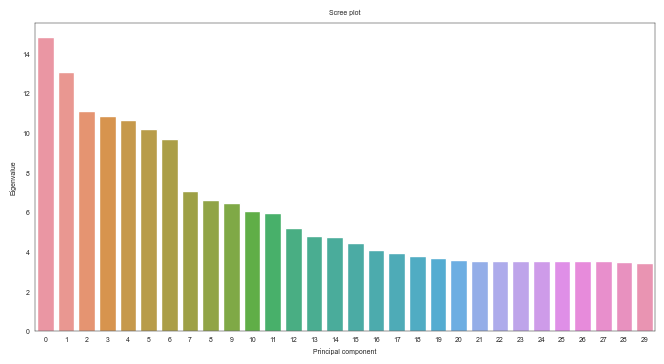

component,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
variable,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10sd_per_pos,5.5%,0.6%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%,0.1%,0.0%,0.2%,0.1%,0.1%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
8sd_per_pos,5.5%,0.6%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.1%,0.0%,0.1%,0.0%,0.2%,0.1%,0.1%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
per_pos_manual,5.4%,0.7%,0.2%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.2%,0.1%,0.1%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
15sd_per_pos,5.4%,0.8%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.1%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
20sd_per_pos,5.2%,0.9%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.1%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


In [62]:
eigen_df = famd.eigenvalues_summary.reset_index()
eigen_df = eigen_df[['component', 'eigenvalue']]
eigen_df['eigenvalue'] = eigen_df['eigenvalue'].astype(float)

plt.figure(figsize=(8, 4))
sns.barplot(data=eigen_df, x='component', y='eigenvalue')
plt.xlabel('Principal component')
plt.ylabel('Eigenvalue')
plt.title('Scree plot')
plt.show()

famd.column_contributions_.sort_values(0, ascending=False).head().style.format('{:.1%}')

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/1553026493.py:4: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  famd_contrib = famd_contrib_melted.pivot(index='variable', columns='component', values='contribution').groupby('variable').mean().sort_values(0, ascending=False)


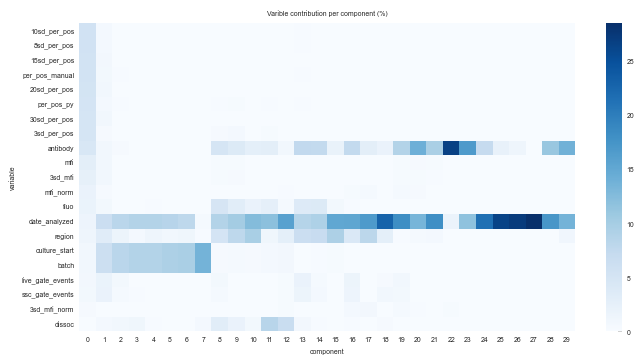

component,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.009756,0.000233,0.003749,0.007497,0.000892,0.000072,0.000300,8.029427e-07,0.001917,2.591125e-04,...,0.003853,0.000101,0.012119,0.000792,0.000394,0.000231,0.000050,0.000002,0.000764,0.000240
1,0.000427,0.003215,0.001800,0.004842,0.000861,0.000150,0.000033,4.015933e-05,0.000512,1.901487e-03,...,0.000534,0.000933,0.005249,0.000125,0.000138,0.000172,0.000028,0.000002,0.000192,0.000037
2,0.000079,0.003741,0.001609,0.004719,0.000799,0.000152,0.000025,4.325935e-05,0.000376,1.680687e-03,...,0.000059,0.000144,0.004989,0.000091,0.000177,0.000175,0.000027,0.000002,0.000436,0.000324
3,0.000090,0.003668,0.001292,0.004840,0.000716,0.000008,0.000050,1.648320e-05,0.000419,8.275328e-04,...,0.000424,0.000389,0.004863,0.000113,0.000169,0.000178,0.000025,0.000002,0.000319,0.000024
4,0.000059,0.004608,0.002027,0.003175,0.000812,0.000004,0.000031,4.739552e-05,0.000465,6.841611e-07,...,0.003649,0.000045,0.008158,0.000054,0.000021,0.005719,0.001425,0.000731,0.001762,0.000293


In [63]:
#retrieve the columns contributions, sort, and drop selective cols
famd_contrib = famd.column_contributions_.sort_values(0, ascending=False).drop(['mfi_norm_boxcox', 'mfi_norm_log10']).reset_index()
famd_contrib_melted = famd_contrib.melt(id_vars='variable', var_name='component', value_name='contribution').assign(contribution=lambda x: x.contribution.round(3) * 100)
famd_contrib = famd_contrib_melted.pivot(index='variable', columns='component', values='contribution').groupby('variable').mean().sort_values(0, ascending=False)

#plot the column contributions as a heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(famd_contrib, cmap=sns.color_palette("Blues", as_cmap=True), fmt=".2f")
plt.title('Varible contribution per component (%)')
plt.show()

famd.row_contributions_.head()

Redo the FAMD with selective variables

In [64]:
#standardize only the numberical columns by selecting them
processed_merge_sel = processed_merge[[#categorical columns
    'antibody', 'date_analyzed', 'region', 'dissoc', 'fluo', 'batch', 

    #numerical columns
    'mfi', '3sd_mfi', '3sd_per_pos', 'per_pos_py', 'per_pos_manual']]


numerical_cols = processed_merge_sel.select_dtypes(include=[np.float64]).columns

#replace infinite values and NA's with 0 only in float64 columns
for col in processed_merge_sel.select_dtypes(include=[np.float64]).columns:
    processed_merge_sel[col] = processed_merge_sel[col].replace([np.inf, -np.inf], 0)
    processed_merge_sel[col] = processed_merge_sel[col].fillna(0)

#standardize only columns in cluster_cols
scaler = StandardScaler()
processed_merge_sel[numerical_cols] = scaler.fit_transform(processed_merge_sel[numerical_cols])
famd_data2 = processed_merge_sel

#perform FAMD
famd2 = prince.FAMD(n_components=30, random_state=123, engine="sklearn")
famd2 = famd2.fit(famd_data2)

#arrange the column contributions in descending order
famd2_dim1 = famd2.column_contributions_.sort_values(0, ascending=False).iloc[:, :1]
famd2_dim1 = famd2_dim1 * 100
print(famd2_dim1.head(10))

#print the total explained variance
print(famd2_dim1.sum())

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/167236024.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_merge_sel[col] = processed_merge_sel[col].replace([np.inf, -np.inf], 0)
/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/167236024.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_merge_sel[col] = processed_merge_sel[col].fillna(0)
/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/167236024.py:18: SettingWithCopyWarning: 
A val

component              0
variable                
date_analyzed   9.590316
batch           8.661826
region          7.061661
fluo            2.573335
3sd_per_pos     2.365696
per_pos_manual  2.296396
per_pos_py      2.236505
antibody        2.063076
mfi             0.768413
dissoc          0.653777
component
0    38.792163
dtype: float64


In [65]:
#access eigenvalues
eigenvalues = famd2.eigenvalues_

#calculate total variance (i.e. eigenvalue sum)
total_variance = sum(eigenvalues)

#calculate explained variance for each component
explained_variance = [eig / total_variance for eig in eigenvalues]

#print the explained variance as pct
print("Explained variance (percentage) by components:")
print([round(ev * 100, 2) for ev in explained_variance])
print(f"Total explained variance: {round(sum(explained_variance) * 100, 2)}%") #verify sum variance = 100%

Explained variance (percentage) by components:
[6.46, 5.81, 5.28, 5.03, 4.86, 4.63, 4.44, 4.2, 4.14, 3.83, 3.69, 3.24, 3.11, 2.92, 2.85, 2.62, 2.55, 2.45, 2.37, 2.36, 2.33, 2.32, 2.32, 2.32, 2.32, 2.32, 2.32, 2.32, 2.31, 2.27]
Total explained variance: 100.0%


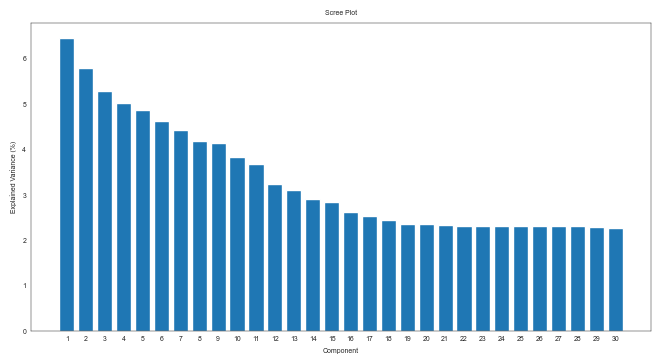

In [66]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance) + 1), [v * 100 for v in explained_variance])
plt.xlabel('Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

Number of components to explain at least 90% of the variance: 26


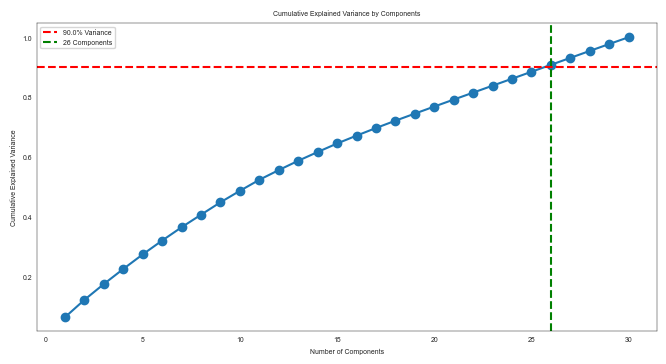

In [67]:
#calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

#find the number of components needed to explain at least 90% of the variance
threshold = 0.90 
num_components = next(i for i, total in enumerate(cumulative_variance) if total >= threshold) + 1
print(f"Number of components to explain at least 90% of the variance: {num_components}")

#plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'{threshold * 100}% Variance')
plt.axvline(x=num_components, color='g', linestyle='--', label=f'{num_components} Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Components')
plt.legend()
plt.show()

component              0         1          2          3          4  \
variable                                                              
date_analyzed   9.590316  4.961081  13.543473  13.804707  12.835285   
antibody        2.063076  7.177030   0.359879   0.546134   2.636512   
batch           8.661826  3.694222  10.557016  11.140192  11.389504   
region          7.061661  3.428122   1.791639   5.396397   3.416801   
dissoc          0.653777  0.286571   6.419315   1.552384   0.225584   
fluo            2.573335  4.016107   0.521055   0.550925   1.476080   
3sd_per_pos     2.365696  4.776634   0.100280   0.223084   0.818417   
per_pos_py      2.236505  5.508358   0.141639   0.224641   0.956333   
per_pos_manual  2.296396  6.599303   0.148589   0.200362   0.988010   
mfi             0.768413  6.449339   0.005860   0.227316   0.660523   

component               5          6          7          8          9  ...  \
variable                                                             

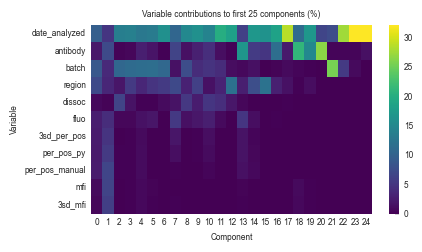

component       Total (%)
variable                 
date_analyzed       41.39
batch               16.34
antibody            12.98
region              11.32
dissoc               4.20
fluo                 4.06
per_pos_py           2.19
per_pos_manual       2.18
3sd_per_pos          2.17
mfi                  1.66


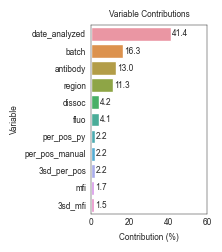

In [68]:
#extract variable contributions for selected numher of components (e.g., top 5)
num_components_to_plot = 25
variable_contributions = famd.column_contributions_.iloc[:, :num_components_to_plot] * 100  #convert to %

#calculate the total contributions for each variable across components
variable_contributions['Total'] = variable_contributions.sum(axis=1)
variable_contributions = variable_contributions.sort_values(by='Total', ascending=False) #sort by total contribution
print(variable_contributions.head(10))  #display contribution, top 10 variables

# heatmap for variable contributions to components
custom_theme(6)
plt.figure(figsize=(4.5, 2.5))
sns.heatmap(variable_contributions.iloc[:, :num_components_to_plot], cmap="viridis")
plt.title(f'Variable contributions to first {num_components_to_plot} components (%)')
plt.xlabel('Component')
plt.ylabel('Variable')
plt.tight_layout()
#plt.savefig('figs/famd variable contrib over dims.pdf', dpi=300)
plt.show()

#limit explained variance to match the number of components used for contributions
explained_variance = explained_variance[:num_components_to_plot]

#normalize and sort contributions
normalized_contributions = variable_contributions.iloc[:, :num_components_to_plot].mul(explained_variance, axis=1)
normalized_contributions['Total'] = normalized_contributions.sum(axis=1)
normalized_contributions['Total (%)'] = normalized_contributions['Total'] / normalized_contributions['Total'].sum() * 100
normalized_contributions = normalized_contributions.sort_values(by='Total (%)', ascending=False).round(2)
print(normalized_contributions[['Total (%)']].head(10))

#bar plot for normalized contributions
custom_theme(6)
plt.figure(figsize=(2.2, 2.5))
sns.barplot(x=normalized_contributions['Total (%)'], y=normalized_contributions.index)
#add the text labels
for i, v in enumerate(normalized_contributions['Total (%)']):
    plt.text(v + 0.5, i, f'{v:.1f}', va='center')
plt.xlim(0, 60)
plt.xlabel('Contribution (%)')
plt.ylabel('Variable')
plt.title('Variable Contributions')
plt.tight_layout()
#plt.savefig('figs/famd normalized variable contributions.pdf', dpi=300)
plt.show()

Plot the FAMD as scatter plots

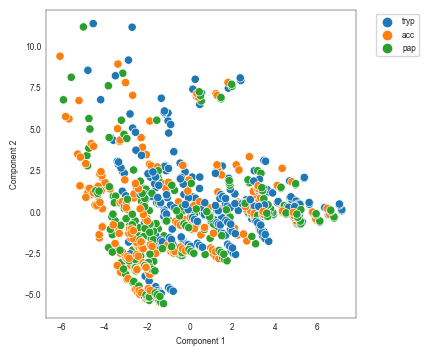

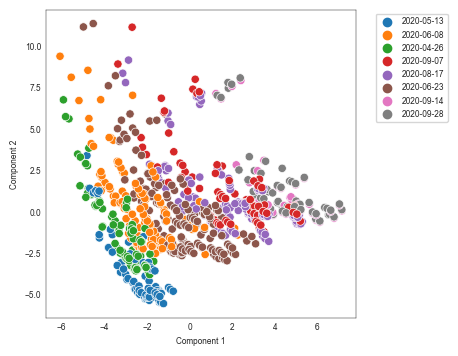

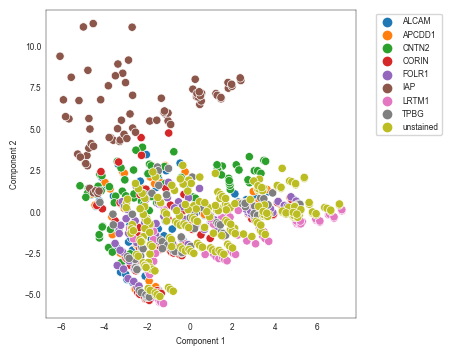

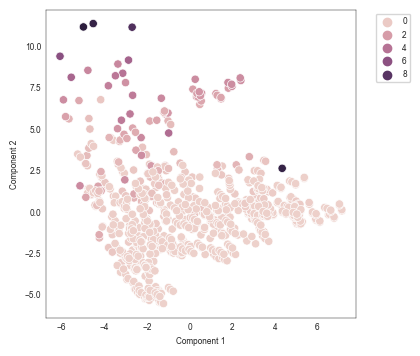

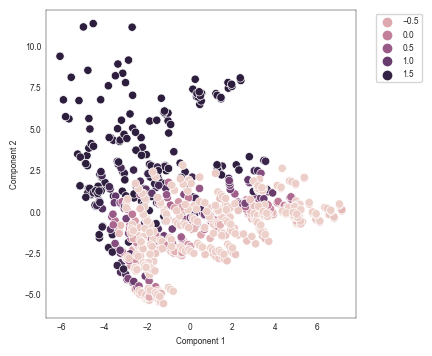

In [69]:
#get row principal components
principal_coordinates = famd.row_coordinates(famd_data)
plot_data = principal_coordinates.iloc[:, :2].copy() #select first 2 components
plot_data.columns = ['Component 1', 'Component 2']

#variables to plot
vars_col = ['dissoc', 'culture_start', 'antibody', '3sd_mfi', '3sd_per_pos'] #variables to plot

#add vars
plot_data[vars_col] = processed_merge[vars_col].reset_index(drop=True)
 
custom_theme(6)

#define plotting function
def scatter_plot_func(plot_data, vars_col):
    for var in vars_col:

        #plot
        plt.figure(figsize=(4, 4))
        sns.scatterplot(data=plot_data, 
                        x='Component 1', y='Component 2', 
                        hue=var) #colored by vars_plot
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

scatter_plot_func(plot_data, vars_col)

/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/3117056503.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['dissoc'] = processed_merge['dissoc']
/var/folders/9p/d9yjsp0n08d5t86rw98cmx0h0000gn/T/ipykernel_80373/3117056503.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['dissoc'], unique = pd.factorize(plot_data['dissoc'])


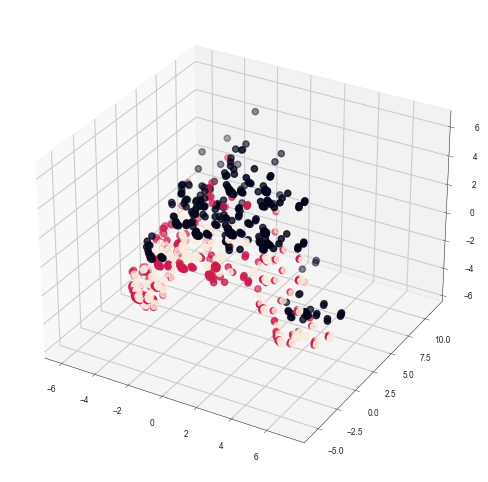

In [70]:
#select the first three components
plot_data = principal_coordinates.iloc[:, :3]
plot_data.columns = ['Component 1', 'Component 2', 'Component 3']

#add 'dissoc' to the plot data
plot_data['dissoc'] = processed_merge['dissoc']
plot_data['dissoc'], unique = pd.factorize(plot_data['dissoc'])

#create 3d scatter colored by 'dissoc'
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(plot_data['Component 1'], plot_data['Component 2'], plot_data['Component 3'], c=plot_data['dissoc'])
plt.show()